# Deep Learning for Natural Language Processing - Exercise 3
## Author: Margarita Orfanidi ID: 7115152400023

This assignment investigates the task of identifying ambiguity in politicians' answers during interviews, based on the SemEval 2026 Task 6 (CLARITY) dataset. The problem is framed as a three-class classification task, where each question–answer pair must be assigned one of the following labels: **Clear Reply**, **Ambivalent**, or **Clear Non-Reply**.

Τhis work evaluates pretrained instruction-tuned large language models through prompting. Different prompting strategies are compared. The goal is to examine how model size, prompt design, decoding strategy, and example selection affect classification performance.

**Please note :** 
Some of the experiments below are commented out in order to make the Kaggle submission process more efficient. These cells can be uncommented and executed to reproduce the corresponding experimental results. For each commented-out experiment, the markdown cell directly above it describes the expected result — the metrics and behaviour obtained when that cell was run.

### Libraries

In [1]:
# Libraries 
!pip install -q -U "transformers @ git+https://github.com/huggingface/transformers.git"
!pip install pyspellchecker
!pip install -q sentence-transformers

import warnings
warnings.filterwarnings("ignore")

from kaggle_secrets import UserSecretsClient
import torch
import pandas as pd
from transformers import AutoTokenizer, AutoModelForCausalLM
from datasets import load_dataset
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, f1_score, classification_report
import pandas as pd
import numpy as np
from sklearn.metrics import  confusion_matrix
from tokenizers import Tokenizer
from transformers import AutoProcessor, Gemma3ForConditionalGeneration
from datasets import load_dataset
import seaborn as sns
import matplotlib.pyplot as plt
import random 
from sentence_transformers import SentenceTransformer
from tqdm.auto import tqdm
from spellchecker import SpellChecker
import re
import emoji
import os
import gc
import sys
import os
os.environ['PYTORCH_CUDA_ALLOC_CONF'] = 'expandable_segments:True'

sys.path.append("/kaggle/input/datasets/leloulv/utils-nlp-ex3")
sys.path.append("/kaggle/input/datasets/leloulv/utils-exercise-2")
sys.path.append("/kaggle/input/datasets/leloulv/exercise1-nlp")

print("Paths added.")

from utils import *
from helper_functions import *
from Utils_Ex3_NLP import *
from exp_functions import *

set_seed(seed=42)
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)



  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 668.2/668.2 kB 17.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 97.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.2/7.2 MB 93.5 MB/s eta 0:00:00
Paths added.


### Load Dataset

In [2]:
# Load the dataset (train and test sets)
dataset = load_dataset("ailsntua/QEvasion")
df_train = pd.DataFrame(dataset["train"])
df_test = pd.DataFrame(dataset["test"])

README.md:   0%|          | 0.00/12.7k [00:00<?, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/3.90M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/259k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/3448 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/308 [00:00<?, ? examples/s]

# Exploratory Data Analysis
As a first step, it is important to explore the dataset in depth in order to better understand the nature and characteristics of the problem we aim to address. Our task is a classification problem focused on response clarity. Specifically, the goal is to classify political responses into predefined categories that reflect the level of clarity or evasiveness present in an answer.

Before proceeding to the modeling stage, it is necessary to perform an initial inspection of the dataset. This exploratory step allows us to examine basic statistics, understand the distribution of the labels, and identify potential patterns that appear in the data. Through this process, we can confirm the structure of the dataset, recognize the most important variables, and develop a clearer understanding of the problem we are attempting to solve.

## Metadata Analysis

This step helps verify that both train and test sets share the same structure (i.e., they contain the same columns) and allows us to inspect important properties such as the presence of missing values, data types, and the overall size of the datasets (number of entries) before further processing.

In [3]:
display(df_train.info())
display(df_test.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3448 entries, 0 to 3447
Data columns (total 20 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   title                  3448 non-null   object
 1   date                   3448 non-null   object
 2   president              3448 non-null   object
 3   url                    3448 non-null   object
 4   question_order         3448 non-null   int64 
 5   interview_question     3448 non-null   object
 6   interview_answer       3448 non-null   object
 7   gpt3.5_summary         3448 non-null   object
 8   gpt3.5_prediction      3448 non-null   object
 9   question               3448 non-null   object
 10  annotator_id           3448 non-null   object
 11  annotator1             0 non-null      object
 12  annotator2             0 non-null      object
 13  annotator3             0 non-null      object
 14  inaudible              3448 non-null   bool  
 15  multiple_questions   

None

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 308 entries, 0 to 307
Data columns (total 20 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   title                  0 non-null      object
 1   date                   0 non-null      object
 2   president              0 non-null      object
 3   url                    308 non-null    object
 4   question_order         308 non-null    int64 
 5   interview_question     308 non-null    object
 6   interview_answer       308 non-null    object
 7   gpt3.5_summary         0 non-null      object
 8   gpt3.5_prediction      0 non-null      object
 9   question               308 non-null    object
 10  annotator_id           0 non-null      object
 11  annotator1             308 non-null    object
 12  annotator2             308 non-null    object
 13  annotator3             308 non-null    object
 14  inaudible              308 non-null    bool  
 15  multiple_questions     

None

### Sample display
We displayed random samples from the dataset in order to observe the structure and formatting of the textual data. This qualitative inspection helps identify potential patterns and understand how the text appears in practice, allowing us to draw conclusions about the preprocessing steps that may be required. For example, we observed several spelling inconsistencies and cases where punctuation marks are not properly separated from words due to missing spaces.

In [4]:
# Display random samples of the training set
display_samples(df_train,1)

Sample 2900


,Value
title,"The President's News Conference With President Lee Myung-bak of South Korea at Camp David, Maryland"
date,"April 19, 2008"
president,George W. Bush
url,https://www.presidency.ucsb.edu/documents/the-presidents-news-conference-with-president-lee-myung-bak-south-korea-camp-david
question_order,2
interview_question,"Q. I have a question for President Lee. Korea and the United States have made many achievements through the summit meeting, especially North Korean nuclear issue and the strengthening of the alliance. As for North Korean nuclear issue, Mr. President Lee suggested setting up a permanent liaison office in both Seoul and Pyongyang. What are some of the follow-up effects, if you do have any follow-up actions? And do you have any thoughts of proposing a meeting with Chairman Kim at an earlier date?"
interview_answer,"The process is not something that we discussed between ourselves during the summit meeting. In fact, when I was staying in Washington, DC, I had an interview with one of the newspapers there, and it came up. Of course, it was not a sudden suggestion. I did have a meeting among my staff and related ministries, and I talked about this in detail before I came to the United States.We have a new administration in Korea, and we haven't yet to begun dialogue with the ns. Inter-Korean dialogue, there is a need for us to have dialogue all the time. Up until now, we had dialogues whenever the need arose, and then it would stop. However, dialogue should be based on genuine cooperation and sincerity. And so with this in mind, I thought that it would be helpful to set up a permanent liaison office in both Seoul and Pyongyang.As for the summit meeting between myself and Chairman Kim, I will agree to it when the need is real. And I already said publicly that I am willing to meet with him—not just once, but many times—but if the meeting will yield substantial and real results. I believe only when that is possible, I am ready to meet with him and have sincere dialogue, because that will help to bring about peace and stability of the peninsula.So basically, I do hold that thought, but I'm not suggesting that—to have a meeting with Chairman Kim anytime soon. If the need arises, again, I'm ready to meet with him. Steven Lee [Steven Lee Myers, New York Times]."
gpt3.5_summary,"The question consists of 2 parts:\n\n1. Follow-up effects of setting up a permanent liaison office in Seoul and Pyongyang for the North Korean nuclear issue.\n2. Thoughts on proposing a meeting with Chairman Kim at an earlier date.\n\n<--Summary Answer-->\n\nThe response provides the following information regarding these points:\n\n1. Follow-up effects of setting up a permanent liaison office in Seoul and Pyongyang for the North Korean nuclear issue:\n- President Lee suggests setting up a permanent liaison office in both Seoul and Pyongyang to facilitate dialogue and cooperation between North Korea and South Korea.\n- The suggestion was made during an interview with a newspaper in Washington, DC, and was not discussed during the summit meeting.\n- The intention behind the suggestion is to establish genuine cooperation and sincerity in inter-Korean dialogue.\n\n2. Thoughts on proposing a meeting with Chairman Kim at an earlier date:\n- President Lee is open to the idea of a meeting with Chairman Kim, but only when the need is real and there is a possibility of substantial and real results.\n- He believes that sincere dialogue with Chairman Kim can contribute to the peace and stability of the Korean peninsula.\n- While he holds the thought of meeting with Chairman Kim, he is not suggesting a meeting anytime soon, but is willing to meet if the need arises.\n\nOverall, President Lee emphasizes the importance of genuine cooperation, sincerity, and substantial results in both the setup of a liaison office and the possibility of a meeting with Chairman Kim."
gpt3.5_prediction,"Question 1: Follow-up effects of setting up a permanent liaison office in Se

The responses are labeled based on whether they address each sub-question. As a result, the same response may appear multiple times in the dataset, depending on the number of sub-questions associated with a given interview question.

This behavior is illustrated below by displaying the original question, the corresponding sub-questions, the interview response, and the assigned label. As shown, the same response is repeated across different sub-questions, while the assigned label may vary depending on how well the response addresses each sub-question.

In [5]:
def show_question(df, interview_q):
    subset = df[df['interview_question'] == interview_q]

    print("INTERVIEW QUESTION:")
    print(interview_q)

    for i, row in subset.iterrows():
        print("\n--- Example ---")
        print("Sub-question:")
        print(row['question'])

        print("\nAnswer:")
        print(row['interview_answer'][:300] + "...") 

        print("\nClarity label:", row['clarity_label'])

q = random.choice(df_train['interview_question'].unique())
show_question(df_train, q)

INTERVIEW QUESTION:
Q. And if I could, on the election, sir—can I——TikTok/Microsoft Corporation  Q. President Trump, on the sale of TikTok, you're basically arguing that the U.S. Government is going to collect a cut from a—of a transaction including two companies, in which it doesn't hold a stake in.That's unprecedented. That's never happened in U.S. history before, and the administration has offered very little explanation about how that's going to work. Can you back your statement up and provide specifics about how that would work?

--- Example ---
Sub-question:
The interviewer's request for President Trump to back up his statement and provide specific details on how the government would collect this cut.

Answer:
Did you say, That's impressive? Did you actually use that term?...

Clarity label: Ambivalent

--- Example ---
Sub-question:
The previous comment made by the interviewer, expressing that President Trump is arguing for the U.S. Government to collect a cut from the sale of Ti

## Label Distribution
Clarity Labels Distribution
The labels used for the classification task are the clarity labels, which include Clear Reply, Clear Non-Reply, and Ambivalent. The distribution of instances across these labels is shown below. The majority of instances belong to the Ambivalent class, accounting for approximately 59.2\% of the data (2039 samples). The Clear Reply category represents about 30.5\% of the dataset (1051 samples), while Clear Non-Reply is the least frequent class with 10.3\% (356 samples). This distribution indicates a noticeable class imbalance, with the Ambivalent class dominating the dataset, a factor that should be considered during model training and evaluation.

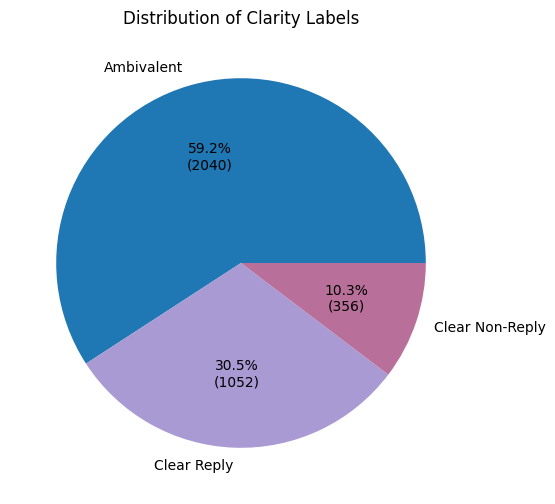

In [6]:
colors = ["#1f77b4", "#a99ad3", "#b8709a"]

df_train["clarity_label"].value_counts().plot(
    kind="pie",
    autopct=lambda p: f"{p:.1f}%\n({int(p*len(df_train)/100)})",
    figsize=(6,6),
    colors=colors
)
plt.title("Distribution of Clarity Labels")
plt.ylabel("")
plt.show()

## Textual Analysis


### Clarity Label Distribution by Word Count

 The dataset contains 3,448 responses, with an average length of approximately 294 words and a high standard deviation (301.54), indicating substantial variability in response length. The distribution is highly skewed, ranging from very short answers (1 word) to very long ones (up to 2,117 words). The median value (207 words) is lower than the mean, suggesting the presence of long outlier responses that increase the average.
 
 Examining the classes separately, Ambivalent responses not only constitute the majority of the dataset (2,040 samples) but also tend to be longer on average (331.86 words) and exhibit the highest variability (standard deviation of 319.53). Clear Reply responses include 1,052 samples with a moderate average length of 272.04 words and a relatively high spread (standard deviation of 269.54). In contrast, Clear Non-Reply responses form the smallest group (356 samples) and are considerably shorter, with an average length of 137.81 words and lower variability (standard deviation of 217.39).

Overall, these results indicate a clear relationship between response length and clarity. Shorter responses are more frequently associated with non-replies, while longer and more variable responses tend to correspond to ambivalent answers. This observation suggests that response length may serve as a useful feature for distinguishing between clarity categories.


=== Statistics by clarity_label ===
                 count        mean  median  min   max         std
clarity_label                                                    
Ambivalent        2040  331.857843   243.5    1  2117  319.526222
Clear Non-Reply    356  137.806180    39.5    1  1407  217.389827
Clear Reply       1052  272.041825   194.0    1  1592  269.540724


<Figure size 800x500 with 0 Axes>

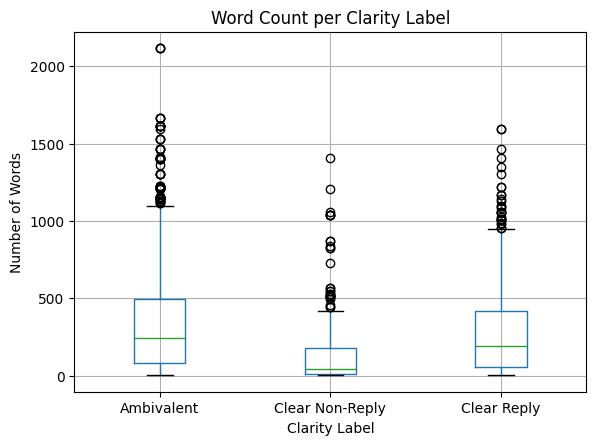

In [7]:
df_train = add_word_count(df_train, "interview_answer", "answer_word_count")
print_label_stats(df_train, "clarity_label", "answer_word_count")
plot_clarity_boxplot(df_train, "answer_word_count", "clarity_label")

To support the textual analyses that follow (pattern detection and spelling checks), the interview question, sub-question, and interview answer are concatenated into a single `text` column for both the train and test sets.

In [8]:
train = df_train[["interview_question", "question", "interview_answer", "clarity_label"]].copy()
train["text"] = (
    train["interview_question"].astype(str) + " " +
    train["question"].astype(str) + " " +
    train["interview_answer"].astype(str)
)

test = df_test[["interview_question", "question", "interview_answer", "clarity_label"]].copy()
test["text"] = (
    test["interview_question"].astype(str) + " " +
    test["question"].astype(str) + " " +
    test["interview_answer"].astype(str)
)


### Detection of Text Patterns in the Dataset
Only numerical patterns were detected in the dataset. Since no strong or meaningful textual patterns were identified, no additional preprocessing is required.

In [9]:
detect_text_patterns(train["text"])
detect_text_patterns(test["text"])


Starting dataset inspection...
----------------------------------------
Clean: No HTML Tags found.

Clean: No Emails found.

Clean: No URLs (http/www) found.

Clean: No Twitter Mentions (@) found.

Clean: No Hashtags (#) found.

Found: 1692 texts with Digits.
Clean: No Newlines (\n) found.

Clean: No Emojis found.

----------------------------------------
Inspection completed!
Starting dataset inspection...
----------------------------------------
Clean: No HTML Tags found.

Clean: No Emails found.

Clean: No URLs (http/www) found.

Clean: No Twitter Mentions (@) found.

Clean: No Hashtags (#) found.

Found: 166 texts with Digits.
Clean: No Newlines (\n) found.

Clean: No Emojis found.

----------------------------------------
Inspection completed!


### Detection of spelling errors
Spelling errors constitute a very small portion of the dataset, suggesting that the textual data is generally clean and that spelling mistakes are unlikely to significantly affect the performance of the classification models.

In [10]:
check_spelling_errors(train["text"])
find_bad_samples(train["text"], threshold=30)


Total words: 1345446
Misspelled words: 25716
Percentage of misspelled words: 1.91%
Example misspelled words: ['thei', 'chineseno', 'aboutit', 've', 'donei']


The same spelling check is repeated on the test set to confirm that it is equally clean and shares the same characteristics as the training set.



In [11]:
check_spelling_errors(test["text"])
find_bad_samples(test["text"], threshold=30)

Total words: 129505
Misspelled words: 1862
Percentage of misspelled words: 1.44%
Example misspelled words: ['corke', 'nbc', 'll', 'hu', 'jintao']


## Token Analysis 

This analysis was performed mainly to get an overview of how large the input question-answer pairs are when tokenized with the Qwen LLM tokenizer.



In [12]:
model_name = "Qwen/Qwen3.5-0.8B"

tokenizer = Tokenizer.from_pretrained(model_name)

token_counts_train = np.array([
    len(tokenizer.encode(q + "\n" + a).ids)
    for q, a in zip(df_train["question"], df_train["interview_answer"])
])
token_counts_test = np.array([
    len(tokenizer.encode(q + "\n" + a).ids)
    for q, a in zip(df_test["question"], df_test["interview_answer"])
])

tokenizer.json:   0%|          | 0.00/12.8M [00:00<?, ?B/s]

Histogram of the token-length distribution for the **train** set.

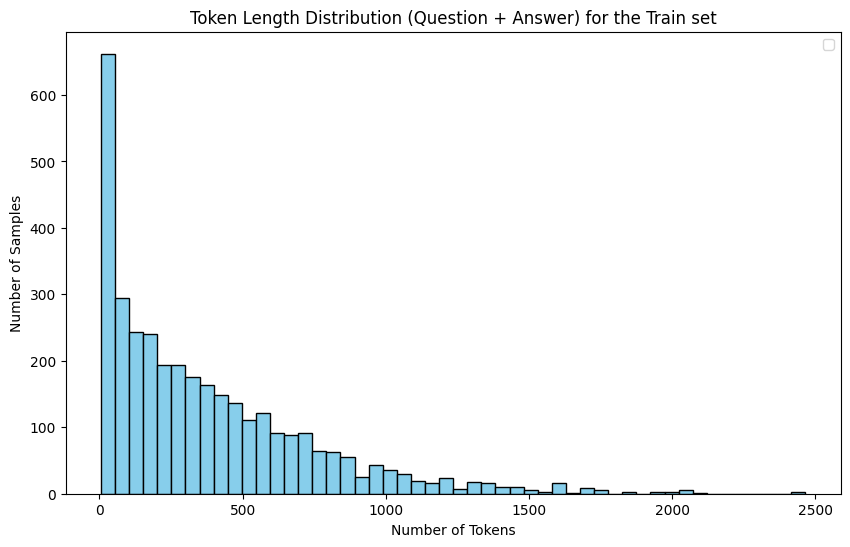

In [13]:
plt.figure(figsize=(10, 6))

# Plot the histogram of token counts
plt.hist(token_counts_train, bins=50, color='skyblue', edgecolor='black')

# Set plot labels and title
plt.title('Token Length Distribution (Question + Answer) for the Train set')
plt.xlabel('Number of Tokens')
plt.ylabel('Number of Samples')

# Display the legend to identify the 512-limit line
plt.legend()

plt.show()

Basic token-length statistics (mean, median, min, max) for the **training** set.

In [14]:
# Display basic token statistics
print(f"Total samples: {len(token_counts_train)}")
print(f"Mean length: {token_counts_train.mean():.2f}")
print(f"Median length: {np.median(token_counts_train)}")
print(f"Maximum length: {token_counts_train.max()}")
print(f"Minimum length: {token_counts_train.min()}")



Total samples: 3448
Mean length: 376.04
Median length: 273.0
Maximum length: 2465
Minimum length: 5


Histogram of the token-length distribution for the **test** set.

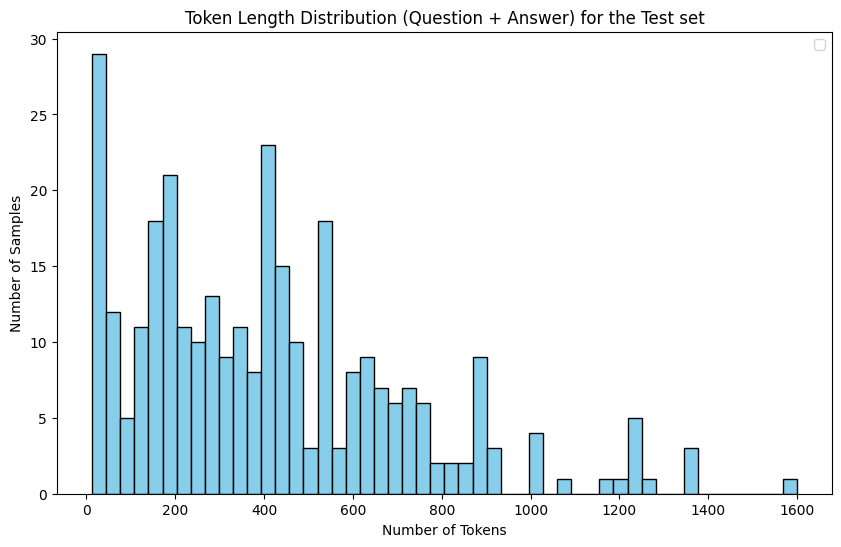

In [15]:
plt.figure(figsize=(10, 6))

# Plot the histogram of token counts
plt.hist(token_counts_test, bins=50, color='skyblue', edgecolor='black')

# Set plot labels and title
plt.title('Token Length Distribution (Question + Answer) for the Test set')
plt.xlabel('Number of Tokens')
plt.ylabel('Number of Samples')

# Display the legend to identify the 512-limit line
plt.legend()

plt.show()

Basic token-length statistics (mean, median, min, max) for the **test** set.

In [16]:
# Display basic token statistics
print(f"Total samples: {len(token_counts_test)}")
print(f"Mean length: {token_counts_test.mean():.2f}")
print(f"Median length: {np.median(token_counts_test)}")
print(f"Maximum length: {token_counts_test.max()}")
print(f"Minimum length: {token_counts_test.min()}")



Total samples: 308
Mean length: 412.91
Median length: 379.5
Maximum length: 1599
Minimum length: 13


# Preprocessing

Duplicate rows were then removed from the training set based on the combination of question, interview answer, and clarity label. This ensures that identical question–answer–label triplets do not appear more than once.




In [17]:
# size before removing duplicates
print("Before drop_duplicates:", df_train.shape)

# remove duplicated rows based on question + answer 
df_train = df_train.drop_duplicates(subset=["question", "interview_answer"])


# size after removing duplicates
print("After drop_duplicates:", df_train.shape)


Before drop_duplicates: (3448, 21)
After drop_duplicates: (3390, 21)


## Split dataset

The dataset was split into two parts in order to evaluate the LLMs under different prompting techniques. The `pool_df` subset was kept separate and used only for selecting few-shot examples, while `exp_df` was used as the main experimental evaluation dataset. This separation ensures that the examples shown to the model in few-shot prompting do not overlap with the instances used for evaluation.

The final evaluation dataset remained imbalanced, reflecting the original class distribution. 
The length statistics also show differences between the classes. Ambivalent answers tend to be the longest on average, Clear Reply answers are shorter on average Clear Non-Reply answers are the shortest. This suggests that answer length may be related to the clarity label, especially because non-replies often appear as shorter or more evasive responses.

In [18]:
from sklearn.model_selection import train_test_split
pool_df, exp_df = train_test_split(
    df_train,
    test_size=0.11,
    random_state=42,
    stratify=df_train["clarity_label"]
)

pool_df = pool_df.reset_index(drop=True)
exp_df = exp_df.reset_index(drop=True)

print("Pool:")
print(pool_df["clarity_label"].value_counts())

print("\nExperiment dataset:")
print(exp_df["clarity_label"].value_counts())


exp_df['length'] = exp_df['interview_answer'].str.split().str.len()

stats = exp_df.groupby('clarity_label')['length'].agg(
    ['count', 'min', 'max', 'mean', 'median']
).round(1)
print(stats)

Pool:
clarity_label
Ambivalent         1783
Clear Reply         923
Clear Non-Reply     311
Name: count, dtype: int64

Experiment dataset:
clarity_label
Ambivalent         221
Clear Reply        114
Clear Non-Reply     38
Name: count, dtype: int64
                 count  min   max   mean  median
clarity_label                                   
Ambivalent         221    1  1667  342.1   243.0
Clear Non-Reply     38    2   514  100.8    51.5
Clear Reply        114    1  1170  296.2   223.0


The per-class answer-length distribution is plotted for the experimental subset (`exp_df`) to verify that the stratified split preserved the length characteristics observed in the full dataset.

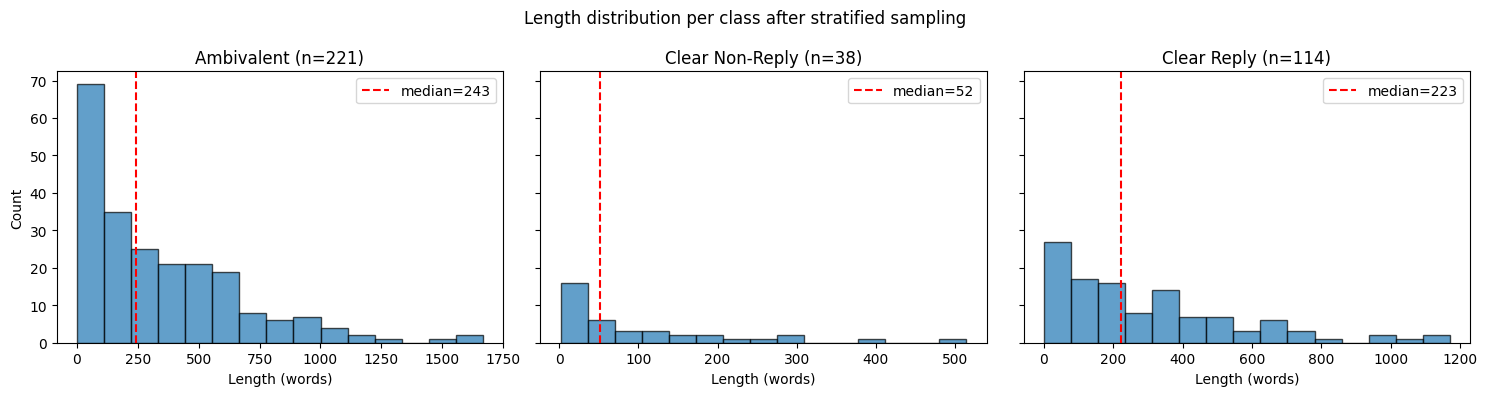

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
for ax, (label, group) in zip(axes, exp_df.groupby('clarity_label')):
    ax.hist(group['length'], bins=15, edgecolor='black', alpha=0.7)
    ax.axvline(group['length'].median(), color='red', linestyle='--', label=f'median={group["length"].median():.0f}')
    ax.set_title(f'{label} (n={len(group)})')
    ax.set_xlabel('Length (words)')
    ax.legend()
axes[0].set_ylabel('Count')
plt.suptitle('Length distribution per class after stratified sampling')
plt.tight_layout()
plt.show()

## Device

In [20]:
device_manager = DeviceManager()
device_manager.summary()
device = device_manager.device


print("Python exe:", sys.executable)
print("Torch version:", torch.__version__)
print("Torch CUDA build:", torch.version.cuda)
print("CUDA available:", torch.cuda.is_available())
print("GPU count:", torch.cuda.device_count())

Device type: cuda
Current GPU: Tesla T4
Using 2 GPUs with DataParallel
Python exe: /usr/bin/python3
Torch version: 2.10.0+cu128
Torch CUDA build: 12.8
CUDA available: True
GPU count: 2


# Experiments

### Prompting
Prompting is the technique of providing instructions or questions in natural language to a large language model (LLM), so that the model produces the desired output. The wording, structure, and content of the prompt can strongly affect the quality of the response. For this reason, prompt engineering has become an important part of working with LLMs.

In this work, five different models are used. The main comparison is first conducted within the Qwen3.5 family, using three models of different sizes: Qwen3.5-0.8B, Qwen3.5-2B, and Qwen3.5-4B. These models belong to the same model family and follow a similar architecture and training procedure, which allows us to examine more directly how model size affects performance.

The comparison is performed in two levels. First, for each model, different prompting methods are compared, such as zero-shot, few-shot, and Chain-of-Thought prompting. This helps us observe whether changes in the prompting strategy improve the classification results for the same model. Then, a broader comparison is made across the different models, in order to examine whether larger models achieve better overall performance.

In addition to the Qwen3.5 models, two models from another LLM family are also included: Gemma 3 1B and Gemma 3 4B. These models are used to investigate whether the trends observed in the Qwen3.5 family also appear in a different model family. In this way, the experiments examine both the effect of prompting method and the effect of model family and scale.




### Prompting Techniques

Several prompting techniques were tested in order to examine how different prompt designs affect the performance of the models.

**Zero-shot prompting** is the simplest approach. The model is given only the task instruction, without any examples, and it is expected to produce the correct label based only on the prompt and its pretrained knowledge. This method is fast and simple, but it may struggle when the task requires a very specific output format or a clear understanding of the label definitions.

**Few-shot prompting** extends zero-shot prompting by including a small number of input-output examples in the prompt. These examples act as demonstrations and help the model understand the expected classification pattern and output format. In this work, few-shot prompting is used to examine whether providing examples improves the model’s ability to classify the answers correctly.

**Semantic (kNN) few-shot example selection** is a variation of few-shot prompting that changes *how* the demonstrations are chosen. Instead of selecting examples randomly from the pool set, each question–answer pair is encoded into a dense vector with a sentence-embedding model (`all-MiniLM-L6-v2`), and for every test instance the most similar pool examples are retrieved using cosine similarity. A balanced option is also used, which first selects one similar example from each class (Clear Reply, Ambivalent, Clear Non-Reply) before filling the remaining slots, so that the prompt is not biased toward a single label. This method is tested with different numbers of examples (K = 3, 6) to examine whether semantically relevant demonstrations help more than random ones.

**Chain-of-Thought (CoT) prompting** encourages the model to reason before producing the final answer. Instead of directly outputting a label, the model is guided to think step by step and then give the final classification. This technique can be useful when the task requires more careful interpretation of the question and the answer. However, since the current task is a label classification task, CoT prompting may also increase the risk of invalid outputs if the model does not follow the required final format.

**Chain-of-Thought with Few-shot (CoT + FS)** combines the two previous ideas. The prompt includes a small number of demonstrations, but each demonstration also contains a short reasoning chain before its final label, not just the label alone. In this way the model is shown not only the expected output, but also the kind of reasoning that leads to it, which can make the produced reasoning more consistent with the task.

**Self-Consistency** extends Chain-of-Thought prompting by replacing the single greedy reasoning path with several sampled ones. The model is queried multiple times with sampling enabled (temperature = 1, top-p = 0.9), producing several independent reasoning chains and their labels, and the final prediction is obtained through a majority vote over the valid labels. The underlying assumption is that, even if individual reasoning paths are occasionally wrong, the correct label tends to be the one most consistently reached across different paths.

### Decoding strategy.
For the classification experiments, greedy decoding (`do_sample=False`) was chosen as the default decoding method. Since the task requires the model to output only a short, fixed label, deterministic decoding is preferable: it always selects the most probable token, which keeps the predictions reproducible and avoids introducing random variation that offers no benefit when the expected output is a single class name. Sampling-based decoding (`do_sample=True`, temperature = 1, top-p = 0.9) is therefore not used for the main label predictions, but only in the Self-Consistency setting, where randomness is intentionally required: there, several diverse reasoning paths are sampled and combined through a majority vote, so a non-deterministic decoder is essential in order to generate different chains instead of repeating the same one.

## Evaluation Metrics

Since the LLM is used as a generative model, its output is free-form text rather than a fixed class prediction. For this reason, the raw model response must first be parsed and mapped to one of the three valid labels:

- **Clear Reply**
- **Ambivalent**
- **Clear Non-Reply**

If none of the expected labels can be detected, the prediction is recorded as:

```text
Invalid
```

Invalid predictions may occur when the model generates an explanation instead of only a label, uses unexpected wording, refuses to answer, or does not follow the requested output format.

Invalid predictions are kept as a separate category instead of being automatically mapped to one of the valid labels. This is important because an invalid output represents a different type of failure: it is not only a classification error, but also an instruction-following or formatting error.

The final evaluation reports the following metrics:

- **accuracy**
- **macro-F1**
- **weighted-F1**
- **macro precision**
- **macro recall**
- **number and percentage of invalid predictions**

Accuracy is computed over all samples. Therefore, every `Invalid` prediction is counted as incorrect.

Macro-F1 is one of the most important metrics for this task because the dataset is imbalanced. The **Ambivalent** class is the majority class, while **Clear Non-Reply** is the minority class. Since macro-F1 gives equal weight to each class, it provides a better indication of whether the model performs well across all labels, instead of mainly benefiting from the majority class.

Weighted-F1 is also reported, but it is influenced by the class distribution. As a result, a model may achieve a relatively high weighted-F1 score even if it performs poorly on the minority class.

The confusion matrix includes `Invalid` as an additional predicted category whenever invalid outputs exist. This makes it possible to observe which true classes most often lead to invalid generations.

Finally, the `error_summary` function separates errors into two types:

- **wrong-label errors**, where the model predicts one of the three valid labels, but the prediction is incorrect
- **invalid-format errors**, where the model does not produce a valid label

This distinction helps identify whether a model mainly fails because it confuses the classes, or because it does not follow the required output format.

# Qwen/Qwen3.5-0.8B

Qwen3.5-0.8B is the smallest model in the Qwen3.5 family. It contains 752,393,024 parameters (≈0.75B), uses a vocabulary of 248,320 tokens, and supports a native context length of 262,144 tokens. 

In [21]:
model_name = "Qwen/Qwen3.5-0.8B"

#If the tokenizer does not define a padding token, the end-of-sequence token is used as the padding token. This is necessary for batched inference, where input sequences must be padded to the same length.
#Left padding was used because the experiments are performed in batches for a decoder-only LLM. If the tokenizer did not define a padding token, the end-of-sequence token was used as the padding token.

tokenizer = AutoTokenizer.from_pretrained(model_name, padding_side="left")
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token


model = AutoModelForCausalLM.from_pretrained(
    model_name,
    torch_dtype="auto", #The model was loaded with automatic data type selection and automatic device mapping, allowing PyTorch/Transformers to place the model on the available hardware efficiently.
    device_map="auto" 
)


n_params = sum(p.numel() for p in model.parameters())

print(tokenizer.chat_template is not None)
print(f"Model name: {model_name}")
print(f"Total parameters: {n_params:,} ({n_params/1e9:.2f}B)")
print(f"Context length: {model.config.max_position_embeddings:,} tokens")
print(f"Dtype: {model.dtype}") 
print(f"Vocab size: {model.config.vocab_size:,}")


config.json:   0%|          | 0.00/2.91k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/16.7k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/6.72M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/3.35M [00:00<?, ?B/s]

chat_template.jinja:   0%|          | 0.00/7.75k [00:00<?, ?B/s]

model.safetensors.index.json:   0%|          | 0.00/50.9k [00:00<?, ?B/s]

model.safetensors-00001-of-00001.safeten(…):   0%|          | 0.00/1.75G [00:00<?, ?B/s]

[transformers] The fast path is not available because one of the required library is not installed. Falling back to torch implementation. To install follow https://github.com/fla-org/flash-linear-attention#installation and https://github.com/Dao-AILab/causal-conv1d


Loading weights:   0%|          | 0/320 [00:00<?, ?it/s]

True
Model name: Qwen/Qwen3.5-0.8B
Total parameters: 752,393,024 (0.75B)
Context length: 262,144 tokens
Dtype: torch.bfloat16
Vocab size: 248,320


## Zero-Shot 

In the zero-shot setting, the model receives only the task instruction and the current question–answer pair. No labeled examples are included in the prompt.
This setting evaluates whether the model can understand the classification task directly from the instruction.

The input instance is provided in the following form:

```text
Question: ...
Answer: ...
```
Two types of prompts are tested:

1. A simple instruction prompt that only describes the task and the valid labels.
2. A more detailed instruction prompt that explains the meaning of each label and emphasizes that the model should evaluate the answer with respect to the specific sub-question.

Both greedy decoding and sampling-based decoding are tested in order to observe whether randomness improves or hurts classification performance.

#### Example
Before running the full experiments, a single example is passed through the tokenizer in order to inspect the exact prompt format that is given to the model.

The `apply_chat_template` function converts the system and user messages into the chat format expected by Qwen. The option `tokenize=False` returns the formatted prompt as plain text, which makes it easier to inspect. The option `add_generation_prompt=True` adds the assistant generation marker at the end of the prompt, indicating that the model should now produce the answer.

Since this is a label-only classification task, `max_new_tokens=10` is sufficient because the valid outputs are short. Greedy decoding with `do_sample=False` is used in this initial test because it is deterministic and reproducible. 

The printed chat template also shows the `<think></think>` section. In the actual classification experiments, reasoning is disabled when supported, because some larger Qwen models enable thinking behavior by default. Since this is a label-only classification task, disabling reasoning helps keep the output short and easier to parse.

In [22]:
system_prompt = """You are an expert classifier.
Given the interview question and the president's answer, classify the answer into exactly one of the following labels:
Labels:
- Clear Reply
- Ambivalent
- Clear Non-Reply

Output the label only."""

example = exp_df.iloc[1]

user_content = f"Question: {example['question']}\nAnswer: {example['interview_answer']}"

messages = [
    {"role": "system", "content": system_prompt},
    {"role": "user", "content": user_content},
]
prompt = tokenizer.apply_chat_template( messages, tokenize=False,  add_generation_prompt=True , enable_thinking= False )

print(prompt)  

<|im_start|>system
You are an expert classifier.
Given the interview question and the president's answer, classify the answer into exactly one of the following labels:
Labels:
- Clear Reply
- Ambivalent
- Clear Non-Reply

Output the label only.<|im_end|>
<|im_start|>user
Question: Will the United States recognize it?
Answer: I suggest you study the Ahtisaari plan. Not to be, like, the, you know, grumpy guy. Well, how to get— how do we get more peacekeepers into Darfur? Of course, what has been delaying getting more peacekeepers has been the lack of understanding between the U.N. and the Government of Sudan on the status of forces agreement. Now that one has been signed, I think it has cleared the way. There are many volunteers, and as Chair of the African Union, we certainly seek out more and more volunteers as they are needed. We use our good offices to see more and more African countries contribute. We have volunteered to contribute one battalion. If there is need for another one, we

Here the full generation pipeline is run **manually** on a single example. The prompt is tokenized, the model generates a short output with greedy decoding, and `_parse_label` maps the raw text to one of the three valid labels (or `Invalid`). This makes the prompt → raw output → parsed-label flow explicit before it is wrapped into the batch helper functions.

In [23]:
def _parse_label(resp, labels=("Clear Reply", "Ambivalent", "Clear Non-Reply")):
    if "</think>" in resp:
        resp = resp.split("</think>")[-1]
    resp = resp.strip()
    
    for label in sorted(labels, key=len, reverse=True):
        if label.lower() in resp.lower():
            return label
    return "Invalid"


inputs = tokenizer(
    prompt,
    return_tensors="pt"
).to(model.device)

input_length = inputs["input_ids"].shape[-1]

with torch.no_grad():
    outputs = model.generate(
        **inputs,
        max_new_tokens=10,
        do_sample=False,
        pad_token_id=tokenizer.pad_token_id
    )

full_output = tokenizer.decode(outputs[0], skip_special_tokens=False)

generated_only = tokenizer.decode(
    outputs[0][input_length:],
    skip_special_tokens=False
).strip()

print("\n===== FULL OUTPUT: PROMPT + MODEL RESPONSE =====")
print(full_output)

print("\n===== ONLY MODEL RESPONSE =====")
print(repr(generated_only))

print("\n===== PARSED LABEL =====")
print(_parse_label(generated_only))


===== FULL OUTPUT: PROMPT + MODEL RESPONSE =====
<|im_start|>system
You are an expert classifier.
Given the interview question and the president's answer, classify the answer into exactly one of the following labels:
Labels:
- Clear Reply
- Ambivalent
- Clear Non-Reply

Output the label only.<|im_end|>
<|im_start|>user
Question: Will the United States recognize it?
Answer: I suggest you study the Ahtisaari plan. Not to be, like, the, you know, grumpy guy. Well, how to get— how do we get more peacekeepers into Darfur? Of course, what has been delaying getting more peacekeepers has been the lack of understanding between the U.N. and the Government of Sudan on the status of forces agreement. Now that one has been signed, I think it has cleared the way. There are many volunteers, and as Chair of the African Union, we certainly seek out more and more volunteers as they are needed. We use our good offices to see more and more African countries contribute. We have volunteered to contribute o

The same single example is now passed through the `classify_batch` helper, confirming that the batched wrapper reproduces the manual pipeline above.

In [24]:
system_prompt = """You are an expert classifier.
Given the interview question and the president's answer, classify the answer into exactly one of the following labels:
Labels:
- Clear Reply
- Ambivalent
- Clear Non-Reply

Output the label only."""
example = exp_df.iloc[1]
preds, raws = classify_batch(
    [example['question']], [example['interview_answer']],
    system_prompt, model, tokenizer
)
print(f"Question: {example['question']}")
print(f"Answer: {example['interview_answer'][:200]}...")
print(f"Gold label: {example['clarity_label']}")
print(f"Raw model output: {repr(raws[0])}")
print(f"Parsed: {preds[0]}")

Question: Will the United States recognize it?
Answer: I suggest you study the Ahtisaari plan. Not to be, like, the, you know, grumpy guy. Well, how to get— how do we get more peacekeepers into Darfur? Of course, what has been delaying getting more peacek...
Gold label: Clear Non-Reply
Raw model output: '- Clear Non-Reply'
Parsed: Clear Non-Reply


### Zero shot Experiments

####  Zero-Shot Baseline  


Zero-shot:   0%|          | 0/94 [00:00<?, ?it/s]

FINAL EVALUATION REPORT
Total Samples: 373
Invalid Predictions: 0 (0.00%)
--------------------------------------------------
Accuracy:          0.5147
F1-Macro:          0.4474
F1-Weighted:       0.5199
Precision Macro:   0.4459
Recall Macro:      0.4558
--------------------------------------------------
Detailed Classification Report:
                 precision    recall  f1-score   support

    Clear Reply       0.42      0.54      0.47       114
     Ambivalent       0.63      0.54      0.59       221
Clear Non-Reply       0.28      0.29      0.29        38

       accuracy                           0.51       373
      macro avg       0.45      0.46      0.45       373
   weighted avg       0.53      0.51      0.52       373



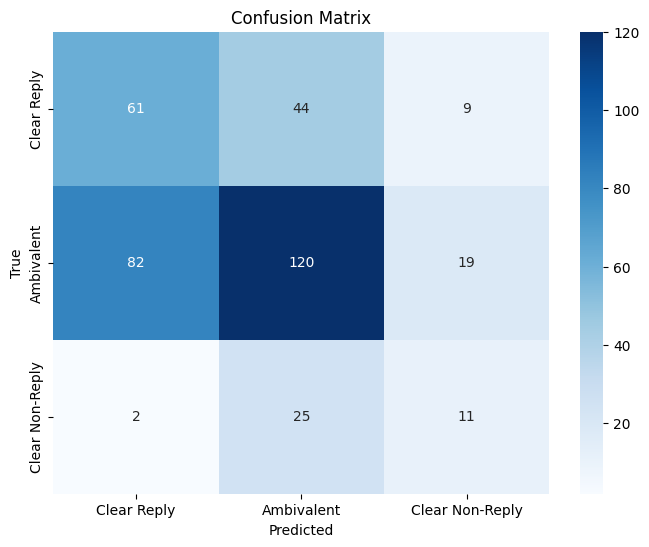

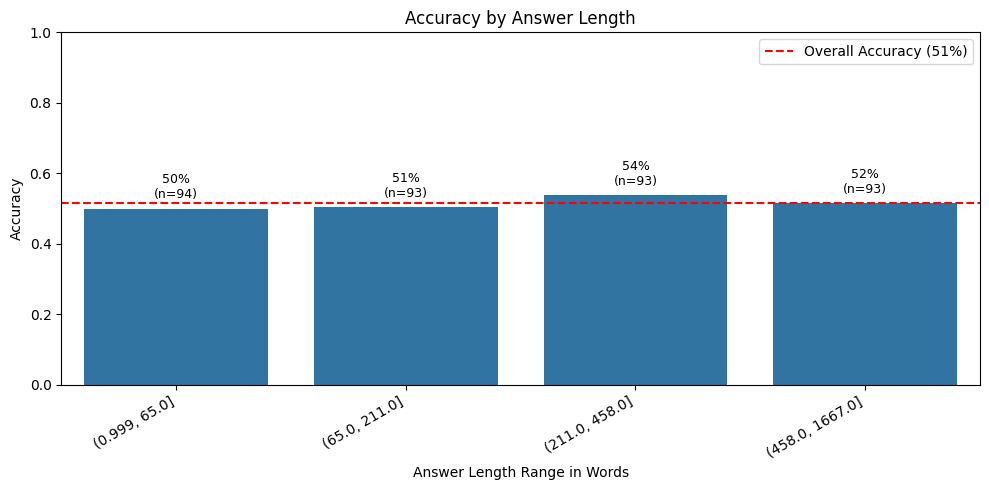

Total samples:     373
Errors:            181 (48.5%)
  - Wrong label:   181 (48.5%)
  - Invalid:       0 (0.0%)
Correct:           192 (51.5%)

Most common confusion patterns (true → predicted):
  Ambivalent           → Clear Reply          : 82
  Clear Reply          → Ambivalent           : 44
  Clear Non-Reply      → Ambivalent           : 25
  Ambivalent           → Clear Non-Reply      : 19
  Clear Reply          → Clear Non-Reply      : 9
  Clear Non-Reply      → Clear Reply          : 2



In [25]:
system_prompt = """You are an expert classifier.
Given the interview question and the president's answer, classify the answer into exactly one of the following labels:
Labels:
- Clear Reply
- Ambivalent
- Clear Non-Reply

Output the label only."""
    
BATCH_SIZE = 4
all_predictions = []
all_raw_outputs = []

for i in tqdm(range(0, len(exp_df), BATCH_SIZE), desc="Zero-shot"):

    batch_df = exp_df.iloc[i : i + BATCH_SIZE]
    
    preds, raws = classify_batch(
         batch_df['question'].tolist(),
        batch_df['interview_answer'].tolist(),
        system_prompt,
        model,
        tokenizer
    )
    
    all_predictions.extend(preds)
    all_raw_outputs.extend(raws)

exp_df['predicted_label'] = all_predictions
exp_df['raw_model_output'] = all_raw_outputs


        

results_q08_zs_1 = evaluate_results(exp_df)
plot_error_by_length(exp_df)
error_summary(exp_df) 

#### Experiments - Prompt Design

In these experiments, different prompt formulations were tested in order to examine whether additional task knowledge or changes in the prompt structure could improve the model’s classification performance.

The baseline prompt was modified in three different ways.

First, the prompt was simplified by removing some guiding information. More specifically, the instruction that the model should behave as an expert classifier was removed, as well as the explicit requirement about the expected output format. This was tested in order to observe whether a shorter and less constrained prompt would affect the model’s predictions.

Second, a more detailed prompt was used. This prompt was more developed than the baseline, as it included explicit definitions for the three labels:

- **Clear Reply:** the president directly and clearly answers the specific question.
- **Ambivalent:** it is unclear or ambiguous whether the president actually answered the specific question.
- **Clear Non-Reply:** the president completely avoids, ignores, or fails to answer the question.

In addition, dataset-specific observations from the exploratory analysis were added as context rules. For example, the prompt stated that the question may be a sub-question extracted from a larger interview, and that if the answer discusses multiple topics, only the part relevant to the given question should be evaluated. Another observation added to the prompt was the possible relation between answer length and the labels, where longer answers were often associated with **Ambivalent**, while shorter answers were more often associated with **Clear Non-Reply**.

Finally, another variation was tested where no separate system prompt was used. Instead, the initial system  prompt was placed inside the user message together with the question and answer. This experiment was used to check whether the model performs differently when all instructions are given as part of the user prompt rather than through a separate system message.

Overall, none of these prompt modifications improved the classification results compared to the baseline. On the contrary, both the simplified prompt and the more detailed prompt with dataset-specific rules caused the model to classify almost all answers as **Clear Reply**. This suggests that removing important constraints can make the task too vague, while adding too many extra rules can also confuse the model or bias it toward one class. Therefore, the experiment shows that the prompt needs to be specific enough to guide the model, but not overloaded with additional information that may distract it from the main classification task.

The experiment where the baseline system instruction was moved into the user prompt did not perform as poorly as the other modified prompts. However, it still did not outperform the original baseline setup. Therefore, the baseline prompt remained the most effective configuration among the tested prompt variants.

Interestingly, despite the worse classification performance, these experiments did not produce invalid outputs. The model continued to return valid label names, which means that the output format was generally respected.

**First variant — simplified prompt.** 
Some guiding information is removed (the “expert classifier” instruction and the explicit output-format requirement) to test whether a shorter, less constrained prompt changes the model's predictions.

Removing the guiding information from the prompt hurt the 0.8B model. Both the macro-F1 and the weighted-F1 fell to about 0.31, well below the zero-shot baseline (macro-F1 0.45, accuracy 0.51), which shows that the shorter, less constrained instruction did not let the model separate the three labels effectively. With the "expert classifier" role and the explicit output-format requirement removed, the model defaulted to a single answer and classified almost every sample as Clear Reply, so the other two classes were largely ignored. The outputs were still valid labels, so the failure here is one of class bias rather than format: the prompt became too vague to guide the decision, and the model fell back on the easiest, most frequent-sounding label.

GPU free: 14.87 GB


Zero-shot:   0%|          | 0/94 [00:00<?, ?it/s]

FINAL EVALUATION REPORT
Total Samples: 373
Invalid Predictions: 0 (0.00%)
--------------------------------------------------
Accuracy:          0.3566
F1-Macro:          0.3137
F1-Weighted:       0.3212
Precision Macro:   0.3553
Recall Macro:      0.3936
--------------------------------------------------
Detailed Classification Report:
                 precision    recall  f1-score   support

    Clear Reply       0.35      0.75      0.47       114
     Ambivalent       0.55      0.17      0.26       221
Clear Non-Reply       0.17      0.26      0.20        38

       accuracy                           0.36       373
      macro avg       0.36      0.39      0.31       373
   weighted avg       0.45      0.36      0.32       373



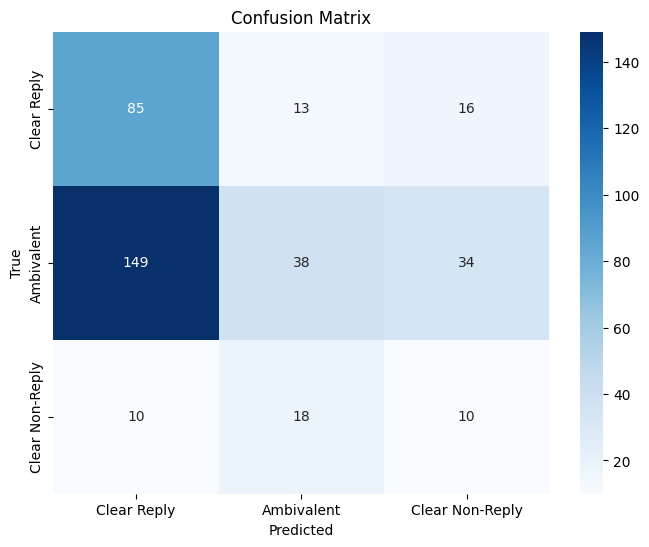

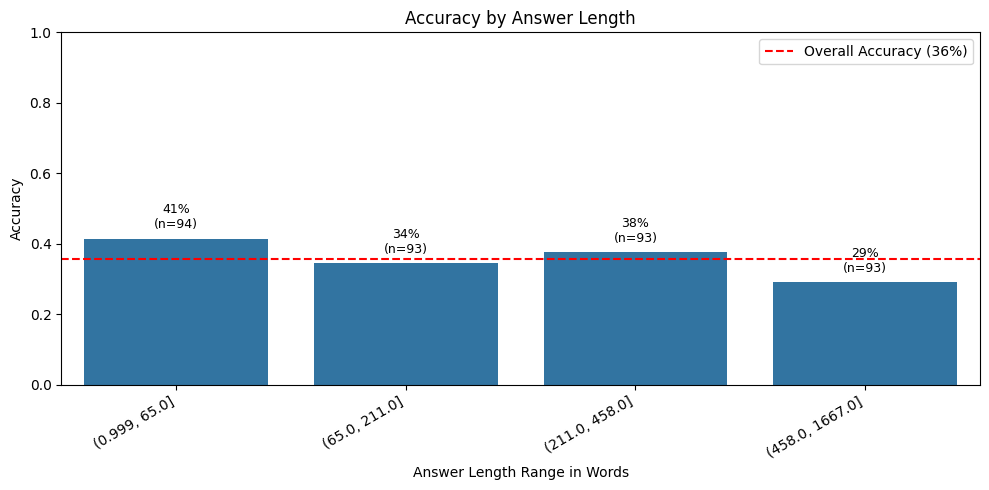

Total samples:     373
Errors:            240 (64.3%)
  - Wrong label:   240 (64.3%)
  - Invalid:       0 (0.0%)
Correct:           133 (35.7%)

Most common confusion patterns (true → predicted):
  Ambivalent           → Clear Reply          : 149
  Ambivalent           → Clear Non-Reply      : 34
  Clear Non-Reply      → Ambivalent           : 18
  Clear Reply          → Clear Non-Reply      : 16
  Clear Reply          → Ambivalent           : 13
  Clear Non-Reply      → Clear Reply          : 10



In [26]:
cleanup_gpu() 
system_prompt = """
Given the interview question and the president's answer, classify the answer into exactly one of the following labels:
Labels:
- Clear Reply
- Ambivalent
- Clear Non-Reply
"""
    
BATCH_SIZE = 4
all_predictions = []
all_raw_outputs = []

for i in tqdm(range(0, len(exp_df), BATCH_SIZE), desc="Zero-shot"):

    batch_df = exp_df.iloc[i : i + BATCH_SIZE]
    
    preds, raws = classify_batch(
        batch_df['question'].tolist(),
        batch_df['interview_answer'].tolist(),
        system_prompt,
        model,
        tokenizer
    )
   
    all_predictions.extend(preds)
    all_raw_outputs.extend(raws)

exp_df['predicted_label'] = all_predictions
exp_df['raw_model_output'] = all_raw_outputs


        

results_q08_zs_2=evaluate_results(exp_df)
plot_error_by_length(exp_df)
error_summary(exp_df) 

**Second variant — detailed prompt.**
This prompt adds explicit definitions for the three labels and the dataset-specific context rules described above (sub-questions, multi-topic answers, and the length–label relationship).



GPU free: 14.87 GB


Zero-shot:   0%|          | 0/94 [00:00<?, ?it/s]

FINAL EVALUATION REPORT
Total Samples: 373
Invalid Predictions: 0 (0.00%)
--------------------------------------------------
Accuracy:          0.3056
F1-Macro:          0.2657
F1-Weighted:       0.2206
Precision Macro:   0.3284
Recall Macro:      0.4055
--------------------------------------------------
Detailed Classification Report:
                 precision    recall  f1-score   support

    Clear Reply       0.33      0.77      0.47       114
     Ambivalent       0.48      0.05      0.09       221
Clear Non-Reply       0.17      0.39      0.24        38

       accuracy                           0.31       373
      macro avg       0.33      0.41      0.27       373
   weighted avg       0.40      0.31      0.22       373



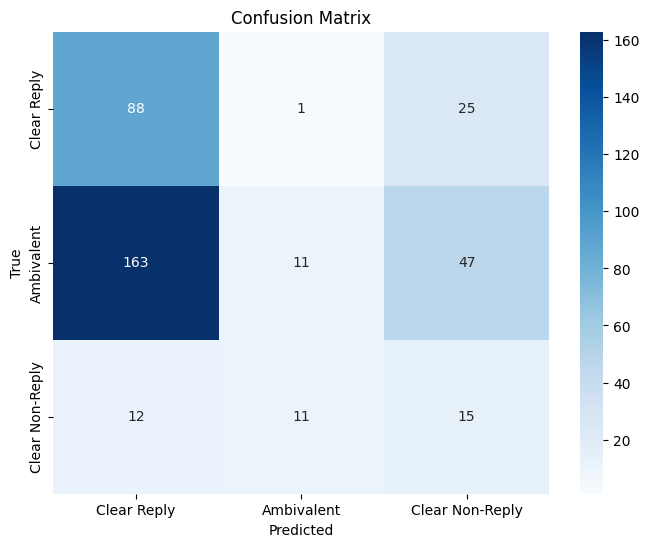

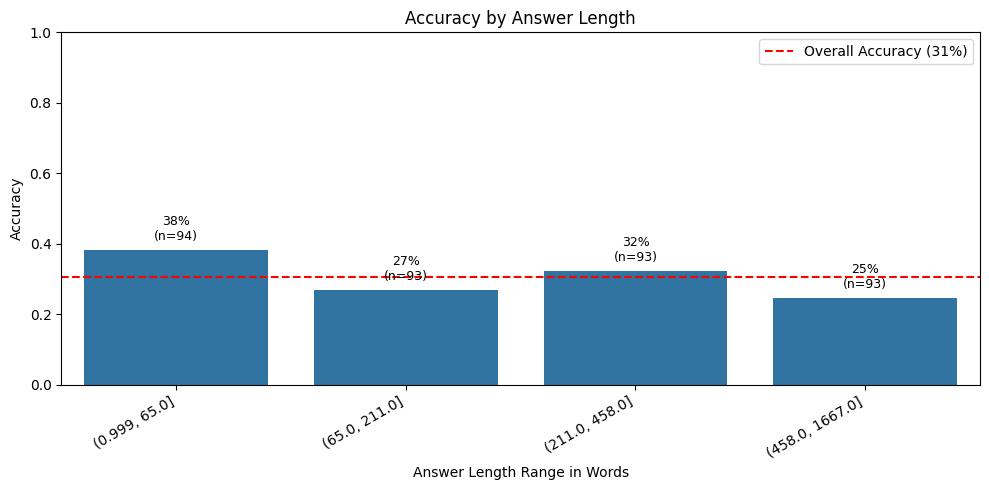

Total samples:     373
Errors:            259 (69.4%)
  - Wrong label:   259 (69.4%)
  - Invalid:       0 (0.0%)
Correct:           114 (30.6%)

Most common confusion patterns (true → predicted):
  Ambivalent           → Clear Reply          : 163
  Ambivalent           → Clear Non-Reply      : 47
  Clear Reply          → Clear Non-Reply      : 25
  Clear Non-Reply      → Clear Reply          : 12
  Clear Non-Reply      → Ambivalent           : 11
  Clear Reply          → Ambivalent           : 1



In [27]:
# Detailed prompt
cleanup_gpu() 

system_prompt = """You are an expert classifier.
Given the interview question and a president's answer, classify the answer into exactly one of the following labels:
Labels:
- Clear Reply: The president directly and clearly answers the specific question.
- Ambivalent: It is unclear or ambiguous whether the president actually answered the specific question.
- Clear Non-Reply: The president completely avoids, ignores, or fails to answer the question.

Context Rules:
1. The provided question may be a sub-question extracted from a larger interview.
2. If the president's answer covers multiple topics, evaluate only the specific portion of the answer that is relevant to the given question.
3. Usually, longer answers are Ambivalent and shorter answers are Clear Non-Reply.
Output the label only.

"""

BATCH_SIZE = 4
all_predictions = []
all_raw_outputs = []

for i in tqdm(range(0, len(exp_df), BATCH_SIZE), desc="Zero-shot"):
    batch_df = exp_df.iloc[i : i + BATCH_SIZE]
    
    
    preds, raws = classify_batch(
        batch_df['question'].tolist(),
        batch_df['interview_answer'].tolist(),
        system_prompt,
        model,
        tokenizer
    )
   
    
    all_predictions.extend(preds)
    all_raw_outputs.extend(raws)

exp_df['predicted_label'] = all_predictions
exp_df['raw_model_output'] = all_raw_outputs


        

results_q08_zs_3 = evaluate_results(exp_df)
plot_error_by_length(exp_df)
error_summary(exp_df) 

**Third variant — no system prompt.** 
The baseline instruction is moved into the user message itself (see `classify_batch_without_system_prompt`), so the model receives all instructions as part of the user turn rather than through a separate system message.

Moving the whole baseline instruction into the user message (instead of a separate system prompt) also lowered performance relative to the baseline, but less severely than the simplified and detailed variants. The macro-F1 dropped to 0.30 while the weighted-F1 reached 0.37. The notable difference is that this configuration recognised the Ambivalent class better than the other two prompt-design variants, which had collapsed almost entirely onto Clear Reply. Even so, the overall quality stayed below the baseline, so placing all the instructions in the user turn changed the model's behaviour without improving classification. The outputs remained valid labels throughout, confirming that the problem was class separation rather than output format.

GPU free: 14.87 GB


Zero-shot:   0%|          | 0/94 [00:00<?, ?it/s]

FINAL EVALUATION REPORT
Total Samples: 373
Invalid Predictions: 0 (0.00%)
--------------------------------------------------
Accuracy:          0.3887
F1-Macro:          0.3002
F1-Weighted:       0.3723
Precision Macro:   0.3219
Recall Macro:      0.3422
--------------------------------------------------
Detailed Classification Report:
                 precision    recall  f1-score   support

    Clear Reply       0.34      0.68      0.45       114
     Ambivalent       0.54      0.30      0.38       221
Clear Non-Reply       0.09      0.05      0.07        38

       accuracy                           0.39       373
      macro avg       0.32      0.34      0.30       373
   weighted avg       0.43      0.39      0.37       373



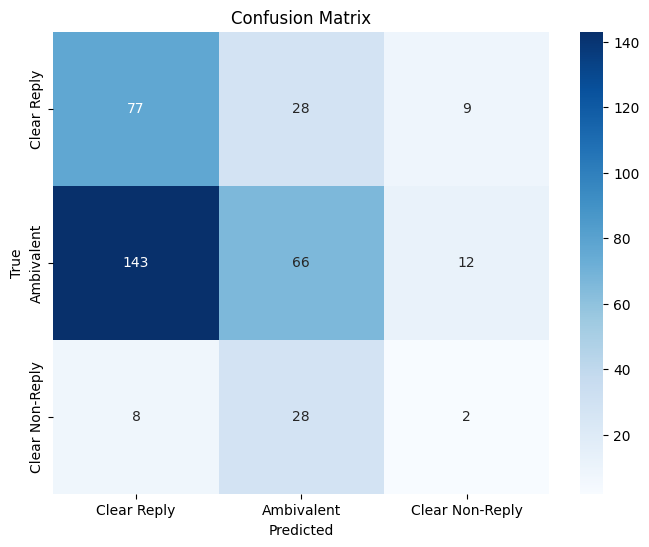

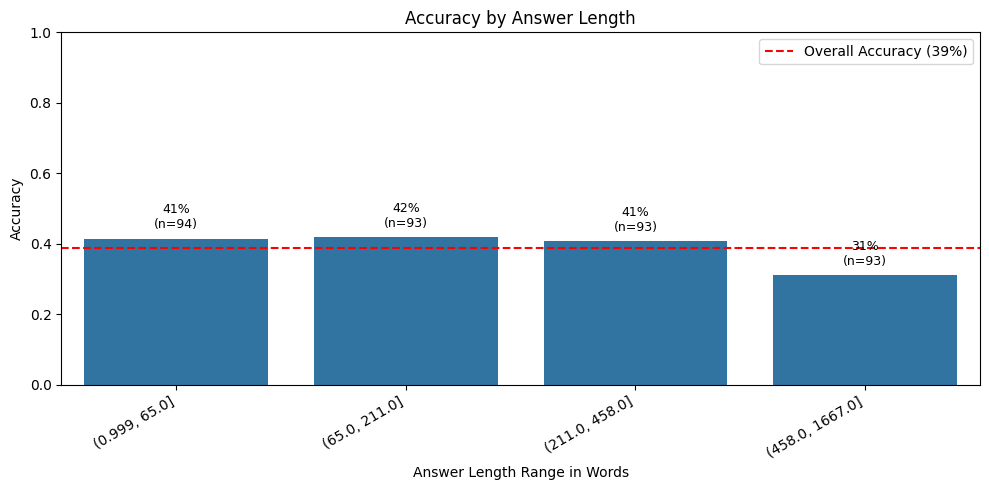

Total samples:     373
Errors:            228 (61.1%)
  - Wrong label:   228 (61.1%)
  - Invalid:       0 (0.0%)
Correct:           145 (38.9%)

Most common confusion patterns (true → predicted):
  Ambivalent           → Clear Reply          : 143
  Clear Non-Reply      → Ambivalent           : 28
  Clear Reply          → Ambivalent           : 28
  Ambivalent           → Clear Non-Reply      : 12
  Clear Reply          → Clear Non-Reply      : 9
  Clear Non-Reply      → Clear Reply          : 8



In [28]:
# Without system prompt
def _parse_label(resp, labels=("Clear Reply", "Ambivalent", "Clear Non-Reply")):
    if "</think>" in resp:
        resp = resp.split("</think>")[-1]
    resp = resp.strip()
    
    for label in sorted(labels, key=len, reverse=True):
        if label.lower() in resp.lower():
            return label
    return "Invalid"


def _build_generation_config(
    max_new_tokens,
    do_sample,
    temperature,
    top_p,
    top_k,
    repetition_penalty,
    pad_token_id,
    extra_kwargs,
):
    """Build a generate() kwargs dict, including sampling params only when sampling."""
    cfg = {
        "max_new_tokens": max_new_tokens,
        "do_sample": do_sample,
        "repetition_penalty": repetition_penalty,
        "pad_token_id": pad_token_id,
    }
    if do_sample:
        cfg["temperature"] = temperature
        cfg["top_p"] = top_p
        cfg["top_k"] = top_k

    cfg.update(extra_kwargs)
    return cfg
    
def classify_batch_without_system_prompt(
    questions,
    answers,
    system_prompt,
    model,
    tokenizer,
    max_new_tokens=20,
    enable_thinking= False, 
    do_sample=False,
    temperature=1.0,
    top_p=1.0,
    top_k=50,
    repetition_penalty=1.0,
    **gen_kwargs,
):
    # Left padding + pad token fallback 
    tokenizer.padding_side = "left"
    tokenizer.truncation_side = "right"
    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token

    batch_prompts = []
    for q, a in zip(questions, answers):
        messages = [
            {"role": "user", "content": f"{system_prompt} \n Question: {q}\nAnswer: {a}"}, #  different way of passing the prompt to the llm , using only user
        ]
        prompt = tokenizer.apply_chat_template( messages, tokenize=False, 
                                               add_generation_prompt=True, enable_thinking=enable_thinking )
        batch_prompts.append(prompt)

    inputs = tokenizer(
        batch_prompts,
        return_tensors="pt",
        padding=True,
    ).to(model.device)
    input_length = inputs["input_ids"].shape[-1]

    generation_config = _build_generation_config(
        max_new_tokens=max_new_tokens,
        do_sample=do_sample,
        temperature=temperature,
        top_p=top_p,
        top_k=top_k,
        repetition_penalty=repetition_penalty,
        pad_token_id=tokenizer.pad_token_id,
        extra_kwargs=gen_kwargs,
    )

    with torch.no_grad():
        outputs = model.generate(**inputs, **generation_config)

    batch_raw_responses = [
        tokenizer.decode(
            outputs[i][input_length:], skip_special_tokens=True
        ).strip()
        for i in range(len(questions))
    ]

    batch_preds = [_parse_label(resp) for resp in batch_raw_responses]
    return batch_preds, batch_raw_responses
    
cleanup_gpu() 

system_prompt = """You are an expert classifier.
Given the interview question and the president's answer, classify the answer into exactly one of the following labels:
Labels:
- Clear Reply
- Ambivalent
- Clear Non-Reply

Output the label only."""
    
BATCH_SIZE = 4
all_predictions = []
all_raw_outputs = []

for i in tqdm(range(0, len(exp_df), BATCH_SIZE), desc="Zero-shot"):

    batch_df = exp_df.iloc[i : i + BATCH_SIZE]
    
    preds, raws = classify_batch_without_system_prompt(
        batch_df['question'].tolist(),
        batch_df['interview_answer'].tolist(),
        system_prompt,
        model,
        tokenizer
    )
   
    all_predictions.extend(preds)
    all_raw_outputs.extend(raws)

exp_df['predicted_label'] = all_predictions
exp_df['raw_model_output'] = all_raw_outputs


        

results_q08_zs_4=evaluate_results(exp_df)
plot_error_by_length(exp_df)
error_summary(exp_df) 

## Few-shot  

In the few-shot experiments, labeled examples are added inside the prompt before the test question–answer pair. These examples are used as demonstrations, helping the model understand the expected classification behavior and the exact output format.

The few-shot examples are selected from the pool set. This avoids data leakage between the examples shown in the prompt and the samples used for evaluation.



In the few-shot setting, a small number of labeled examples are inserted into the prompt before the current evaluation instance.

Each few-shot example is formatted as a user message containing the question and answer, followed by an assistant message containing the correct label:

```text
Question: ...
Answer: ...

<Label>
```

The few-shot examples are selected from `pool_df`, while the actual experiments are evaluated on `exp_df`. This separation ensures that the examples shown inside the prompt do not overlap with the evaluation instances.
Different numbers of examples are tested in order to examine whether providing more demonstrations helps the model distinguish between **Clear Reply**, **Ambivalent**, and **Clear Non-Reply**.


#### Random Few-shot Examples Selection

In this experiment, few-shot examples were selected randomly from the pool set and inserted into the prompt. To make the prompt more balanced, one example was selected from each class: `Clear Reply`, `Ambivalent`, and `Clear Non-Reply`.

Each selected example included the interview question, the president's answer, and the correct label. These examples were used as demonstrations to help the model understand the expected classification behavior and output format.

Since the examples are selected randomly, the results may vary depending on which samples are included in the prompt. Therefore, this method was used as a simple few-shot baseline before testing more informed example selection method.

In [29]:
fewshot_df = pd.concat([
    pool_df[pool_df["clarity_label"] == label].sample(n=1, random_state=42)
    for label in ["Clear Reply", "Ambivalent", "Clear Non-Reply"]
]).reset_index(drop=True)

fewshot_examples1 = [
    {
        "question": row["question"],
        "answer": row["interview_answer"],
        "label": row["clarity_label"]
    }
    for _, row in fewshot_df.iterrows()
]
fewshot_examples1

[{'question': 'Did you touch on Afghanistan and the safe withdrawal of troops?',
  'answer': "Yes. Yes, yes, and yes. Let me go back to the first part.The reason it didn't go longer is: When is the last time two heads of state have spent over 2 hours in direct conversation across a table, going into excruciating detail? You may know of a time; I don't. I can't think of one.So we didn't need, as we got through, when we brought in the larger group—our defense, our intelligence, and our foreign—well, our—my Foreign Minister—wasn't the Foreign Minister—my Secretary of State was with me the whole time—our Ambassador, et cetera. We brought everybody in. We had covered so much.And so there was a summary done by him and by me of what we covered. Lavrov and Blinken talked about what we had covered. We raised things that required more amplification or made sure we didn't have any misunderstandings. And so it was, kind of—after 2 hours, there, we looked at each other like, Okay, what next?What is

#### FS Prompt Example

In [30]:
cleanup_gpu() 

system_prompt = """You are an expert classifier.
Given the interview question and the president's answer, classify the answer into exactly one of the following labels:
Labels:
- Clear Reply
- Ambivalent
- Clear Non-Reply

Output the label only."""

example = exp_df.iloc[1]

example = exp_df.iloc[1]
q = example["question"]
a = example["interview_answer"]

demo_messages = []
if fewshot_examples1 is not None:
    for ex in fewshot_examples1:
        demo_messages.append({
            "role": "user",
            "content": f"Question: {ex['question']}\nAnswer: {ex['answer']}",
        })
        demo_messages.append({
            "role": "assistant",
            "content": ex["label"],
        })

messages = [{"role": "system", "content": system_prompt}]
messages.extend(demo_messages)
messages.append({
    "role": "user",
    "content": f"Question: {q}\nAnswer: {a}",
})

prompt = tokenizer.apply_chat_template(
    messages, tokenize=False, add_generation_prompt=True
)
print(prompt)

GPU free: 14.87 GB
<|im_start|>system
You are an expert classifier.
Given the interview question and the president's answer, classify the answer into exactly one of the following labels:
Labels:
- Clear Reply
- Ambivalent
- Clear Non-Reply

Output the label only.<|im_end|>
<|im_start|>user
Question: Did you touch on Afghanistan and the safe withdrawal of troops?
Answer: Yes. Yes, yes, and yes. Let me go back to the first part.The reason it didn't go longer is: When is the last time two heads of state have spent over 2 hours in direct conversation across a table, going into excruciating detail? You may know of a time; I don't. I can't think of one.So we didn't need, as we got through, when we brought in the larger group—our defense, our intelligence, and our foreign—well, our—my Foreign Minister—wasn't the Foreign Minister—my Secretary of State was with me the whole time—our Ambassador, et cetera. We brought everybody in. We had covered so much.And so there was a summary done by him and

###  Few shot Experiment Random Selection



Few-shot evaluation with one example per class and random selection of the samples.

GPU free: 14.87 GB


Few-shot:   0%|          | 0/187 [00:00<?, ?it/s]

FINAL EVALUATION REPORT
Total Samples: 373
Invalid Predictions: 0 (0.00%)
--------------------------------------------------
Accuracy:          0.5630
F1-Macro:          0.2738
F1-Weighted:       0.4590
Precision Macro:   0.3988
Recall Macro:      0.3252
--------------------------------------------------
Detailed Classification Report:
                 precision    recall  f1-score   support

    Clear Reply       0.60      0.05      0.10       114
     Ambivalent       0.60      0.92      0.72       221
Clear Non-Reply       0.00      0.00      0.00        38

       accuracy                           0.56       373
      macro avg       0.40      0.33      0.27       373
   weighted avg       0.54      0.56      0.46       373



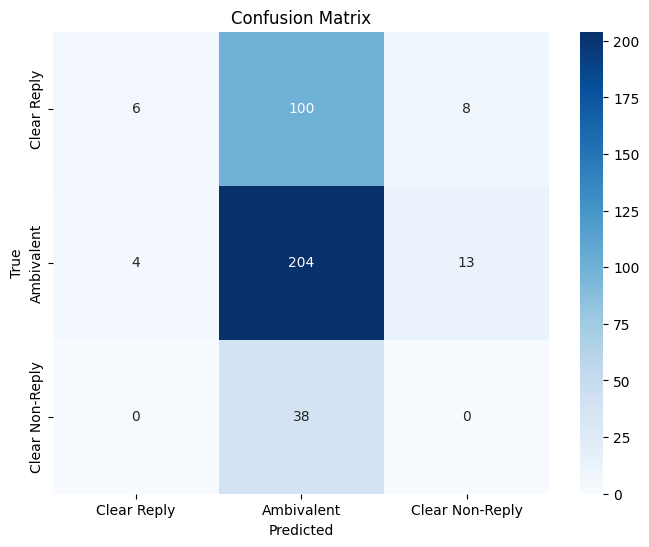

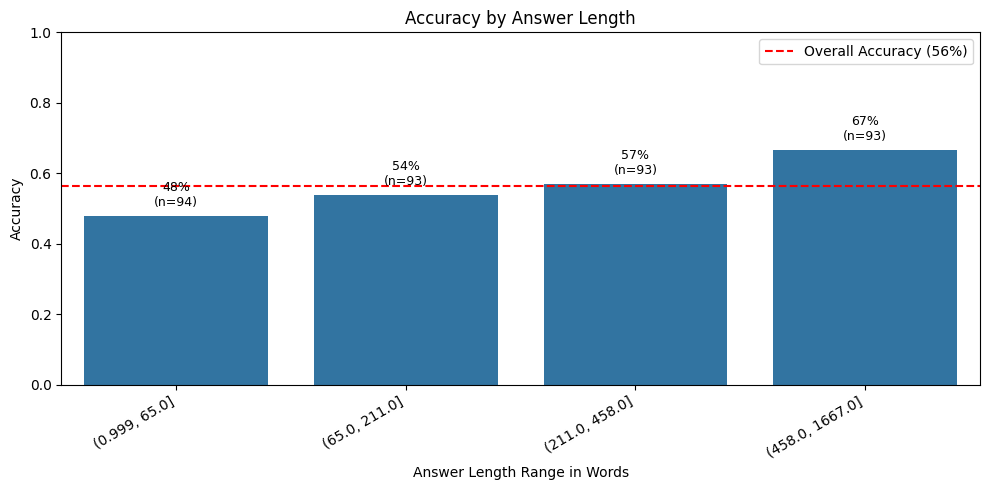

Total samples:     373
Errors:            163 (43.7%)
  - Wrong label:   163 (43.7%)
  - Invalid:       0 (0.0%)
Correct:           210 (56.3%)

Most common confusion patterns (true → predicted):
  Clear Reply          → Ambivalent           : 100
  Clear Non-Reply      → Ambivalent           : 38
  Ambivalent           → Clear Non-Reply      : 13
  Clear Reply          → Clear Non-Reply      : 8
  Ambivalent           → Clear Reply          : 4



In [31]:
# 1 EXAMPLES PER CLASS

cleanup_gpu() 
system_prompt = """You are an expert classifier.
Given the interview question and the president's answer, classify the answer into exactly one of the following labels:
Labels:
- Clear Reply
- Ambivalent
- Clear Non-Reply

Output the label only."""
BATCH_SIZE = 2
all_predictions = []
all_raw_outputs = []

for i in tqdm(range(0, len(exp_df), BATCH_SIZE), desc="Few-shot"):
    batch_df = exp_df.iloc[i : i + BATCH_SIZE]
    preds, raws = classify_batch_fewshot( 
        batch_df['question'].tolist(),
        batch_df['interview_answer'].tolist(),
        system_prompt,
        model,
        tokenizer,
        fewshot_examples=fewshot_examples1, 
    )
    all_predictions.extend(preds)
    all_raw_outputs.extend(raws)

exp_df['predicted_label'] = all_predictions
exp_df['raw_model_output'] = all_raw_outputs

        

results_q08_fs_1 = evaluate_results(exp_df)
plot_error_by_length(exp_df)
error_summary(exp_df) 

### Semantic Few-Shot Example Selection

In addition to randomly selected few-shot examples, a semantic retrieval approach was also implemented. Instead of selecting examples randomly from the pool set, this method selects examples that are semantically similar to the current test sample.

For this purpose, the `sentence-transformers` library was used with the `all-MiniLM-L6-v2` embedding model. Each question-answer pair from the pool set was converted into a dense vector representation. The text representation consisted of both the interview question and the corresponding answer, since the classification depends on the relationship between the two.

The embeddings of all pool examples were precomputed once before running the experiments. This makes the retrieval process more efficient, because the pool embeddings do not need to be recalculated for every test sample.

For each new test example, the current question-answer pair is also embedded. Then, cosine similarity is computed between the current embedding and all pool embeddings. Since the embeddings are normalized, the dot product between vectors is equivalent to cosine similarity. The pool examples are then ranked from most similar to least similar.

The `knn_examples` function returns the top `k` most similar examples in dictionary format, containing the question, answer, and label. These examples can then be inserted into the few-shot prompt.

A balanced option was also included. When `balanced=True`, the function first attempts to select one semantically similar example from each class: `Clear Reply`, `Ambivalent`, and `Clear Non-Reply`. This helps ensure that the few-shot prompt contains examples from all possible labels, instead of being biased toward only one class. If fewer than `k` examples are selected after this step, the remaining examples are filled using the next most similar examples.

This experiment does not use batched inference. Although the classification function supports batch input, each call contains only one test sample because the few-shot examples are dynamically selected for each instance using kNN.

In [32]:

# Load a sentence embedding model.
# This model converts each question-answer pair into a dense vector representation.
# Semantically similar texts will have embeddings that are close to each other.
embedder = SentenceTransformer("all-MiniLM-L6-v2", device=str(device))

def make_text(q, a, ):
    """
    Creates the text representation that will be embedded.

    The question and answer are combined into a single text, because the
    similarity should be based on the full question-answer pair.
    The answer is truncated to avoid very long inputs.
    """
    return f"Question: {q}\nAnswer: {a}"



# Precompute the embeddings of all examples in the pool set.
# This is done only once for efficiency, instead of recomputing them
# every time we need few-shot examples for a new test sample.

pool_texts  = [make_text(r['question'], r['interview_answer']) for _, r in pool_df.iterrows()]
pool_emb    = embedder.encode(pool_texts, normalize_embeddings=True, show_progress_bar=True)

# Store the corresponding labels, questions, and answers from the pool set.
# These will be used later when returning the selected few-shot examples.

pool_labels = pool_df['clarity_label'].tolist()
pool_q, pool_a = pool_df['question'].tolist(), pool_df['interview_answer'].tolist()

def knn_examples(q, a, k=3, balanced=True):

    """
    Selects k semantically similar few-shot examples from the pool set.

    The function embeds the current question-answer pair and compares it
    with all precomputed pool embeddings using cosine similarity.

    If balanced=True, the function first tries to select one example from
    each class. This helps avoid few-shot prompts that contain examples
    only from the same label.
    """
    qe   = embedder.encode([make_text(q, a)], normalize_embeddings=True)[0]
    sims = pool_emb @ qe                       
    order = np.argsort(-sims)
    if balanced:
        chosen, seen = [], set()
        for idx in order:                      
            if pool_labels[idx] not in seen:
                chosen.append(idx); seen.add(pool_labels[idx])
            if len(seen) == 3: break
        for idx in order:                      
            if len(chosen) >= k: break
            if idx not in chosen: chosen.append(idx)
        idxs = chosen[:k]
    else:
        idxs = order[:k]
    return [{"question": pool_q[i], "answer": pool_a[i], "label": pool_labels[i]} for i in idxs]

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/95 [00:00<?, ?it/s]

### Examples
Before running the full kNN few-shot experiments, the semantic retrieval is inspected on a single test instance. For one question–answer pair, the `knn_examples` function returns the most similar pool examples, which are displayed in a table with the answers truncated for readability; the retrieved examples are then inserted into the few-shot prompt and the resulting prediction is compared with the true label. This is first shown with `balanced=True` for K = 3 and K = 6, in order to see how increasing the number of demonstrations changes both which examples are selected and the final prediction. A further example with `balanced=False` (K = 3) is also demonstrated, where the examples are chosen purely by similarity without enforcing one per class, so that the difference between balanced and unbalanced retrieval can be observed.

In [33]:
cleanup_gpu()
system_prompt = """You are an expert classifier.
Given the interview question and the president's answer, classify the answer into exactly one of the following labels:
Labels:
- Clear Reply
- Ambivalent
- Clear Non-Reply

Output the label only."""

K = 3
all_predictions, all_raw_outputs = [], []
row = exp_df.iloc[5]
dyn = knn_examples(row['question'], row['interview_answer'], k=K, balanced=True)

dyn_df = pd.DataFrame(dyn)
dyn_df["answer"] = dyn_df["answer"].str.slice(0, 500) + "..."

display(dyn_df)


preds, raws = classify_batch_fewshot(
        [row['question']], [row['interview_answer']],
        system_prompt, model, tokenizer, fewshot_examples=dyn
    )
print("True label:")
print(row["clarity_label"])

print("\nPrediction:")
print(preds[0])



GPU free: 14.78 GB


,question,answer,label
0,How soon will journalists be able to have access to the facilities?,"I will commit to transparency and as soon as I am in a position to be able to implement what we are doing right now.And one of the reasons I haven't gone down—I have all my—my chief folks have gone down—is I don't want to become the issue. I don't want to be, you know, bringing all of the Secret Service and everybody with me to get in the way. So this is being set up, and you'll have full access to everything once we get this thing moving....",Ambivalent
1,"Will you commit to transparency on this issue, Mr. President?","I will commit to transparency and as soon as I am in a position to be able to implement what we are doing right now.And one of the reasons I haven't gone down—I have all my—my chief folks have gone down—is I don't want to become the issue. I don't want to be, you know, bringing all of the Secret Service and everybody with me to get in the way. So this is being set up, and you'll have full access to everything once we get this thing moving....",Clear Reply
2,Are they considering banning or restricting the access of Chinese journalists in the United States?,"So I haven't really been given a full briefing on that. We're going to look at it. We will look at it. It's something that I don't like to see. I don't think it's fair, because we give very good access. Maybe some people would say we give too good. I don't think—I don't believe in that. I think we give very good access, so I don't think it's fair. But we'll have a decision made on that relatively soon. Okay? Thank you. Good question.Please, go ahead. Go ahead. Go ahead....",Clear Non-Reply


True label:
Clear Reply

Prediction:
Clear Reply


In [34]:
cleanup_gpu()
system_prompt = """You are an expert classifier.
Given the interview question and the president's answer, classify the answer into exactly one of the following labels:
Labels:
- Clear Reply
- Ambivalent
- Clear Non-Reply

Output the label only."""

K = 6
all_predictions, all_raw_outputs = [], []
row = exp_df.iloc[5]
dyn = knn_examples(row['question'], row['interview_answer'], k=K, balanced=True)

dyn_df = pd.DataFrame(dyn)
dyn_df["answer"] = dyn_df["answer"].str.slice(0, 500) + "..."

display(dyn_df)


preds, raws = classify_batch_fewshot(
        [row['question']], [row['interview_answer']],
        system_prompt, model, tokenizer, fewshot_examples=dyn
    )
print("True label:")
print(row["clarity_label"])

print("\nPrediction:")
print(preds[0])



GPU free: 14.78 GB


,question,answer,label
0,How soon will journalists be able to have access to the facilities?,"I will commit to transparency and as soon as I am in a position to be able to implement what we are doing right now.And one of the reasons I haven't gone down—I have all my—my chief folks have gone down—is I don't want to become the issue. I don't want to be, you know, bringing all of the Secret Service and everybody with me to get in the way. So this is being set up, and you'll have full access to everything once we get this thing moving....",Ambivalent
1,"Will you commit to transparency on this issue, Mr. President?","I will commit to transparency and as soon as I am in a position to be able to implement what we are doing right now.And one of the reasons I haven't gone down—I have all my—my chief folks have gone down—is I don't want to become the issue. I don't want to be, you know, bringing all of the Secret Service and everybody with me to get in the way. So this is being set up, and you'll have full access to everything once we get this thing moving....",Clear Reply
2,Are they considering banning or restricting the access of Chinese journalists in the United States?,"So I haven't really been given a full briefing on that. We're going to look at it. We will look at it. It's something that I don't like to see. I don't think it's fair, because we give very good access. Maybe some people would say we give too good. I don't think—I don't believe in that. I think we give very good access, so I don't think it's fair. But we'll have a decision made on that relatively soon. Okay? Thank you. Good question.Please, go ahead. Go ahead. Go ahead....",Clear Non-Reply
3,Is that something that you would discuss?,"It's possible that I get involved. But no, it won't have anything to do with—we want to make people better. We want to send them to the areas that most need it. And I think we're going to have something very soon. It's going goodJeff [Jeff Mason, Reuters], please....",Ambivalent
4,Contingency plans for the administration if things don't happen by August 2?,We are going to get this done by August 2.George Condon [National Journal]....,Ambivalent
5,Is there going to be another press conference?,"I love press conferences. It's my press team that's always holding me back. [] I want to talk to you guys every day. [] Sorry, Josh. [] We take the issue of security in large events very seriously. We take the question of security in large-scale events as a very serious issue, which means that we involve all of those bodies or agencies that can and will ensure proper security during the upcoming Olympics. They include the armed forces, the federal police service, and all of the state-level polic...",Ambivalent


True label:
Clear Reply

Prediction:
Clear Reply


In [35]:
cleanup_gpu()
system_prompt = """You are an expert classifier.
Given the interview question and the president's answer, classify the answer into exactly one of the following labels:
Labels:
- Clear Reply
- Ambivalent
- Clear Non-Reply

Output the label only."""

K = 3
all_predictions, all_raw_outputs = [], []
row = exp_df.iloc[5]
dyn = knn_examples(row['question'], row['interview_answer'], k=K, balanced=False)

dyn_df = pd.DataFrame(dyn)
dyn_df["answer"] = dyn_df["answer"].str.slice(0, 500) + "..."

display(dyn_df)


preds, raws = classify_batch_fewshot(
        [row['question']], [row['interview_answer']],
        system_prompt, model, tokenizer, fewshot_examples=dyn
    )
print("True label:")
print(row["clarity_label"])

print("\nPrediction:")
print(preds[0])



GPU free: 14.78 GB


,question,answer,label
0,How soon will journalists be able to have access to the facilities?,"I will commit to transparency and as soon as I am in a position to be able to implement what we are doing right now.And one of the reasons I haven't gone down—I have all my—my chief folks have gone down—is I don't want to become the issue. I don't want to be, you know, bringing all of the Secret Service and everybody with me to get in the way. So this is being set up, and you'll have full access to everything once we get this thing moving....",Ambivalent
1,"Will you commit to transparency on this issue, Mr. President?","I will commit to transparency and as soon as I am in a position to be able to implement what we are doing right now.And one of the reasons I haven't gone down—I have all my—my chief folks have gone down—is I don't want to become the issue. I don't want to be, you know, bringing all of the Secret Service and everybody with me to get in the way. So this is being set up, and you'll have full access to everything once we get this thing moving....",Clear Reply
2,Is that something that you would discuss?,"It's possible that I get involved. But no, it won't have anything to do with—we want to make people better. We want to send them to the areas that most need it. And I think we're going to have something very soon. It's going goodJeff [Jeff Mason, Reuters], please....",Ambivalent


True label:
Clear Reply

Prediction:
Clear Reply


### FS- KNN Experiment 3 examples (balanced)

GPU free: 14.78 GB


kNN Few-shot:   0%|          | 0/373 [00:00<?, ?it/s]

FINAL EVALUATION REPORT
Total Samples: 373
Invalid Predictions: 1 (0.27%)
--------------------------------------------------
Accuracy:          0.5362
F1-Macro:          0.3815
F1-Weighted:       0.5130
Precision Macro:   0.4005
Recall Macro:      0.3879
--------------------------------------------------
Detailed Classification Report:
                 precision    recall  f1-score   support

    Clear Reply       0.42      0.22      0.29       114
     Ambivalent       0.63      0.76      0.69       221
Clear Non-Reply       0.16      0.18      0.17        38

      micro avg       0.54      0.54      0.54       373
      macro avg       0.40      0.39      0.38       373
   weighted avg       0.52      0.54      0.51       373



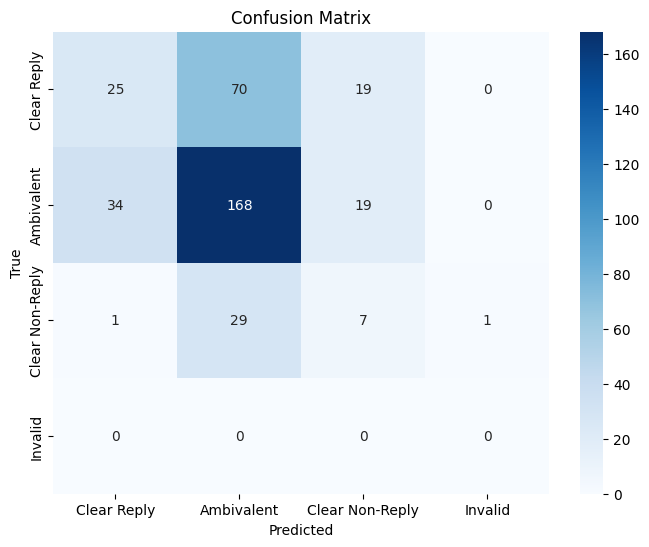

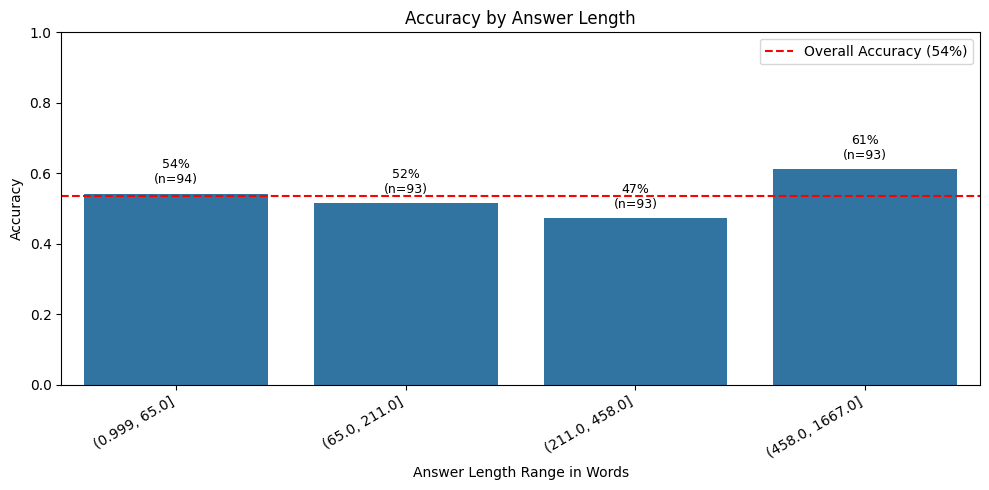

Total samples:     373
Errors:            173 (46.4%)
  - Wrong label:   172 (46.1%)
  - Invalid:       1 (0.3%)
Correct:           200 (53.6%)

Most common confusion patterns (true → predicted):
  Clear Reply          → Ambivalent           : 70
  Ambivalent           → Clear Reply          : 34
  Clear Non-Reply      → Ambivalent           : 29
  Ambivalent           → Clear Non-Reply      : 19
  Clear Reply          → Clear Non-Reply      : 19
  Clear Non-Reply      → Clear Reply          : 1

Sample of Invalid raw outputs (1 of 1):
  [1] (true: Clear Non-Reply) 'No'


In [36]:
cleanup_gpu()
system_prompt = """You are an expert classifier.
Given the interview question and the president's answer, classify the answer into exactly one of the following labels:
Labels:
- Clear Reply
- Ambivalent
- Clear Non-Reply

Output the label only."""

K = 3
all_predictions, all_raw_outputs = [], []

for i in tqdm(range(len(exp_df)), desc="kNN Few-shot"):    
    row = exp_df.iloc[i]
    dyn = knn_examples(row['question'], row['interview_answer'], k=K, balanced=True)
    preds, raws = classify_batch_fewshot(
        [row['question']], [row['interview_answer']],
        system_prompt, model, tokenizer, fewshot_examples=dyn
    )
    all_predictions.extend(preds); all_raw_outputs.extend(raws)

exp_df['predicted_label']  = all_predictions
exp_df['raw_model_output'] = all_raw_outputs

results_q08_knn_fs3_bal = evaluate_results(exp_df)
plot_error_by_length(exp_df)
error_summary(exp_df)

### FS- KNN Experiment 3 examples (unbalanced)

GPU free: 14.78 GB


kNN Few-shot:   0%|          | 0/373 [00:00<?, ?it/s]

FINAL EVALUATION REPORT
Total Samples: 373
Invalid Predictions: 2 (0.54%)
--------------------------------------------------
Accuracy:          0.5818
F1-Macro:          0.4156
F1-Weighted:       0.5380
Precision Macro:   0.5036
Recall Macro:      0.4077
--------------------------------------------------
Detailed Classification Report:
                 precision    recall  f1-score   support

    Clear Reply       0.43      0.23      0.30       114
     Ambivalent       0.62      0.84      0.71       221
Clear Non-Reply       0.46      0.16      0.24        38

      micro avg       0.58      0.58      0.58       373
      macro avg       0.50      0.41      0.42       373
   weighted avg       0.55      0.58      0.54       373



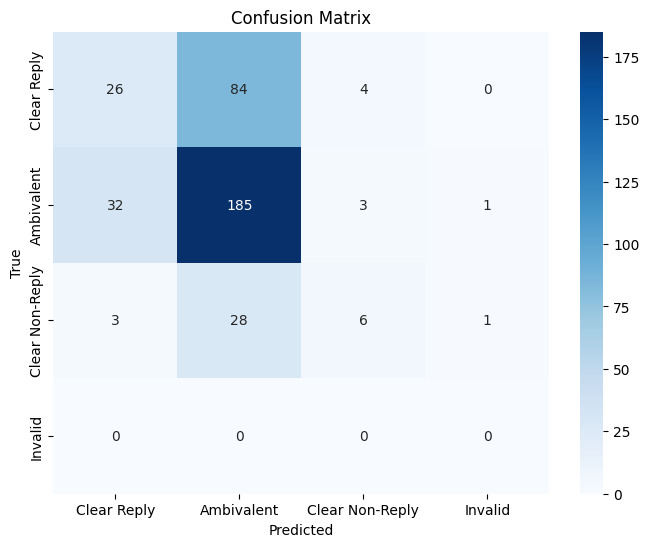

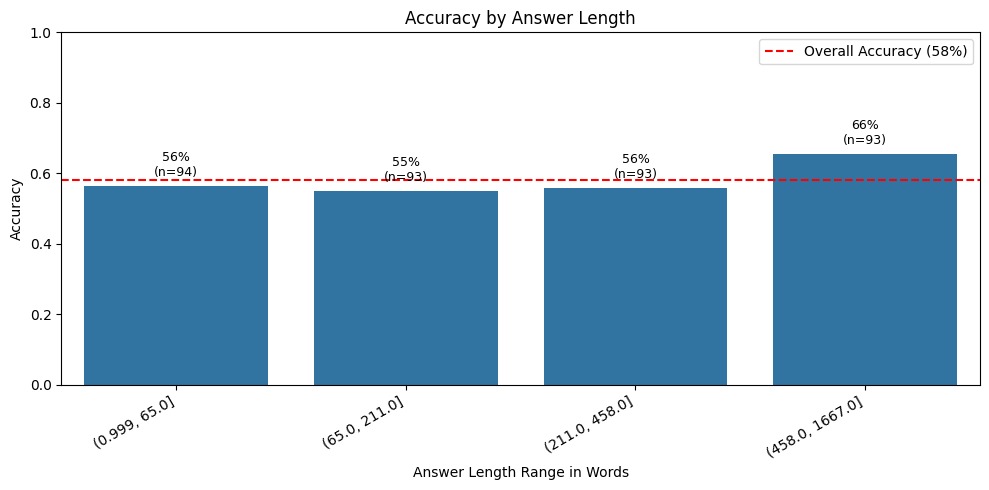

Total samples:     373
Errors:            156 (41.8%)
  - Wrong label:   154 (41.3%)
  - Invalid:       2 (0.5%)
Correct:           217 (58.2%)

Most common confusion patterns (true → predicted):
  Clear Reply          → Ambivalent           : 84
  Ambivalent           → Clear Reply          : 32
  Clear Non-Reply      → Ambivalent           : 28
  Clear Reply          → Clear Non-Reply      : 4
  Ambivalent           → Clear Non-Reply      : 3
  Clear Non-Reply      → Clear Reply          : 3

Sample of Invalid raw outputs (2 of 2):
  [1] (true: Ambivalent) 'Yes'
  [2] (true: Clear Non-Reply) 'No'


In [37]:
cleanup_gpu()
system_prompt = """You are an expert classifier.
Given the interview question and the president's answer, classify the answer into exactly one of the following labels:
Labels:
- Clear Reply
- Ambivalent
- Clear Non-Reply

Output the label only."""

K = 3
all_predictions, all_raw_outputs = [], []

for i in tqdm(range(len(exp_df)), desc="kNN Few-shot"):    
    row = exp_df.iloc[i]
    dyn = knn_examples(row['question'], row['interview_answer'], k=K, balanced=False)
    preds, raws = classify_batch_fewshot(
        [row['question']], [row['interview_answer']],
        system_prompt, model, tokenizer, fewshot_examples=dyn
    )
    all_predictions.extend(preds); all_raw_outputs.extend(raws)

exp_df['predicted_label']  = all_predictions
exp_df['raw_model_output'] = all_raw_outputs

results_q08_knn_fs_Non_bal = evaluate_results(exp_df)
plot_error_by_length(exp_df)
error_summary(exp_df)

### FS- KNN Experiment 6 examples (balanced)

With balanced kNN selection and K = 6 examples, the 0.8B model reached an accuracy of 0.54, a macro-F1 of 0.43, and a weighted-F1 of 0.53, with almost no invalid outputs (2 cases, 0.5%). These scores are very close to the zero-shot baseline (accuracy 0.51, macro-F1 0.45) and to the unbalanced K = 3 setting, so retrieving semantically similar, class-balanced demonstrations keeps performance stable rather than improving it. As in the other settings, the majority Ambivalent class is handled well (F1 = 0.67, recall = 0.71), while the smaller classes remain weak: Clear Reply reaches an F1 of 0.35 and Clear Non-Reply only 0.27. The dominant errors are confusions between Clear Reply and Ambivalent in both directions (64 and 46 cases). Overall, balanced kNN few-shot mainly helps the model respect the output format and lean on the majority class, but it does not solve the difficulty of separating clear replies from ambivalent answers.

In [38]:
# cleanup_gpu()
# system_prompt = """You are an expert classifier.
# Given the interview question and the president's answer, classify the answer into exactly one of the following labels:
# Labels:
# - Clear Reply
# - Ambivalent
# - Clear Non-Reply

# Output the label only."""

# K = 6
# all_predictions, all_raw_outputs = [], []

# for i in tqdm(range(len(exp_df)), desc="kNN Few-shot"):    
#     row = exp_df.iloc[i]
#     dyn = knn_examples(row['question'], row['interview_answer'], k=K, balanced=True)
#     preds, raws = classify_batch_fewshot(
#         [row['question']], [row['interview_answer']],
#         system_prompt, model, tokenizer, fewshot_examples=dyn
#     )
#     all_predictions.extend(preds); all_raw_outputs.extend(raws)

# exp_df['predicted_label']  = all_predictions
# exp_df['raw_model_output'] = all_raw_outputs

# results_q08_knn_fs6_bal  = evaluate_results(exp_df)
# plot_error_by_length(exp_df)
# error_summary(exp_df)

## Chain-of-Thought 

Chain-of-Thought prompting asks the model to produce a short reasoning step before giving the final label.

The expected output format is:

```text
Reasoning: ...
Label: Clear Reply / Ambivalent / Clear Non-Reply
```

The reasoning part is stored separately, while the final prediction is extracted from the `Label:` field.


#### Example 

The exact chat-formatted CoT prompt is printed in order to inspect how the reasoning-plus-label instruction is rendered for the model.

In [39]:
system_prompt = """You are an expert classifier.
Given a question and a president's answer, classify the answer into exactly one of the following labels:
Labels:
- Clear Reply
- Ambivalent
- Clear Non-Reply

Output format:
Reasoning: <2-4 sentences explaining how the answer relates to the specific sub-question>
Label: <Clear Reply | Ambivalent | Clear Non-Reply>
"""

example = exp_df.iloc[0]

user_content = f"Question: {example['question']}\nAnswer: {example['interview_answer']}"

messages = [
    {"role": "system", "content": system_prompt},
    {"role": "user", "content": user_content},
]
prompt = tokenizer.apply_chat_template( messages, tokenize=False,  add_generation_prompt=True , enable_thinking= False )

print(prompt)  

<|im_start|>system
You are an expert classifier.
Given a question and a president's answer, classify the answer into exactly one of the following labels:
Labels:
- Clear Reply
- Ambivalent
- Clear Non-Reply

Output format:
Reasoning: <2-4 sentences explaining how the answer relates to the specific sub-question>
Label: <Clear Reply | Ambivalent | Clear Non-Reply><|im_end|>
<|im_start|>user
Question: What does the President say to other companies who may be hesitant about implementing similar measures?
Answer: Well, I think, you know, we have a lot of people in the White House. And we had one. Basically, we had one person. So—and we had a lot of people that work here. This building is shocking, if you looked at the numbers. And it's also tremendous numbers of people coming in. Normally, you wouldn't do that. But because we're running a country, we want to keep our country running. So we have a lot of people coming in and out. Many of those people—most of those people are tested depending

The CoT generation is first run manually on a single example using the small default max_new_tokens=10 (the kind of default used by the other methods). This demonstrates the problem: with so few tokens there is no room for the reasoning, so the output is cut off before a valid label is produced — which motivates increasing the limit.

In [40]:
def _parse_label(resp, labels=("Clear Reply", "Ambivalent", "Clear Non-Reply")):
    if "</think>" in resp:
        resp = resp.split("</think>")[-1]
    resp = resp.strip()
    
    for label in sorted(labels, key=len, reverse=True):
        if label.lower() in resp.lower():
            return label
    return "Invalid"


inputs = tokenizer(
    prompt,
    return_tensors="pt"
).to(model.device)

input_length = inputs["input_ids"].shape[-1]

with torch.no_grad():
    outputs = model.generate(
        **inputs,
        max_new_tokens=20, # change here the number of tokens beacuse otherwise reasonning doesnt have space and becomes invalid
        do_sample=False,
        pad_token_id=tokenizer.pad_token_id
    )

full_output = tokenizer.decode(outputs[0], skip_special_tokens=False)

generated_only = tokenizer.decode(
    outputs[0][input_length:],
    skip_special_tokens=False
).strip()

print("\n===== FULL OUTPUT: PROMPT + MODEL RESPONSE =====")
print(full_output)

print("\n===== ONLY MODEL RESPONSE =====")
print(repr(generated_only))

print("\n===== PARSED LABEL =====")
print(_parse_label(generated_only))


===== FULL OUTPUT: PROMPT + MODEL RESPONSE =====
<|im_start|>system
You are an expert classifier.
Given a question and a president's answer, classify the answer into exactly one of the following labels:
Labels:
- Clear Reply
- Ambivalent
- Clear Non-Reply

Output format:
Reasoning: <2-4 sentences explaining how the answer relates to the specific sub-question>
Label: <Clear Reply | Ambivalent | Clear Non-Reply><|im_end|>
<|im_start|>user
Question: What does the President say to other companies who may be hesitant about implementing similar measures?
Answer: Well, I think, you know, we have a lot of people in the White House. And we had one. Basically, we had one person. So—and we had a lot of people that work here. This building is shocking, if you looked at the numbers. And it's also tremendous numbers of people coming in. Normally, you wouldn't do that. But because we're running a country, we want to keep our country running. So we have a lot of people coming in and out. Many of thos

The same example is generated again with max_new_tokens=300, now leaving enough room for the model to produce both the reasoning and the final label before the output is parsed.

In [41]:

inputs = tokenizer(
    prompt,
    return_tensors="pt"
).to(model.device)

input_length = inputs["input_ids"].shape[-1]

with torch.no_grad():
    outputs = model.generate(
        **inputs,
        max_new_tokens=300, # change here the number of tokens beacuse otherwise reasonning doesnt have space and becomes invalid
        do_sample=False,
        pad_token_id=tokenizer.pad_token_id
    )

full_output = tokenizer.decode(outputs[0], skip_special_tokens=False)

generated_only = tokenizer.decode(
    outputs[0][input_length:],
    skip_special_tokens=False
).strip()

print("\n===== FULL OUTPUT: PROMPT + MODEL RESPONSE =====")
print(full_output)

print("\n===== ONLY MODEL RESPONSE =====")
print(repr(generated_only))

print("\n===== PARSED LABEL =====")
print(_parse_label(generated_only))


===== FULL OUTPUT: PROMPT + MODEL RESPONSE =====
<|im_start|>system
You are an expert classifier.
Given a question and a president's answer, classify the answer into exactly one of the following labels:
Labels:
- Clear Reply
- Ambivalent
- Clear Non-Reply

Output format:
Reasoning: <2-4 sentences explaining how the answer relates to the specific sub-question>
Label: <Clear Reply | Ambivalent | Clear Non-Reply><|im_end|>
<|im_start|>user
Question: What does the President say to other companies who may be hesitant about implementing similar measures?
Answer: Well, I think, you know, we have a lot of people in the White House. And we had one. Basically, we had one person. So—and we had a lot of people that work here. This building is shocking, if you looked at the numbers. And it's also tremendous numbers of people coming in. Normally, you wouldn't do that. But because we're running a country, we want to keep our country running. So we have a lot of people coming in and out. Many of thos

The same example is passed through the `classify_batch_cot` helper, which returns the predicted label, the extracted reasoning, and the raw output.

In [42]:

system_prompt = """You are an expert classifier.
Given a question and a president's answer, classify the answer into exactly one of the following labels:
Labels:
- Clear Reply
- Ambivalent
- Clear Non-Reply

Output format:
Reasoning: <2-4 sentences explaining how the answer relates to the specific sub-question>
Label: <Clear Reply | Ambivalent | Clear Non-Reply>
"""
preds, reasonings, raws = classify_batch_cot(
    [example['question']], [example['interview_answer']],
    system_prompt, model, tokenizer, max_new_tokens=300
)
print(f"Question: {example['question']}")
print(f"Answer: {example['interview_answer'][:200]}...")
print(f"Gold label: {example['clarity_label']}")
print(f"Raw model output: {repr(raws[0])}")
print(f"Parsed: {preds[0]}")

Question: What does the President say to other companies who may be hesitant about implementing similar measures?
Answer: Well, I think, you know, we have a lot of people in the White House. And we had one. Basically, we had one person. So—and we had a lot of people that work here. This building is shocking, if you looke...
Gold label: Ambivalent
Raw model output: 'Reasoning: The President addresses the specific concern of companies hesitating to implement similar measures by explaining the current operational reality of the White House, noting that many people are tested and that the President has no vulnerability. This response directly addresses the sub-question of how the President justifies the continued operation despite potential hesitancy, providing a factual explanation of the situation.\nLabel: Clear Reply'
Parsed: Clear Reply


###  CoT Experiments


#### CoT Baseline


GPU free: 14.78 GB


CoT:   0%|          | 0/94 [00:00<?, ?it/s]

FINAL EVALUATION REPORT
Total Samples: 373
Invalid Predictions: 0 (0.00%)
--------------------------------------------------
Accuracy:          0.3190
F1-Macro:          0.2897
F1-Weighted:       0.2232
Precision Macro:   0.3545
Recall Macro:      0.4639
--------------------------------------------------
Detailed Classification Report:
                 precision    recall  f1-score   support

    Clear Reply       0.35      0.77      0.48       114
     Ambivalent       0.50      0.04      0.08       221
Clear Non-Reply       0.22      0.58      0.31        38

       accuracy                           0.32       373
      macro avg       0.35      0.46      0.29       373
   weighted avg       0.42      0.32      0.22       373



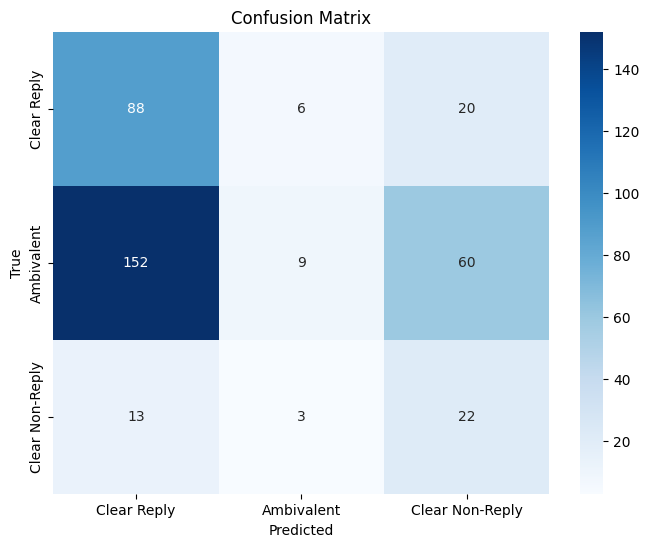

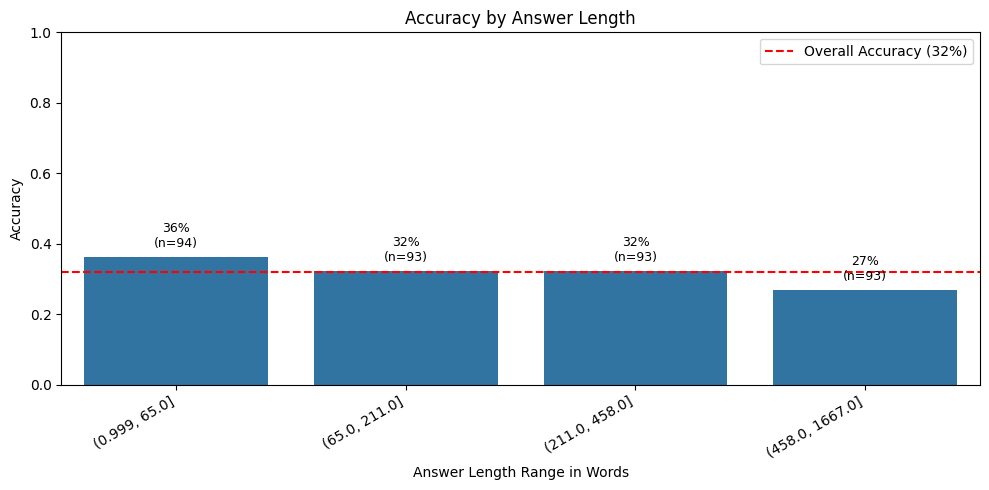

Total samples:     373
Errors:            254 (68.1%)
  - Wrong label:   254 (68.1%)
  - Invalid:       0 (0.0%)
Correct:           119 (31.9%)

Most common confusion patterns (true → predicted):
  Ambivalent           → Clear Reply          : 152
  Ambivalent           → Clear Non-Reply      : 60
  Clear Reply          → Clear Non-Reply      : 20
  Clear Non-Reply      → Clear Reply          : 13
  Clear Reply          → Ambivalent           : 6
  Clear Non-Reply      → Ambivalent           : 3



In [43]:

cleanup_gpu() 
system_prompt = """You are an expert classifier.
Given a question and a president's answer, classify the answer into exactly one of the following labels:
Labels:
- Clear Reply
- Ambivalent
- Clear Non-Reply

Output format:
Reasoning: <2-4 sentences explaining how the answer relates to the specific sub-question>
Label: <Clear Reply | Ambivalent | Clear Non-Reply>
"""

BATCH_SIZE = 4 
all_predictions = []
all_reasonings  = []
all_raw_outputs = []

for i in tqdm(range(0, len(exp_df), BATCH_SIZE), desc="CoT"):
    batch_df = exp_df.iloc[i : i + BATCH_SIZE]

    preds, reasonings, raws = classify_batch_cot(
        batch_df['question'].tolist(),
        batch_df['interview_answer'].tolist(),
        system_prompt,
        model,
        tokenizer,  max_new_tokens=300   )

    all_predictions.extend(preds)
    all_reasonings.extend(reasonings)
    all_raw_outputs.extend(raws)

exp_df['predicted_label'] = all_predictions
exp_df['reasoning_cot']       = all_reasonings
exp_df['raw_model_output'] = all_raw_outputs


results_q08_cot_1 = evaluate_results(exp_df)
plot_error_by_length(exp_df)
error_summary(exp_df)

#### CoT+FS Experiment
Adding few-shot demonstrations to the Chain-of-Thought prompt did not help the 0.8B model. Accuracy fell to 0.31, with a macro-F1 of 0.30 and a weighted-F1 of only 0.25, even though every output was a valid label (0% invalid). The reasoning step pushed the model away from the majority class: Ambivalent collapsed to a recall of just 0.07 (F1 = 0.13), while the two minority classes were heavily over-predicted, Clear Reply (recall 0.62) and Clear Non-Reply (recall 0.79). The confusion matrix confirms this, with Ambivalent answers reassigned mostly to Clear Reply (109 cases) and Clear Non-Reply (96 cases). In short, combining reasoning with examples made the model reason its way out of the dominant class and perform clearly worse than the simpler few-shot setting.


In [44]:
cleanup_gpu()

system_prompt = """You are an expert classifier.
Given a question and a president's answer, classify the answer into exactly one of the following labels:
Labels:
- Clear Reply
- Ambivalent
- Clear Non-Reply

Output format:
Reasoning: <2-4 sentences explaining how the answer relates to the specific sub-question>
Label: <Clear Reply | Ambivalent | Clear Non-Reply>
"""
def build_cot_demos(examples,system_prompt, model, tokenizer, max_new_tokens=200):
    demos = []
    for ex in examples:
        _, reasonings, _ = classify_batch_cot(
            [ex['question']], [ex['answer']],
            system_prompt, model, tokenizer,
            fewshot_examples=None,           
            max_new_tokens=max_new_tokens,
        )
        r = (reasonings[0].strip() if reasonings and reasonings[0]
             else "The answer is evaluated against the specific sub-question.")
        demos.append({
            "question":  ex['question'],
            "answer":    ex['answer'],
            "reasoning": r,
            "label":     ex['label'],        
        })
    return demos
cot_demos = build_cot_demos(fewshot_examples1, system_prompt, model, tokenizer)
cot_demos

GPU free: 14.78 GB


[{'question': 'Did you touch on Afghanistan and the safe withdrawal of troops?',
  'answer': "Yes. Yes, yes, and yes. Let me go back to the first part.The reason it didn't go longer is: When is the last time two heads of state have spent over 2 hours in direct conversation across a table, going into excruciating detail? You may know of a time; I don't. I can't think of one.So we didn't need, as we got through, when we brought in the larger group—our defense, our intelligence, and our foreign—well, our—my Foreign Minister—wasn't the Foreign Minister—my Secretary of State was with me the whole time—our Ambassador, et cetera. We brought everybody in. We had covered so much.And so there was a summary done by him and by me of what we covered. Lavrov and Blinken talked about what we had covered. We raised things that required more amplification or made sure we didn't have any misunderstandings. And so it was, kind of—after 2 hours, there, we looked at each other like, Okay, what next?What is

In [45]:
# cleanup_gpu()
# BATCH_SIZE = 2
# all_predictions, all_reasonings, all_raw_outputs = [], [], []

# for i in tqdm(range(0, len(exp_df), BATCH_SIZE), desc="Few-shot + CoT"):
#     batch_df = exp_df.iloc[i:i+BATCH_SIZE]
#     preds, reasonings, raws = classify_batch_cot(
#         batch_df['question'].tolist(),
#         batch_df['interview_answer'].tolist(),
#         system_prompt, model, tokenizer,
#         fewshot_examples=cot_demos,          
#         max_new_tokens=300,
#     )
#     all_predictions.extend(preds)
#     all_reasonings.extend(reasonings)
#     all_raw_outputs.extend(raws)

# exp_df['predicted_label']  = all_predictions
# exp_df['reasoning_cot']    = all_reasonings
# exp_df['raw_model_output'] = all_raw_outputs

# results_q08_fscot = evaluate_results(exp_df)
# plot_error_by_length(exp_df)
# error_summary(exp_df)

## Self-Consistency

Self-Consistency extends the Chain-of-Thought setting by replacing the single greedy reasoning path with multiple sampled ones. Instead of decoding once, the model is queried K times with sampling enabled (temperature = 1 , top-p = 0.9), producing K independent reasoning chains and their corresponding labels. The final prediction is obtained through a majority vote over the valid sampled labels, while samples that fail to produce a parseable label are excluded from the vote. The underlying assumption is that, although individual reasoning chains may be noisy or occasionally incorrect, the correct label tends to be the one most consistently reached across diverse reasoning paths.

#### Experiment SC
Self-Consistency, which samples several reasoning chains and takes a majority vote, produced almost the same behaviour as plain CoT for the 0.8B model: accuracy 0.32, macro-F1 0.30, and weighted-F1 0.26, with no invalid outputs. The Ambivalent class again nearly disappears from the predictions (recall 0.08, F1 = 0.14), while Clear Reply (recall 0.67) and Clear Non-Reply (recall 0.66) are strongly over-predicted, and the most frequent errors are once more Ambivalent → Clear Reply (130 cases) and Ambivalent → Clear Non-Reply (73 cases). Aggregating multiple reasoning paths did not correct the bias introduced by reasoning; the majority vote simply reinforced the same systematic mistake, so the additional sampling cost of Self-Consistency brought no measurable benefit here.

In [46]:
# cleanup_gpu()
# system_prompt = """You are an expert classifier.
# Given a question and a president's answer, classify the answer into exactly one of the following labels:
# Labels:
# - Clear Reply
# - Ambivalent
# - Clear Non-Reply

# Output format:
# Reasoning: <2-4 sentences explaining how the answer relates to the specific sub-question>
# Label: <Clear Reply | Ambivalent | Clear Non-Reply>
# """

# BATCH_SIZE, N_SAMPLES = 4, 3
# all_predictions, all_votes = [], []

# for i in tqdm(range(0, len(exp_df), BATCH_SIZE), desc="Self-Consistency"):
#     batch_df = exp_df.iloc[i:i+BATCH_SIZE]
#     preds, votes = self_consistency_predict(
#         batch_df['question'].tolist(), batch_df['interview_answer'].tolist(),
#         system_prompt, model, tokenizer,
#         n_samples=N_SAMPLES, temperature=1, top_p=0.9, max_new_tokens=300
#     )
#     all_predictions.extend(preds)
#     all_votes.extend(votes)

# exp_df['predicted_label'] = all_predictions
# exp_df['sc_votes'] = all_votes

# results_q08_sc = evaluate_results(exp_df)
# plot_error_by_length(exp_df)
# error_summary(exp_df)

In [47]:
del model, tokenizer
cleanup_gpu()

GPU free: 15.54 GB


# Qwen/Qwen3.5-2B

Qwen3.5-2B is a model in the Qwen3.5 family. It contains  1,881,825,088  parameters (≈2B), uses a vocabulary of 248,320 tokens, and supports a native context length of 262,144 tokens. 

In [48]:

model_name = "Qwen/Qwen3.5-2B"

tokenizer = AutoTokenizer.from_pretrained(model_name, padding_side="left")
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

model = AutoModelForCausalLM.from_pretrained(
    model_name,
    torch_dtype="auto",
    device_map="auto" 
)

n_params = sum(p.numel() for p in model.parameters())
print(tokenizer.chat_template is not None)
print(f"Model name: {model_name}")
print(f"Total parameters: {n_params:,} ({n_params/1e9:.2f}B)")
print(f"Context length: {model.config.max_position_embeddings:,} tokens")
print(f"Dtype: {model.dtype}") # Each weight is stored in 16 bits instead of the standard 32
print(f"Vocab size: {model.config.vocab_size:,}")


config.json:   0%|          | 0.00/2.91k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/16.7k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/6.72M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/3.35M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/12.8M [00:00<?, ?B/s]

chat_template.jinja:   0%|          | 0.00/7.75k [00:00<?, ?B/s]

model.safetensors.index.json:   0%|          | 0.00/64.5k [00:00<?, ?B/s]

model.safetensors-00001-of-00001.safeten(…):   0%|          | 0.00/4.55G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/320 [00:00<?, ?it/s]

True
Model name: Qwen/Qwen3.5-2B
Total parameters: 1,881,825,088 (1.88B)
Context length: 262,144 tokens
Dtype: torch.bfloat16
Vocab size: 248,320


## Zero-Shot

### Zero shot Experiments


GPU free: 13.71 GB


Zero-shot:   0%|          | 0/94 [00:00<?, ?it/s]

FINAL EVALUATION REPORT
Total Samples: 373
Invalid Predictions: 0 (0.00%)
--------------------------------------------------
Accuracy:          0.3378
F1-Macro:          0.3062
F1-Weighted:       0.1934
Precision Macro:   0.2654
Recall Macro:      0.4561
--------------------------------------------------
Detailed Classification Report:
                 precision    recall  f1-score   support

    Clear Reply       0.33      0.97      0.49       114
     Ambivalent       0.00      0.00      0.00       221
Clear Non-Reply       0.47      0.39      0.43        38

       accuracy                           0.34       373
      macro avg       0.27      0.46      0.31       373
   weighted avg       0.15      0.34      0.19       373



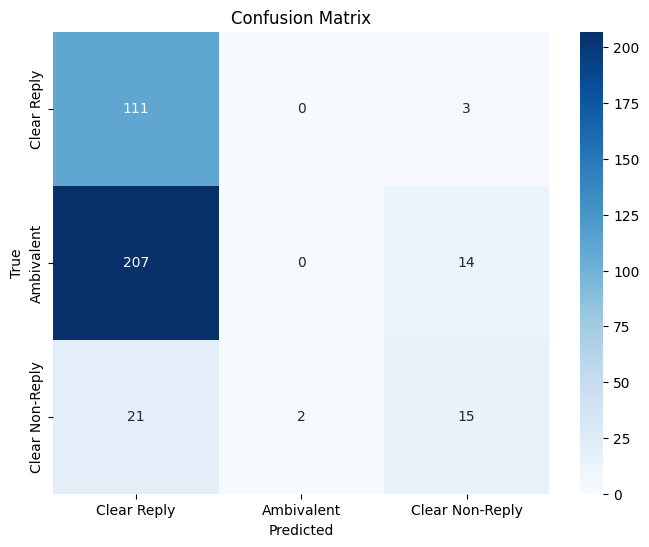

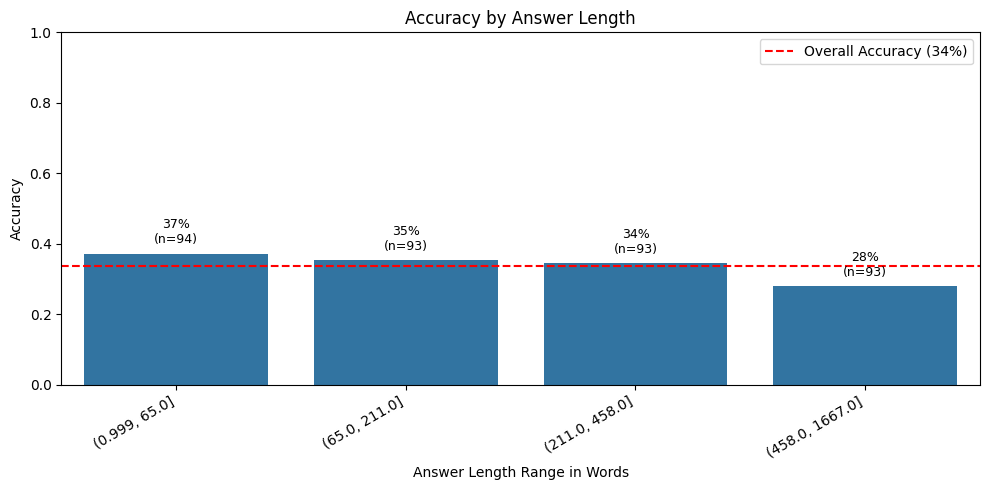

Total samples:     373
Errors:            247 (66.2%)
  - Wrong label:   247 (66.2%)
  - Invalid:       0 (0.0%)
Correct:           126 (33.8%)

Most common confusion patterns (true → predicted):
  Ambivalent           → Clear Reply          : 207
  Clear Non-Reply      → Clear Reply          : 21
  Ambivalent           → Clear Non-Reply      : 14
  Clear Reply          → Clear Non-Reply      : 3
  Clear Non-Reply      → Ambivalent           : 2



In [49]:
cleanup_gpu() 

system_prompt = """You are an expert classifier.
Given the interview question and the president's answer, classify the answer into exactly one of the following labels:
Labels:
- Clear Reply
- Ambivalent
- Clear Non-Reply

Output the label only."""
    
BATCH_SIZE = 4
all_predictions = []
all_raw_outputs = []

for i in tqdm(range(0, len(exp_df), BATCH_SIZE), desc="Zero-shot"):

    batch_df = exp_df.iloc[i : i + BATCH_SIZE]
    
    preds, raws = classify_batch(
         batch_df['question'].tolist(),
        batch_df['interview_answer'].tolist(),
        system_prompt,
        model,
        tokenizer
    )
    
    all_predictions.extend(preds)
    all_raw_outputs.extend(raws)

exp_df['predicted_label'] = all_predictions
exp_df['raw_model_output'] = all_raw_outputs


        

results_q2_zs_1 = evaluate_results(exp_df)
plot_error_by_length(exp_df)
error_summary(exp_df) 

## Few-Shot

#### Few shot Experiment


GPU free: 13.71 GB


kNN Few-shot:   0%|          | 0/373 [00:00<?, ?it/s]

FINAL EVALUATION REPORT
Total Samples: 373
Invalid Predictions: 0 (0.00%)
--------------------------------------------------
Accuracy:          0.4692
F1-Macro:          0.4702
F1-Weighted:       0.4463
Precision Macro:   0.5252
Recall Macro:      0.5365
--------------------------------------------------
Detailed Classification Report:
                 precision    recall  f1-score   support

    Clear Reply       0.38      0.83      0.52       114
     Ambivalent       0.72      0.28      0.40       221
Clear Non-Reply       0.47      0.50      0.49        38

       accuracy                           0.47       373
      macro avg       0.53      0.54      0.47       373
   weighted avg       0.59      0.47      0.45       373



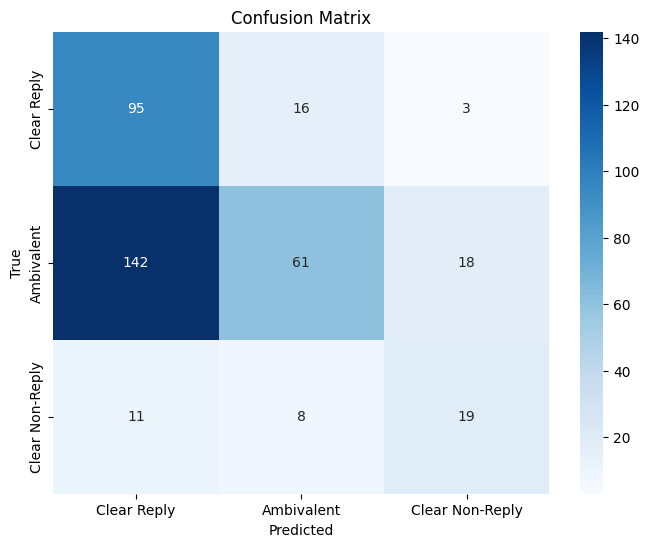

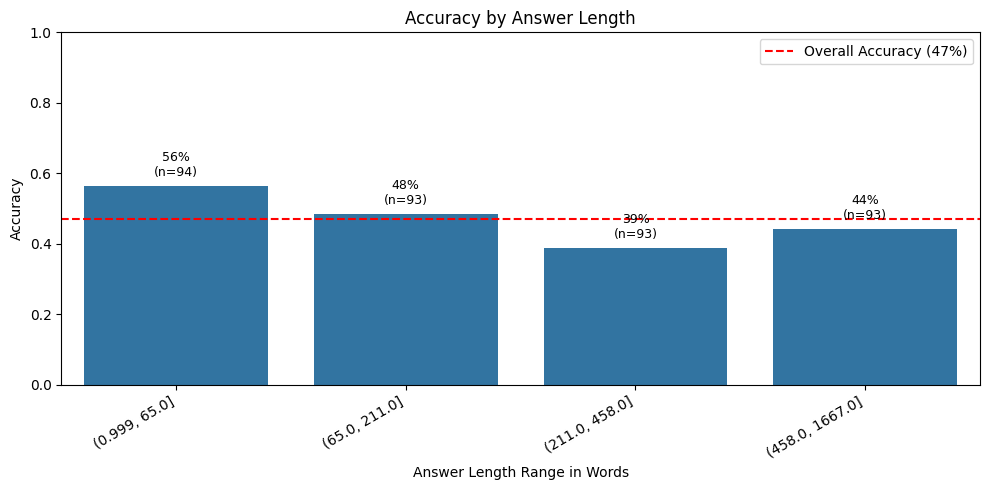

Total samples:     373
Errors:            198 (53.1%)
  - Wrong label:   198 (53.1%)
  - Invalid:       0 (0.0%)
Correct:           175 (46.9%)

Most common confusion patterns (true → predicted):
  Ambivalent           → Clear Reply          : 142
  Ambivalent           → Clear Non-Reply      : 18
  Clear Reply          → Ambivalent           : 16
  Clear Non-Reply      → Clear Reply          : 11
  Clear Non-Reply      → Ambivalent           : 8
  Clear Reply          → Clear Non-Reply      : 3



In [50]:

cleanup_gpu() 
system_prompt = """You are an expert classifier.
Given the interview question and the president's answer, classify the answer into exactly one of the following labels:
Labels:
- Clear Reply
- Ambivalent
- Clear Non-Reply

Output the label only."""

K = 3
all_predictions, all_raw_outputs = [], []

for i in tqdm(range(len(exp_df)), desc="kNN Few-shot"):    
    row = exp_df.iloc[i]
    dyn = knn_examples(row['question'], row['interview_answer'], k=K, balanced=False)
    preds, raws = classify_batch_fewshot(
        [row['question']], [row['interview_answer']],
        system_prompt, model, tokenizer, fewshot_examples=dyn
    )
    all_predictions.extend(preds); all_raw_outputs.extend(raws)

exp_df['predicted_label']  = all_predictions
exp_df['raw_model_output'] = all_raw_outputs

results_q2_knn_fs3_No_bal = evaluate_results(exp_df)
plot_error_by_length(exp_df)
error_summary(exp_df)

## Chain-of-Thought 


#### CoT Experiment
For the 2B model, Chain-of-Thought reached an accuracy of 0.34, a macro-F1 of 0.32, and a weighted-F1 of 0.29, with all outputs valid. The pattern is the same as in the smaller model: reasoning makes the model abandon the majority class, so Ambivalent drops to a recall of 0.11 (F1 = 0.19), while Clear Reply (recall 0.68) and Clear Non-Reply (recall 0.58) are over-predicted. The main confusions are Ambivalent → Clear Reply (132 cases) and Ambivalent → Clear Non-Reply (64 cases). Moving from 0.8B to 2B yields only a modest gain under CoT and does not remove the underlying bias against the dominant Ambivalent class.

In [51]:

# cleanup_gpu() 
# system_prompt = """You are an expert classifier.
# Given a question and a president's answer, classify the answer into exactly one of the following labels:
# Labels:
# - Clear Reply
# - Ambivalent
# - Clear Non-Reply

# Output format:
# Reasoning: <2-4 sentences explaining how the answer relates to the specific sub-question>
# Label: <Clear Reply | Ambivalent | Clear Non-Reply>
# """



# BATCH_SIZE = 2
# all_predictions = []
# all_reasonings  = []
# all_raw_outputs = []

# for i in tqdm(range(0, len(exp_df), BATCH_SIZE), desc="CoT "):
#     batch_df = exp_df.iloc[i : i + BATCH_SIZE]

#     preds, reasonings, raws = classify_batch_cot(
#         batch_df['question'].tolist(),
#         batch_df['interview_answer'].tolist(),
#         system_prompt,
#         model,
#         tokenizer, max_new_tokens=300   )

#     all_predictions.extend(preds)
#     all_reasonings.extend(reasonings)
#     all_raw_outputs.extend(raws)

# exp_df['predicted_label'] = all_predictions
# exp_df['reasoning_cot']       = all_reasonings
# exp_df['raw_model_output'] = all_raw_outputs


# results_q2_cot_1 = evaluate_results(exp_df)
# plot_error_by_length(exp_df)
# error_summary(exp_df)

In [52]:
del model, tokenizer
cleanup_gpu()

GPU free: 15.54 GB


# Qwen/Qwen3.5-4B

Qwen3.5-4B is a large model in the Qwen3.5 family. It contains  4,205,751,296  parameters (≈4B), uses a vocabulary of 248,320 tokens, and supports a native context length of 262,144 tokens. 

In [53]:
model_name = "Qwen/Qwen3.5-4B"

tokenizer = AutoTokenizer.from_pretrained(model_name, padding_side="left")
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

model = AutoModelForCausalLM.from_pretrained(
    model_name,
    torch_dtype="auto",
    device_map="auto" 
)

print(tokenizer.chat_template is not None)

n_params = sum(p.numel() for p in model.parameters())
print(tokenizer.chat_template is not None)
print(f"Model name: {model_name}")
print(f"Total parameters: {n_params:,} ({n_params/1e9:.2f}B)")
print(f"Context length: {model.config.max_position_embeddings:,} tokens")
print(f"Dtype: {model.dtype}") 
print(f"Vocab size: {model.config.vocab_size:,}")


config.json:   0%|          | 0.00/3.16k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/16.7k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/6.72M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/3.35M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/12.8M [00:00<?, ?B/s]

chat_template.jinja:   0%|          | 0.00/7.76k [00:00<?, ?B/s]

model.safetensors.index.json:   0%|          | 0.00/76.2k [00:00<?, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/426 [00:00<?, ?it/s]

True
True
Model name: Qwen/Qwen3.5-4B
Total parameters: 4,205,751,296 (4.21B)
Context length: 262,144 tokens
Dtype: torch.bfloat16
Vocab size: 248,320


#### Example
As with the smaller models, a single example is first passed through the model to inspect the chat-formatted prompt and the manual prompt → raw output → parsed-label flow. This initial inspection is also used to check how the larger 4B model behaves, since its generation does not always follow the same pattern as the smaller Qwen models. The observations from this run are discussed below and motivate the configuration changes that follow.

In [54]:
system_prompt = """You are an expert classifier.
Given the interview question and the president's answer, classify the answer into exactly one of the following labels:
Labels:
- Clear Reply
- Ambivalent
- Clear Non-Reply

Output the label only."""

example = exp_df.iloc[1]

user_content = f"Question: {example['question']}\nAnswer: {example['interview_answer']}"

messages = [
    {"role": "system", "content": system_prompt},
    {"role": "user", "content": user_content},
]
prompt = tokenizer.apply_chat_template( messages, tokenize=False,  add_generation_prompt=True  )

print(prompt)  
def _parse_label(resp, labels=("Clear Reply", "Ambivalent", "Clear Non-Reply")):
    if "</think>" in resp:
        resp = resp.split("</think>")[-1]
    resp = resp.strip()
    
    for label in sorted(labels, key=len, reverse=True):
        if label.lower() in resp.lower():
            return label
    return "Invalid"


inputs = tokenizer(
    prompt,
    return_tensors="pt"
).to(model.device)

input_length = inputs["input_ids"].shape[-1]

with torch.no_grad():
    outputs = model.generate(
        **inputs,
        max_new_tokens=20,
        do_sample=False,
        pad_token_id=tokenizer.pad_token_id
    )

full_output = tokenizer.decode(outputs[0], skip_special_tokens=False)

generated_only = tokenizer.decode(
    outputs[0][input_length:],
    skip_special_tokens=False
).strip()

print("\n===== FULL OUTPUT: PROMPT + MODEL RESPONSE =====")
print(full_output)

print("\n===== ONLY MODEL RESPONSE =====")
print(repr(generated_only))

print("\n===== PARSED LABEL =====")
print(_parse_label(generated_only))

<|im_start|>system
You are an expert classifier.
Given the interview question and the president's answer, classify the answer into exactly one of the following labels:
Labels:
- Clear Reply
- Ambivalent
- Clear Non-Reply

Output the label only.<|im_end|>
<|im_start|>user
Question: Will the United States recognize it?
Answer: I suggest you study the Ahtisaari plan. Not to be, like, the, you know, grumpy guy. Well, how to get— how do we get more peacekeepers into Darfur? Of course, what has been delaying getting more peacekeepers has been the lack of understanding between the U.N. and the Government of Sudan on the status of forces agreement. Now that one has been signed, I think it has cleared the way. There are many volunteers, and as Chair of the African Union, we certainly seek out more and more volunteers as they are needed. We use our good offices to see more and more African countries contribute. We have volunteered to contribute one battalion. If there is need for another one, we

During the initial experiments, it was observed that previous models did not require `enable_thinking=False` to be set explicitly, since they usually closed the `<think>` tag correctly. However, for this model, the `<think>` tag was not properly closed. As a result, part of the generated output was consumed by reasoning text, and the available generation length was not sufficient for producing the final classification answer.

In addition, it was observed that the default value of `max_new_tokens=20` used in the classification functions was not enough. Since the prompt now requires both a short explanation and a final label, the model needs more tokens to complete the expected output format.

To address these issues, the maximum number of generated tokens was increased, and `enable_thinking=False` was explicitly set in the classification functions: `classify_batch`, `classify_batch_fewshot`, and `classify_batch_cot`. This makes the output more stable and helps ensure that the model generates both the reasoning and the final classification label.

In [55]:

system_prompt = """You are an expert classifier.
Given the interview question and the president's answer, classify the answer into exactly one of the following labels:
Labels:
- Clear Reply
- Ambivalent
- Clear Non-Reply

Output the label only."""

example = exp_df.iloc[1]
preds, raws = classify_batch(
    [example['question']], [example['interview_answer']],
    system_prompt, model, tokenizer, max_new_tokens=500
)
print(f"Question: {example['question']}")
print(f"Answer: {example['interview_answer'][:200]}...")
print(f"Gold label: {example['clarity_label']}")
print(f"Raw model output: {repr(raws[0])}")
print(f"Parsed: {preds[0]}")

Question: Will the United States recognize it?
Answer: I suggest you study the Ahtisaari plan. Not to be, like, the, you know, grumpy guy. Well, how to get— how do we get more peacekeepers into Darfur? Of course, what has been delaying getting more peacek...
Gold label: Clear Non-Reply
Raw model output: 'Clear Non-Reply'
Parsed: Clear Non-Reply


## Zero -Shot


### Zero shot Experiments


GPU free: 11.36 GB


Zero-shot:   0%|          | 0/187 [00:00<?, ?it/s]

FINAL EVALUATION REPORT
Total Samples: 373
Invalid Predictions: 0 (0.00%)
--------------------------------------------------
Accuracy:          0.3700
F1-Macro:          0.3341
F1-Weighted:       0.2654
Precision Macro:   0.4448
Recall Macro:      0.5458
--------------------------------------------------
Detailed Classification Report:
                 precision    recall  f1-score   support

    Clear Reply       0.43      0.88      0.58       114
     Ambivalent       0.69      0.05      0.09       221
Clear Non-Reply       0.22      0.71      0.33        38

       accuracy                           0.37       373
      macro avg       0.44      0.55      0.33       373
   weighted avg       0.56      0.37      0.27       373



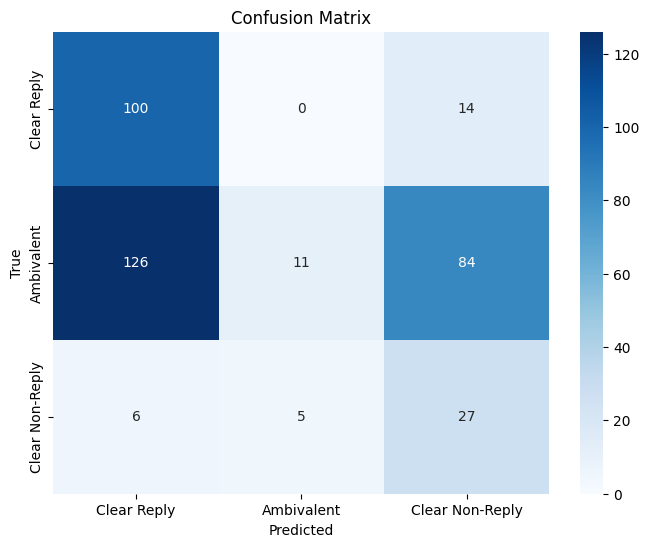

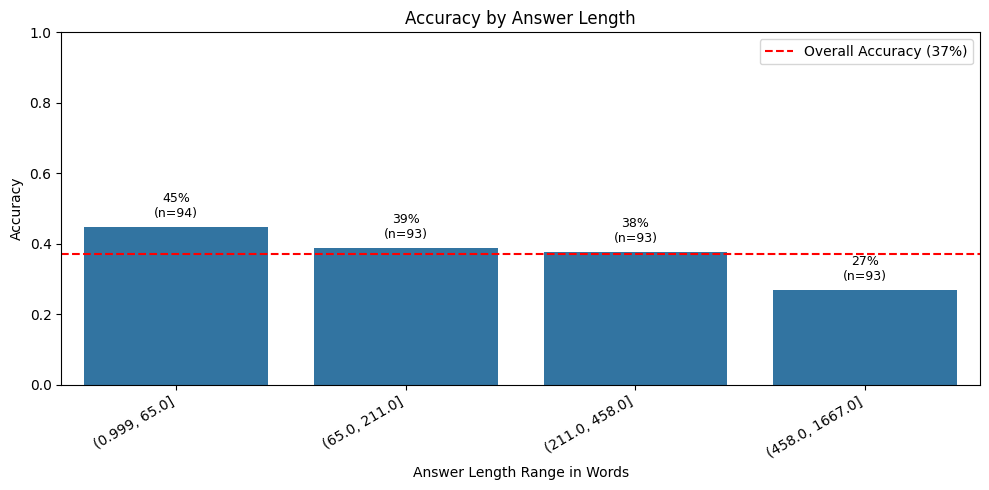

Total samples:     373
Errors:            235 (63.0%)
  - Wrong label:   235 (63.0%)
  - Invalid:       0 (0.0%)
Correct:           138 (37.0%)

Most common confusion patterns (true → predicted):
  Ambivalent           → Clear Reply          : 126
  Ambivalent           → Clear Non-Reply      : 84
  Clear Reply          → Clear Non-Reply      : 14
  Clear Non-Reply      → Clear Reply          : 6
  Clear Non-Reply      → Ambivalent           : 5



In [56]:
cleanup_gpu() 
system_prompt = """You are an expert classifier.
Given the interview question and the president's answer, classify the answer into exactly one of the following labels:
Labels:
- Clear Reply
- Ambivalent
- Clear Non-Reply

Output the label only."""
    
BATCH_SIZE = 2
all_predictions = []
all_raw_outputs = []

for i in tqdm(range(0, len(exp_df), BATCH_SIZE), desc="Zero-shot"):

    batch_df = exp_df.iloc[i : i + BATCH_SIZE]
    
    preds, raws = classify_batch(
        batch_df['question'].tolist(),
        batch_df['interview_answer'].tolist(),
        system_prompt,
        model,
        tokenizer
    )
   
    all_predictions.extend(preds)
    all_raw_outputs.extend(raws)

exp_df['predicted_label'] = all_predictions
exp_df['raw_model_output'] = all_raw_outputs


        

results_q4_zs_1 = evaluate_results(exp_df)
plot_error_by_length(exp_df)
error_summary(exp_df) 

## Few-Shot


#### Few shot Experiment


GPU free: 11.36 GB


kNN Few-shot:   0%|          | 0/373 [00:00<?, ?it/s]

FINAL EVALUATION REPORT
Total Samples: 373
Invalid Predictions: 0 (0.00%)
--------------------------------------------------
Accuracy:          0.4960
F1-Macro:          0.4792
F1-Weighted:       0.4900
Precision Macro:   0.5024
Recall Macro:      0.5678
--------------------------------------------------
Detailed Classification Report:
                 precision    recall  f1-score   support

    Clear Reply       0.43      0.75      0.55       114
     Ambivalent       0.76      0.34      0.47       221
Clear Non-Reply       0.32      0.61      0.42        38

       accuracy                           0.50       373
      macro avg       0.50      0.57      0.48       373
   weighted avg       0.61      0.50      0.49       373



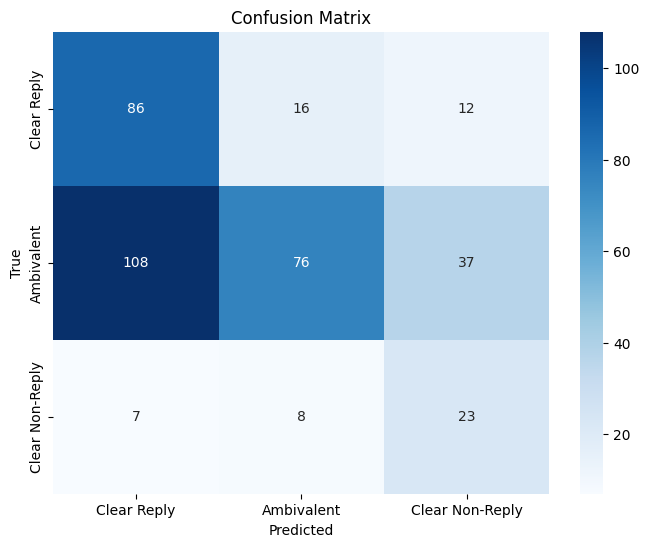

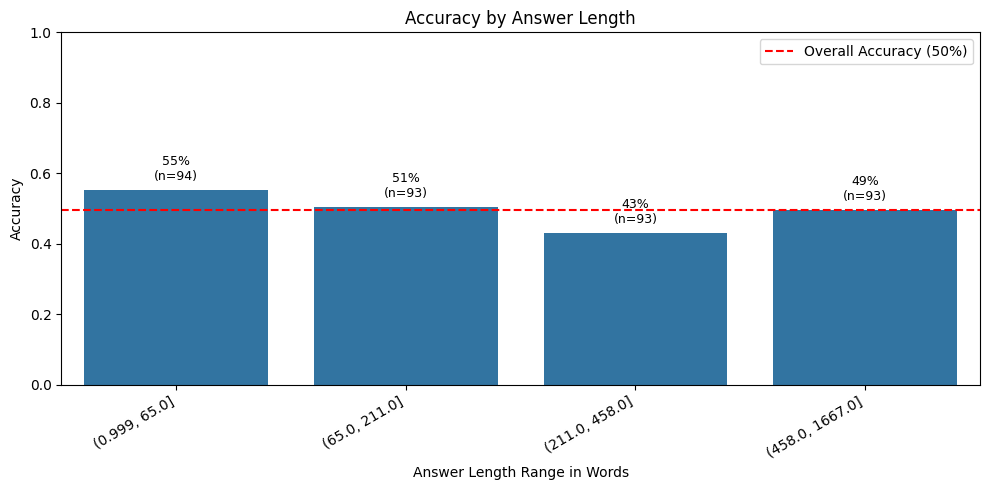

Total samples:     373
Errors:            188 (50.4%)
  - Wrong label:   188 (50.4%)
  - Invalid:       0 (0.0%)
Correct:           185 (49.6%)

Most common confusion patterns (true → predicted):
  Ambivalent           → Clear Reply          : 108
  Ambivalent           → Clear Non-Reply      : 37
  Clear Reply          → Ambivalent           : 16
  Clear Reply          → Clear Non-Reply      : 12
  Clear Non-Reply      → Ambivalent           : 8
  Clear Non-Reply      → Clear Reply          : 7



In [57]:

cleanup_gpu()
system_prompt = """You are an expert classifier.
Given the interview question and the president's answer, classify the answer into exactly one of the following labels:
Labels:
- Clear Reply
- Ambivalent
- Clear Non-Reply

Output the label only."""

K = 3
all_predictions, all_raw_outputs = [], []

for i in tqdm(range(len(exp_df)), desc="kNN Few-shot"):    
    row = exp_df.iloc[i]
    dyn = knn_examples(row['question'], row['interview_answer'], k=K, balanced=False)
    preds, raws = classify_batch_fewshot(
        [row['question']], [row['interview_answer']],
        system_prompt, model, tokenizer, fewshot_examples=dyn
    )
    all_predictions.extend(preds); all_raw_outputs.extend(raws)

exp_df['predicted_label']  = all_predictions
exp_df['raw_model_output'] = all_raw_outputs

results_q4_knn_fs3_No_bal = evaluate_results(exp_df)
plot_error_by_length(exp_df)
error_summary(exp_df)

## Chain of Thought

#### CoT Experiment
With the 4B model, Chain-of-Thought gives the best CoT scores within the Qwen family: accuracy 0.36, macro-F1 0.34, and weighted-F1 0.30, again with no invalid outputs. The larger model recognises Clear Reply much better than its smaller counterparts (F1 = 0.58, recall = 0.75), which accounts for most of the improvement. However, the same weakness remains: Ambivalent is almost ignored (recall 0.09, F1 = 0.15), and answers from this class are split between Clear Non-Reply (108 cases) and Clear Reply (94 cases). Overall, scaling the model up raises accuracy modestly and mainly benefits the Clear Reply class, but Chain-of-Thought continues to bias every Qwen model away from the majority Ambivalent class.

In [58]:

# cleanup_gpu() 
# system_prompt = """You are an expert classifier.
# Given a question and a president's answer, classify the answer into exactly one of the following labels:
# Labels:
# - Clear Reply
# - Ambivalent
# - Clear Non-Reply

# Output format:
# Reasoning: <2-4 sentences explaining how the answer relates to the specific sub-question>
# Label: <Clear Reply | Ambivalent | Clear Non-Reply>
# """



# BATCH_SIZE = 2
# all_predictions = []
# all_reasonings  = []
# all_raw_outputs = []

# for i in tqdm(range(0, len(exp_df), BATCH_SIZE), desc="CoT "):
#     batch_df = exp_df.iloc[i : i + BATCH_SIZE]

#     preds, reasonings, raws = classify_batch_cot(
#         batch_df['question'].tolist(),
#         batch_df['interview_answer'].tolist(),
#         system_prompt,
#         model,
#         tokenizer, max_new_tokens=300   )

#     all_predictions.extend(preds)
#     all_reasonings.extend(reasonings)
#     all_raw_outputs.extend(raws)

# exp_df['predicted_label'] = all_predictions
# exp_df['reasoning_cot']       = all_reasonings
# exp_df['raw_model_output'] = all_raw_outputs


# results_q4_cot_1 = evaluate_results(exp_df)
# plot_error_by_length(exp_df)
# error_summary(exp_df)

In [59]:
del model, tokenizer
cleanup_gpu()

GPU free: 15.54 GB


# Gemma3-4b

In [60]:
user_secrets = UserSecretsClient()
os.environ["HF_TOKEN"] = user_secrets.get_secret("HF_TOKEN")   

model_name = "google/gemma-3-4b-it"
processor = AutoProcessor.from_pretrained(model_name)
model = Gemma3ForConditionalGeneration.from_pretrained(
    model_name,
    torch_dtype=torch.bfloat16,
    device_map="auto"
).eval()

tokenizer = processor.tokenizer
n_params = sum(p.numel() for p in model.parameters())
print(processor.tokenizer.chat_template is not None)
print(f"Model name: {model_name}")
print(f"Total parameters: {n_params:,} ({n_params/1e9:.2f}B)")


processor_config.json:   0%|          | 0.00/70.0 [00:00<?, ?B/s]

chat_template.json:   0%|          | 0.00/1.61k [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/855 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/1.16M [00:00<?, ?B/s]

...

model.safetensors.index.json:   0%|          | 0.00/90.6k [00:00<?, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/883 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/215 [00:00<?, ?B/s]

True
Model name: google/gemma-3-4b-it
Total parameters: 4,300,079,472 (4.30B)


#### Examples

The manual generation pipeline is run on a single example to verify that Gemma 3 4B respects the label-only output format.
The same example is passed through classify_batch to confirm that the helper works with the Gemma processor/tokenizer.


In [61]:
system_prompt = """You are an expert classifier.
Given the interview question and the president's answer, classify the answer into exactly one of the following labels:
Labels:
- Clear Reply
- Ambivalent
- Clear Non-Reply

Output the label only."""

example = exp_df.iloc[1]

user_content = f"Question: {example['question']}\nAnswer: {example['interview_answer']}"

messages = [
    {"role": "system", "content": system_prompt},
    {"role": "user", "content": user_content},
]

prompt = tokenizer.apply_chat_template(
    messages, tokenize=False, add_generation_prompt=True
)
print(prompt)  

<bos><start_of_turn>user
You are an expert classifier.
Given the interview question and the president's answer, classify the answer into exactly one of the following labels:
Labels:
- Clear Reply
- Ambivalent
- Clear Non-Reply

Output the label only.

Question: Will the United States recognize it?
Answer: I suggest you study the Ahtisaari plan. Not to be, like, the, you know, grumpy guy. Well, how to get— how do we get more peacekeepers into Darfur? Of course, what has been delaying getting more peacekeepers has been the lack of understanding between the U.N. and the Government of Sudan on the status of forces agreement. Now that one has been signed, I think it has cleared the way. There are many volunteers, and as Chair of the African Union, we certainly seek out more and more volunteers as they are needed. We use our good offices to see more and more African countries contribute. We have volunteered to contribute one battalion. If there is need for another one, we will certainly do t

In [62]:
def _parse_label(resp, labels=("Clear Reply", "Ambivalent", "Clear Non-Reply")):
    if "</think>" in resp:
        resp = resp.split("</think>")[-1]
    resp = resp.strip()
    
    for label in sorted(labels, key=len, reverse=True):
        if label.lower() in resp.lower():
            return label
    return "Invalid"
    



inputs = tokenizer(
    prompt,
    return_tensors="pt"
).to(model.device)

input_length = inputs["input_ids"].shape[-1]

with torch.no_grad():
    outputs = model.generate(
        **inputs,
        max_new_tokens=10,
        do_sample=False,
        pad_token_id=tokenizer.pad_token_id
    )

full_output = tokenizer.decode(outputs[0], skip_special_tokens=False)

generated_only = tokenizer.decode(
    outputs[0][input_length:],
    skip_special_tokens=False
).strip()

print("\n===== FULL OUTPUT: PROMPT + MODEL RESPONSE =====")
print(full_output)

print("\n===== ONLY MODEL RESPONSE =====")
print(repr(generated_only))

print("\n===== PARSED LABEL =====")
print(_parse_label(generated_only))


===== FULL OUTPUT: PROMPT + MODEL RESPONSE =====
<bos><bos><start_of_turn>user
You are an expert classifier.
Given the interview question and the president's answer, classify the answer into exactly one of the following labels:
Labels:
- Clear Reply
- Ambivalent
- Clear Non-Reply

Output the label only.

Question: Will the United States recognize it?
Answer: I suggest you study the Ahtisaari plan. Not to be, like, the, you know, grumpy guy. Well, how to get— how do we get more peacekeepers into Darfur? Of course, what has been delaying getting more peacekeepers has been the lack of understanding between the U.N. and the Government of Sudan on the status of forces agreement. Now that one has been signed, I think it has cleared the way. There are many volunteers, and as Chair of the African Union, we certainly seek out more and more volunteers as they are needed. We use our good offices to see more and more African countries contribute. We have volunteered to contribute one battalion. I

In [63]:
system_prompt = """You are an expert classifier.
Given the interview question and the president's answer, classify the answer into exactly one of the following labels:
Labels:
- Clear Reply
- Ambivalent
- Clear Non-Reply

Output the label only."""
example = exp_df.iloc[1]
preds, raws = classify_batch(
    [example['question']], [example['interview_answer']],
    system_prompt, model, tokenizer, max_new_tokens=10
)
print(f"Question: {example['question']}")
print(f"Answer: {example['interview_answer'][:200]}...")
print(f"Gold label: {example['clarity_label']}")
print(f"Raw model output: {repr(raws[0])}")
print(f"Parsed: {preds[0]}")

Question: Will the United States recognize it?
Answer: I suggest you study the Ahtisaari plan. Not to be, like, the, you know, grumpy guy. Well, how to get— how do we get more peacekeepers into Darfur? Of course, what has been delaying getting more peacek...
Gold label: Clear Non-Reply
Raw model output: 'Ambivalent'
Parsed: Ambivalent


## Zero-shot


### Zero shot Experiments


GPU free: 11.28 GB


Zero-shot:   0%|          | 0/187 [00:00<?, ?it/s]

FINAL EVALUATION REPORT
Total Samples: 373
Invalid Predictions: 0 (0.00%)
--------------------------------------------------
Accuracy:          0.5389
F1-Macro:          0.4169
F1-Weighted:       0.5271
Precision Macro:   0.4322
Recall Macro:      0.4105
--------------------------------------------------
Detailed Classification Report:
                 precision    recall  f1-score   support

    Clear Reply       0.44      0.39      0.41       114
     Ambivalent       0.61      0.68      0.64       221
Clear Non-Reply       0.25      0.16      0.19        38

       accuracy                           0.54       373
      macro avg       0.43      0.41      0.42       373
   weighted avg       0.52      0.54      0.53       373



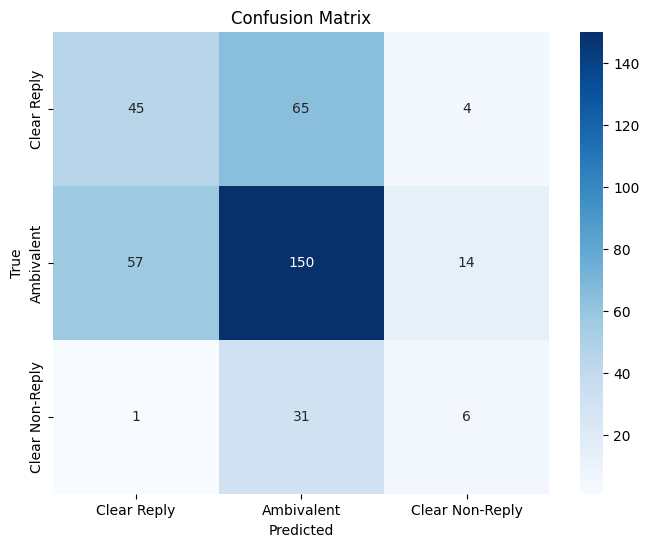

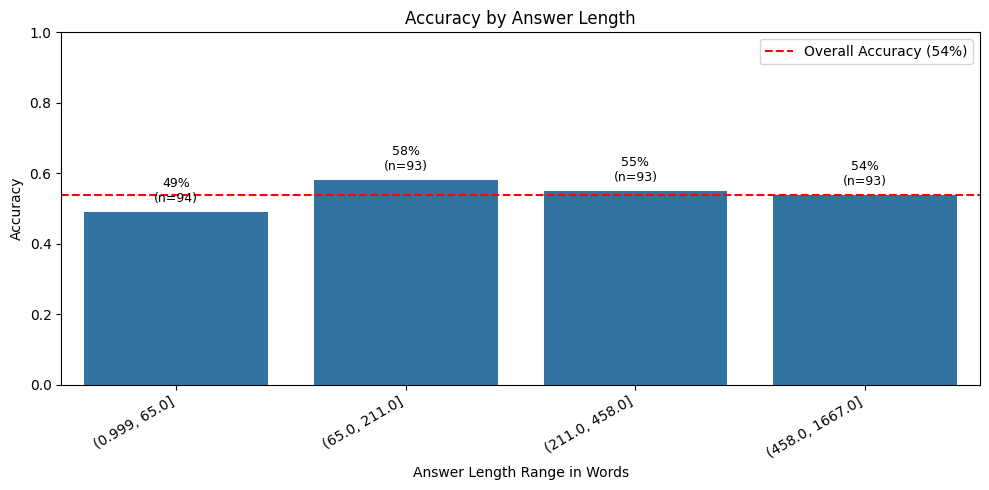

Total samples:     373
Errors:            172 (46.1%)
  - Wrong label:   172 (46.1%)
  - Invalid:       0 (0.0%)
Correct:           201 (53.9%)

Most common confusion patterns (true → predicted):
  Clear Reply          → Ambivalent           : 65
  Ambivalent           → Clear Reply          : 57
  Clear Non-Reply      → Ambivalent           : 31
  Ambivalent           → Clear Non-Reply      : 14
  Clear Reply          → Clear Non-Reply      : 4
  Clear Non-Reply      → Clear Reply          : 1



In [64]:
cleanup_gpu() 
system_prompt = """You are an expert classifier.
Given the interview question and the president's answer, classify the answer into exactly one of the following labels:
Labels:
- Clear Reply
- Ambivalent
- Clear Non-Reply

Output the label only."""
BATCH_SIZE = 2
all_predictions = []
all_raw_outputs = []

for i in tqdm(range(0, len(exp_df), BATCH_SIZE), desc="Zero-shot"):
    batch_df = exp_df.iloc[i : i + BATCH_SIZE]
    
    
    preds, raws = classify_batch(
        batch_df['question'].tolist(),
        batch_df['interview_answer'].tolist(),
        system_prompt,
        model,
        tokenizer
    )
   
    
    all_predictions.extend(preds)
    all_raw_outputs.extend(raws)

exp_df['predicted_label'] = all_predictions
exp_df['raw_model_output'] = all_raw_outputs


        

results_gem4_zs = evaluate_results(exp_df)
plot_error_by_length(exp_df)
error_summary(exp_df) 

## Few- shot

#### Few shot Experiment
Adding kNN-retrieved few-shot demonstrations (K = 3, unbalanced) actually lowered accuracy to 0.43, even though the macro-F1 (0.42) stayed close to the zero-shot value and almost all outputs were valid (1 invalid, 0.27%). The examples pushed the model away from the dominant class: Ambivalent recall collapsed to 0.32 (F1 = 0.45) despite a high precision of 0.76, while the minority classes were over-predicted, especially Clear Non-Reply (recall 0.61 but precision only 0.16). The leading confusions are Ambivalent answers reassigned to Clear Non-Reply (84 cases) and to Clear Reply (65 cases). So for Gemma 4B, few-shot trades a more balanced recall profile for a clear drop in overall accuracy and performs worse than its own zero-shot baseline.

In [65]:

# cleanup_gpu()
# system_prompt = """You are an expert classifier.
# Given the interview question and the president's answer, classify the answer into exactly one of the following labels:
# Labels:
# - Clear Reply
# - Ambivalent
# - Clear Non-Reply

# Output the label only."""

# K = 3
# all_predictions, all_raw_outputs = [], []

# for i in tqdm(range(len(exp_df)), desc="kNN Few-shot"):    
#     row = exp_df.iloc[i]
#     dyn = knn_examples(row['question'], row['interview_answer'], k=K, balanced=False)
#     preds, raws = classify_batch_fewshot(
#         [row['question']], [row['interview_answer']],
#         system_prompt, model, tokenizer, fewshot_examples=dyn
#     )
#     all_predictions.extend(preds); all_raw_outputs.extend(raws)

# exp_df['predicted_label']  = all_predictions
# exp_df['raw_model_output'] = all_raw_outputs

# results_gem4_fs = evaluate_results(exp_df)
# plot_error_by_length(exp_df)
# error_summary(exp_df) 

In [66]:
del model, tokenizer
cleanup_gpu()

GPU free: 15.54 GB


# Gemma3-1b

In [67]:
from kaggle_secrets import UserSecretsClient
import os
os.environ["HF_TOKEN"] = UserSecretsClient().get_secret("HF_TOKEN")   # ΠΡΩΤΑ το token

model_name = "google/gemma-3-1b-it"

tokenizer = AutoTokenizer.from_pretrained(model_name)

model = AutoModelForCausalLM.from_pretrained(
    model_name,
    torch_dtype=torch.bfloat16,
    device_map="auto"
)


user_secrets = UserSecretsClient()

n_params = sum(p.numel() for p in model.parameters())
print(f"Model name: {model_name}")
print(f"Total parameters: {n_params:,} ({n_params/1e9:.2f}B)")


config.json:   0%|          | 0.00/899 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/1.16M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/33.4M [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/35.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/662 [00:00<?, ?B/s]

[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors:   0%|          | 0.00/2.00G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/340 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/215 [00:00<?, ?B/s]

Model name: google/gemma-3-1b-it
Total parameters: 999,885,952 (1.00B)


#### Example

The manual generation pipeline is run on a single example to verify that Gemma 3 1B produces a short, parseable label-only output before the full experiments. 

In [68]:
system_prompt = """You are an expert classifier.
Given the interview question and the president's answer, classify the answer into exactly one of the following labels:
Labels:
- Clear Reply
- Ambivalent
- Clear Non-Reply

Output the label only."""

example = exp_df.iloc[1]

user_content = f"Question: {example['question']}\nAnswer: {example['interview_answer']}"

messages = [
    {"role": "system", "content": system_prompt},
    {"role": "user", "content": user_content},
]
prompt = tokenizer.apply_chat_template( messages, tokenize=False,  add_generation_prompt=True , enable_thinking= False )

print(prompt)  

<bos><start_of_turn>user
You are an expert classifier.
Given the interview question and the president's answer, classify the answer into exactly one of the following labels:
Labels:
- Clear Reply
- Ambivalent
- Clear Non-Reply

Output the label only.

Question: Will the United States recognize it?
Answer: I suggest you study the Ahtisaari plan. Not to be, like, the, you know, grumpy guy. Well, how to get— how do we get more peacekeepers into Darfur? Of course, what has been delaying getting more peacekeepers has been the lack of understanding between the U.N. and the Government of Sudan on the status of forces agreement. Now that one has been signed, I think it has cleared the way. There are many volunteers, and as Chair of the African Union, we certainly seek out more and more volunteers as they are needed. We use our good offices to see more and more African countries contribute. We have volunteered to contribute one battalion. If there is need for another one, we will certainly do t

In [69]:
def _parse_label(resp, labels=("Clear Reply", "Ambivalent", "Clear Non-Reply")):
    if "</think>" in resp:
        resp = resp.split("</think>")[-1]
    resp = resp.strip()
    
    for label in sorted(labels, key=len, reverse=True):
        if label.lower() in resp.lower():
            return label
    return "Invalid"


inputs = tokenizer(
    prompt,
    return_tensors="pt"
).to(model.device)

input_length = inputs["input_ids"].shape[-1]

with torch.no_grad():
    outputs = model.generate(
        **inputs,
        max_new_tokens=10,
        do_sample=False,
        pad_token_id=tokenizer.pad_token_id
    )

full_output = tokenizer.decode(outputs[0], skip_special_tokens=False)

generated_only = tokenizer.decode(
    outputs[0][input_length:],
    skip_special_tokens=False
).strip()

print("\n===== FULL OUTPUT: PROMPT + MODEL RESPONSE =====")
print(full_output)

print("\n===== ONLY MODEL RESPONSE =====")
print(repr(generated_only))

print("\n===== PARSED LABEL =====")
print(_parse_label(generated_only))


===== FULL OUTPUT: PROMPT + MODEL RESPONSE =====
<bos><bos><start_of_turn>user
You are an expert classifier.
Given the interview question and the president's answer, classify the answer into exactly one of the following labels:
Labels:
- Clear Reply
- Ambivalent
- Clear Non-Reply

Output the label only.

Question: Will the United States recognize it?
Answer: I suggest you study the Ahtisaari plan. Not to be, like, the, you know, grumpy guy. Well, how to get— how do we get more peacekeepers into Darfur? Of course, what has been delaying getting more peacekeepers has been the lack of understanding between the U.N. and the Government of Sudan on the status of forces agreement. Now that one has been signed, I think it has cleared the way. There are many volunteers, and as Chair of the African Union, we certainly seek out more and more volunteers as they are needed. We use our good offices to see more and more African countries contribute. We have volunteered to contribute one battalion. I

# Zero- Shot


### Zero shot Experiments


GPU free: 14.56 GB


Zero-shot:   0%|          | 0/94 [00:00<?, ?it/s]

FINAL EVALUATION REPORT
Total Samples: 373
Invalid Predictions: 0 (0.00%)
--------------------------------------------------
Accuracy:          0.2895
F1-Macro:          0.2636
F1-Weighted:       0.1758
Precision Macro:   0.1870
Recall Macro:      0.5088
--------------------------------------------------
Detailed Classification Report:
                 precision    recall  f1-score   support

    Clear Reply       0.36      0.66      0.47       114
     Ambivalent       0.00      0.00      0.00       221
Clear Non-Reply       0.20      0.87      0.32        38

       accuracy                           0.29       373
      macro avg       0.19      0.51      0.26       373
   weighted avg       0.13      0.29      0.18       373



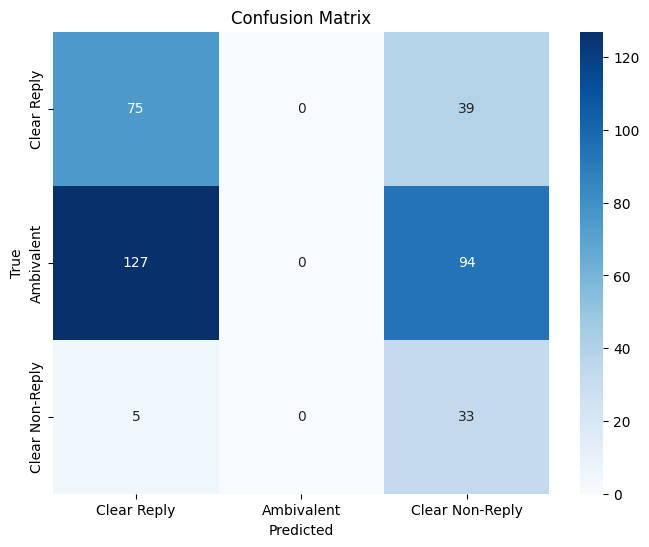

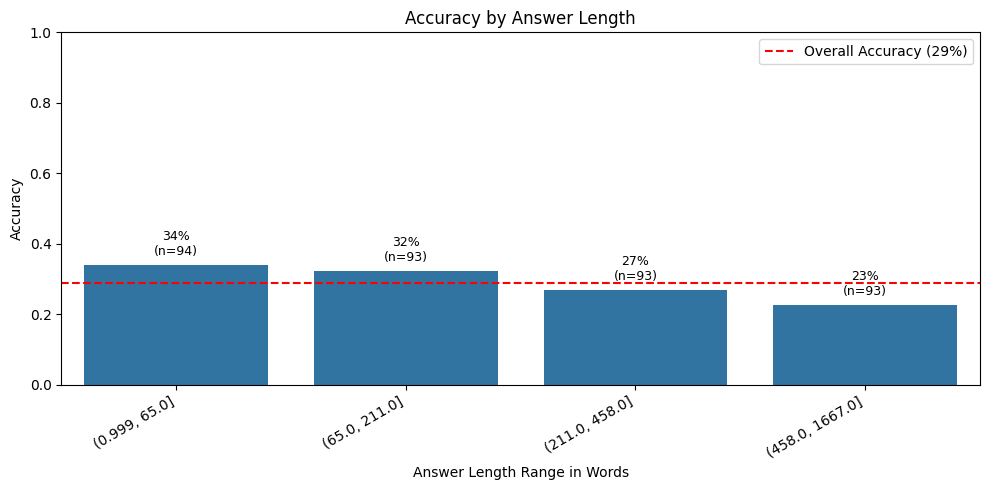

Total samples:     373
Errors:            265 (71.0%)
  - Wrong label:   265 (71.0%)
  - Invalid:       0 (0.0%)
Correct:           108 (29.0%)

Most common confusion patterns (true → predicted):
  Ambivalent           → Clear Reply          : 127
  Ambivalent           → Clear Non-Reply      : 94
  Clear Reply          → Clear Non-Reply      : 39
  Clear Non-Reply      → Clear Reply          : 5



In [70]:
cleanup_gpu() 

system_prompt = """You are an expert classifier.
Given the interview question and the president's answer, classify the answer into exactly one of the following labels:
Labels:
- Clear Reply
- Ambivalent
- Clear Non-Reply

Output the label only."""
    
BATCH_SIZE = 4
all_predictions = []
all_raw_outputs = []

for i in tqdm(range(0, len(exp_df), BATCH_SIZE), desc="Zero-shot"):

    batch_df = exp_df.iloc[i : i + BATCH_SIZE]
    
    preds, raws = classify_batch(
         batch_df['question'].tolist(),
        batch_df['interview_answer'].tolist(),
        system_prompt,
        model,
        tokenizer
    )
    
    all_predictions.extend(preds)
    all_raw_outputs.extend(raws)

exp_df['predicted_label'] = all_predictions
exp_df['raw_model_output'] = all_raw_outputs


        

results_gem1_zs = evaluate_results(exp_df)
plot_error_by_length(exp_df)
error_summary(exp_df) 

# Few-Shot


#### Few shot Experiment
Few-shot prompting transforms the 1B model: with kNN-retrieved examples (K = 3, unbalanced), accuracy jumps to 0.53, macro-F1 to 0.47, and weighted-F1 to 0.53, with only 2 invalid outputs (0.54%). The demonstrations restore the majority class that zero-shot had lost entirely — Ambivalent recovers to an F1 of 0.64 (recall 0.62) — and even the minority Clear Non-Reply class reaches a respectable F1 of 0.41. Clear Reply remains the hardest class (F1 = 0.37), and the main confusions are again between Clear Reply and Ambivalent in both directions (67 and 59 cases). This is by far the largest few-shot gain of any model (about +0.24 accuracy over its own zero-shot run) and shows that in-context examples are essential for the smallest model to use the label set at all.

In [71]:

# cleanup_gpu()
# system_prompt = """You are an expert classifier.
# Given the interview question and the president's answer, classify the answer into exactly one of the following labels:
# Labels:
# - Clear Reply
# - Ambivalent
# - Clear Non-Reply

# Output the label only."""

# K = 3
# all_predictions, all_raw_outputs = [], []

# for i in tqdm(range(len(exp_df)), desc="kNN Few-shot"):    
#     row = exp_df.iloc[i]
#     dyn = knn_examples(row['question'], row['interview_answer'], k=K, balanced=False)
#     preds, raws = classify_batch_fewshot(
#         [row['question']], [row['interview_answer']],
#         system_prompt, model, tokenizer, fewshot_examples=dyn
#     )
#     all_predictions.extend(preds); all_raw_outputs.extend(raws)

# exp_df['predicted_label']  = all_predictions
# exp_df['raw_model_output'] = all_raw_outputs

# results_gem1_fs = evaluate_results(exp_df)
# plot_error_by_length(exp_df)
# error_summary(exp_df) 

# Experiment Comparison


### Qwen 0.8B Experiment Comparison

This section focuses only on the experiments conducted with the Qwen 0.8B model. The purpose of this comparison is to evaluate how different prompting strategies affect the performance of the same model, without introducing the additional variable of model size.

Several prompting setups were tested, including zero-shot prompting, few-shot prompting with different example selections, and Chain-of-Thought prompting. Since the underlying model remains the same in all these experiments, any differences in performance can be mainly attributed to the prompt design, the use of examples, or the decoding configuration.

The comparison is based on accuracy, macro F1-score, weighted F1-score, precision, recall, and the number of invalid predictions. Macro F1 is especially important in this task because it gives equal importance to all three classes: Clear Reply, Ambivalent, and Clear Non-Reply. The number of invalid predictions is also considered, since it indicates whether the model follows the required output format consistently.

This comparison helps identify which prompting strategy works best for the smaller Qwen 0.8B model. It also provides a clearer baseline before comparing the 0.8B model with larger model versions in the overall experiment comparison.

In [72]:
experiment_results_q08 = [
    {"experiment": "Qwen 0.8B Zero-shot (baseline)",          "method": "Zero-shot", "results": results_q08_zs_1},
    {"experiment": "Qwen 0.8B Zero-shot (simplified prompt)",   "method": "Zero-shot", "results": results_q08_zs_2},
    {"experiment": "Qwen 0.8B Zero-shot (detailed prompt)",   "method": "Zero-shot", "results": results_q08_zs_3},
    {"experiment": "Qwen 0.8B Zero-shot (only user message)",   "method": "Zero-shot", "results": results_q08_zs_4},
    {"experiment": "Qwen 0.8B Few-shot random",               "method": "Few-shot",  "results": results_q08_fs_1},
    {"experiment": "Qwen 0.8B Few-shot kNN (K=3, balanced)",  "method": "Few-shot",  "results": results_q08_knn_fs3_bal},
    {"experiment": "Qwen 0.8B Few-shot kNN (K=3, unbalanced)","method": "Few-shot",  "results": results_q08_knn_fs_Non_bal},
    # {"experiment": "Qwen 0.8B Few-shot kNN (K=6, balanced)",  "method": "Few-shot",  "results": results_q08_knn_fs6_bal},
    {"experiment": "Qwen 0.8B CoT",                           "method": "CoT",       "results": results_q08_cot_1},
    # {"experiment": "Qwen 0.8B CoT + FS",                      "method": "CoT",       "results": results_q08_fscot},
    # {"experiment": "Qwen 0.8B Self-Consistency",              "method": "SC",        "results": results_q08_sc},
]

summary_rows_q08 = []

for exp in experiment_results_q08:
    r = exp["results"]

    summary_rows_q08.append({
        "Experiment": exp["experiment"],
        "Accuracy": r["accuracy"],
        "F1-Macro": r["f1_macro"],
        "F1-Weighted": r["f1_weighted"],
        "Precision Macro": r["precision_macro"],
        "Recall Macro": r["recall_macro"]
    })

results_summary_df_q08 = pd.DataFrame(summary_rows_q08)

results_summary_df_q08

,Experiment,Accuracy,F1-Macro,F1-Weighted,Precision Macro,Recall Macro
0,Qwen 0.8B Zero-shot (baseline),0.514745,0.447374,0.519898,0.445887,0.455849
1,Qwen 0.8B Zero-shot (simplified prompt),0.356568,0.313670,0.321197,0.355251,0.393573
2,Qwen 0.8B Zero-shot (detailed prompt),0.305630,0.265669,0.220553,0.328425,0.405480
3,Qwen 0.8B Zero-shot (only user message),0.388740,0.300235,0.372318,0.321886,0.342238
4,Qwen 0.8B Few-shot random,0.563003,0.273821,0.458951,0.398830,0.325236
5,"Qwen 0.8B Few-shot kNN (K=3, balanced)",0.536193,0.381519,0.512955,0.400479,0.387897
6,"Qwen 0.8B Few-shot kNN (K=3, unbalanced)",0.581769,0.415574,0.537996,0.503555,0.407690
7,Qwen 0.8B CoT,0.319035,0.289721,0.223210,0.354504,0.463867


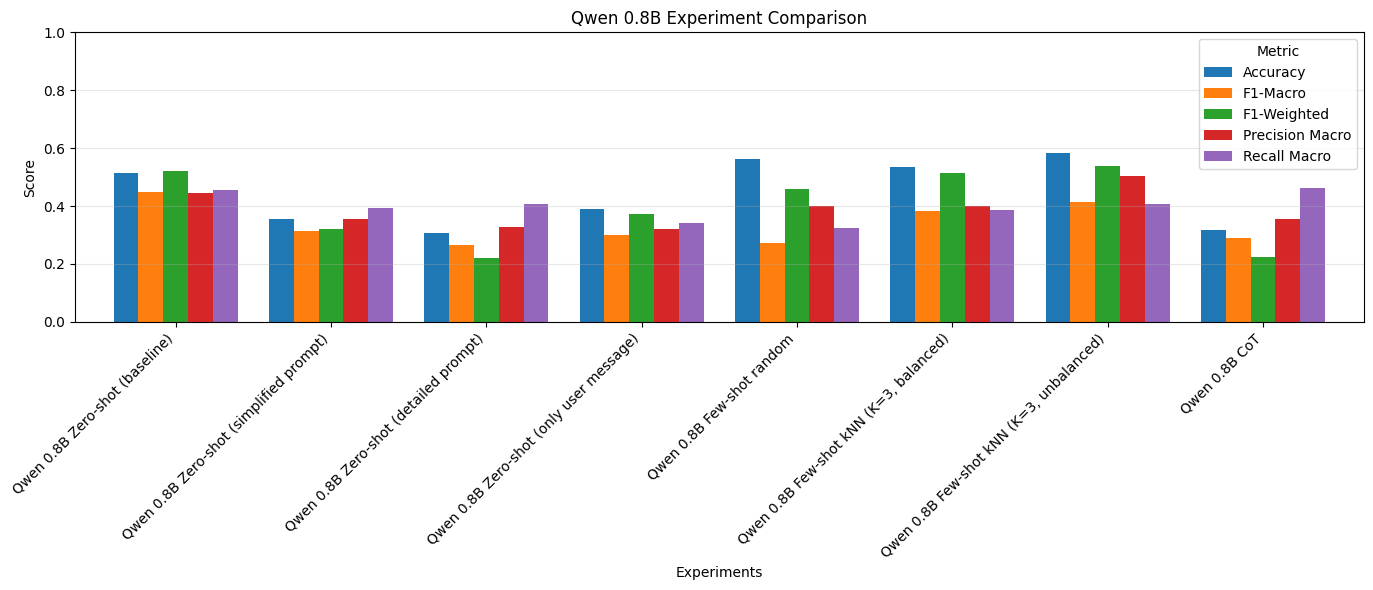

In [73]:
metrics_to_plot = [
    "Accuracy",
    "F1-Macro",
    "F1-Weighted",
    "Precision Macro",
    "Recall Macro"
]

plot_df = results_summary_df_q08.set_index("Experiment")[metrics_to_plot]

ax = plot_df.plot(
    kind="bar",
    figsize=(14, 6),
    width=0.8
)

plt.title("Qwen 0.8B Experiment Comparison")
plt.ylabel("Score")
plt.xlabel("Experiments")
plt.ylim(0, 1)
plt.xticks(rotation=45, ha="right")
plt.legend(title="Metric")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

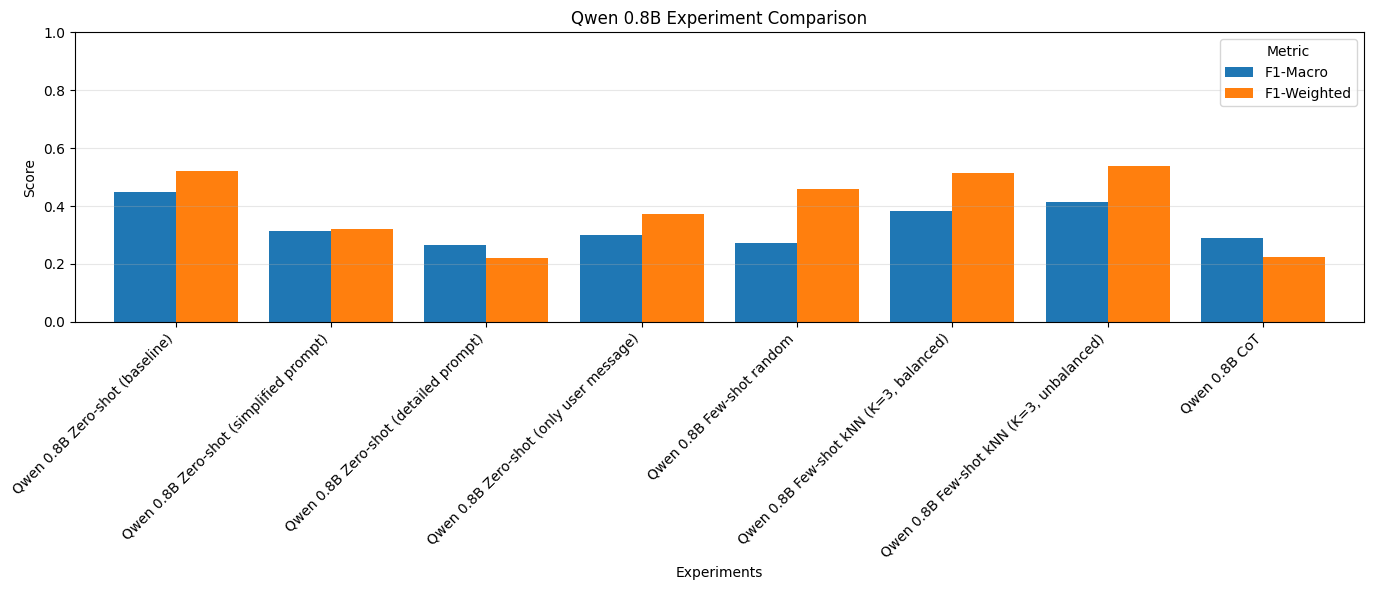

In [74]:
metrics_to_plot = [
    "F1-Macro",
    "F1-Weighted",

]

plot_df = results_summary_df_q08.set_index("Experiment")[metrics_to_plot]

ax = plot_df.plot(
    kind="bar",
    figsize=(14, 6),
    width=0.8
)

plt.title("Qwen 0.8B Experiment Comparison")
plt.ylabel("Score")
plt.xlabel("Experiments")
plt.ylim(0, 1)
plt.xticks(rotation=45, ha="right")
plt.legend(title="Metric")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

### Overall Experiment Comparison

For the final comparison, two representative experiments were selected: one zero-shot experiment and one few-shot experiment. This choice was made mainly due to time limitations and computational constraints, since the larger models were more difficult to run consistently.

Using one representative experiment from each prompting strategy allows for a fairer comparison across models, instead of comparing all variations tested only on the Qwen 0.8B model. The comparison is based on accuracy, macro F1-score, weighted F1-score, precision, recall, and the number of invalid predictions.

Overall, this comparison helps evaluate how model size and prompting strategy affect performance, while keeping the experimental setup manageable and more consistent across the tested models.

In [75]:
experiment_results = [
    {"experiment": "Qwen 0.8B Zero-shot",         "method": "Zero-shot", "results": results_q08_zs_1},
    {"experiment": "Qwen 0.8B Few-shot","method": "Few-shot",  "results": results_q08_knn_fs3_bal},
    # {"experiment": "Qwen 0.8B CoT",               "method": "CoT",       "results": results_q08_cot_1},
    {"experiment": "Qwen 2B Zero-shot",           "method": "Zero-shot", "results": results_q2_zs_1},
    {"experiment": "Qwen 2B Few-shot",  "method": "Few-shot",  "results": results_q2_knn_fs3_No_bal},
    # {"experiment": "Qwen 2B CoT",                 "method": "CoT",       "results": results_q2_cot_1},
    {"experiment": "Qwen 4B Zero-shot",           "method": "Zero-shot", "results": results_q4_zs_1},
    {"experiment": "Qwen 4B Few-shot",  "method": "Few-shot",  "results": results_q4_knn_fs3_No_bal},
    # {"experiment": "Qwen 4B CoT",                 "method": "CoT",       "results": results_q4_cot_1},
    {"experiment": "Gemma 1B Zero-shot",          "method": "Zero-shot", "results": results_gem1_zs},
    # {"experiment": "Gemma 1B Few-shot",           "method": "Few-shot",  "results": results_gem1_fs},
    {"experiment": "Gemma 4B Zero-shot", "method": "Zero-shot", "results": results_gem4_zs},
    # {"experiment": "Gemma 4B Few-shot",  "method": "Few-shot",  "results": results_gem4_fs},
   
]
summary_rows = []

for exp in experiment_results:
    r = exp["results"]

    summary_rows.append({
        "Experiment": exp["experiment"],
        "Accuracy": r["accuracy"],
        "F1-Macro": r["f1_macro"],
        "F1-Weighted": r["f1_weighted"],
        "Precision Macro": r["precision_macro"],
        "Recall Macro": r["recall_macro"]
    })

results_summary_df = pd.DataFrame(summary_rows)

results_summary_df

,Experiment,Accuracy,F1-Macro,F1-Weighted,Precision Macro,Recall Macro
0,Qwen 0.8B Zero-shot,0.514745,0.447374,0.519898,0.445887,0.455849
1,Qwen 0.8B Few-shot,0.536193,0.381519,0.512955,0.400479,0.387897
2,Qwen 2B Zero-shot,0.337802,0.306213,0.193440,0.265395,0.456140
3,Qwen 2B Few-shot,0.469169,0.470245,0.446269,0.525237,0.536450
4,Qwen 4B Zero-shot,0.369973,0.334050,0.265415,0.444845,0.545831
5,Qwen 4B Few-shot,0.495979,0.479245,0.490044,0.502435,0.567847
6,Gemma 1B Zero-shot,0.289544,0.263606,0.175778,0.187038,0.508772
7,Gemma 4B Zero-shot,0.538874,0.416898,0.527094,0.432216,0.410455


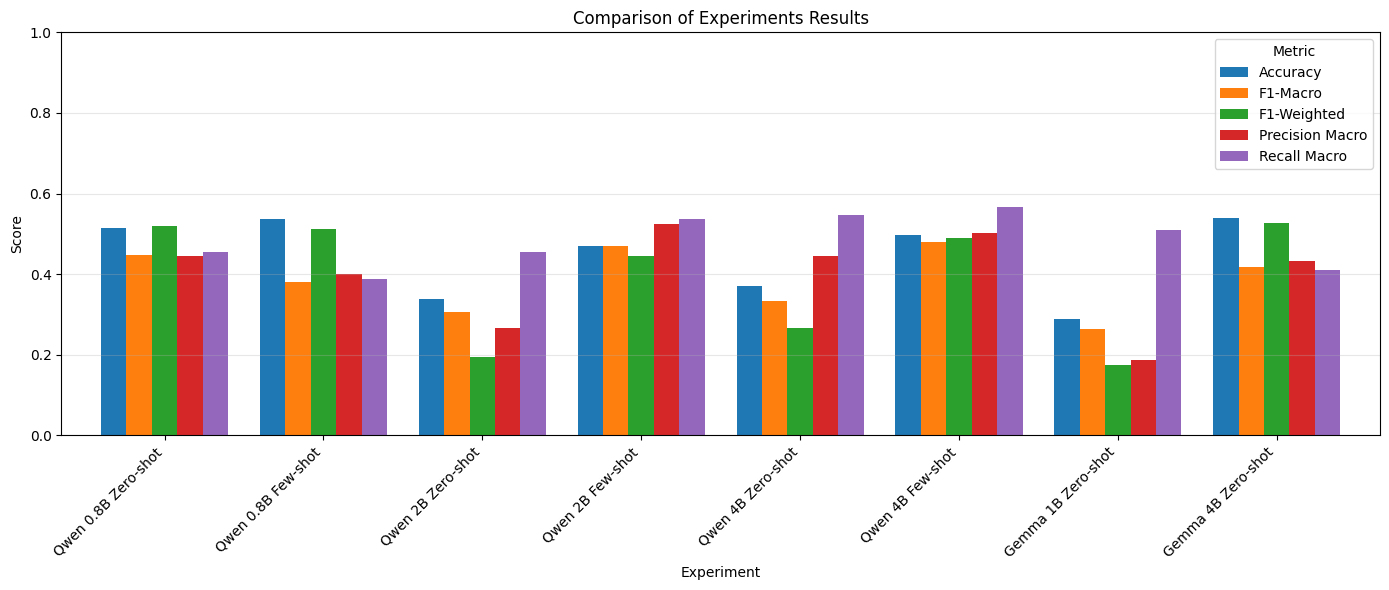

In [76]:
metrics_to_plot = [
    "Accuracy",
    "F1-Macro",
    "F1-Weighted",
    "Precision Macro",
    "Recall Macro"
]

plot_df = results_summary_df.set_index("Experiment")[metrics_to_plot]

ax = plot_df.plot(
    kind="bar",
    figsize=(14, 6),
    width=0.8
)

plt.title("Comparison of Experiments Results")
plt.ylabel("Score")
plt.xlabel("Experiment")
plt.ylim(0, 1)
plt.xticks(rotation=45, ha="right")
plt.legend(title="Metric")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

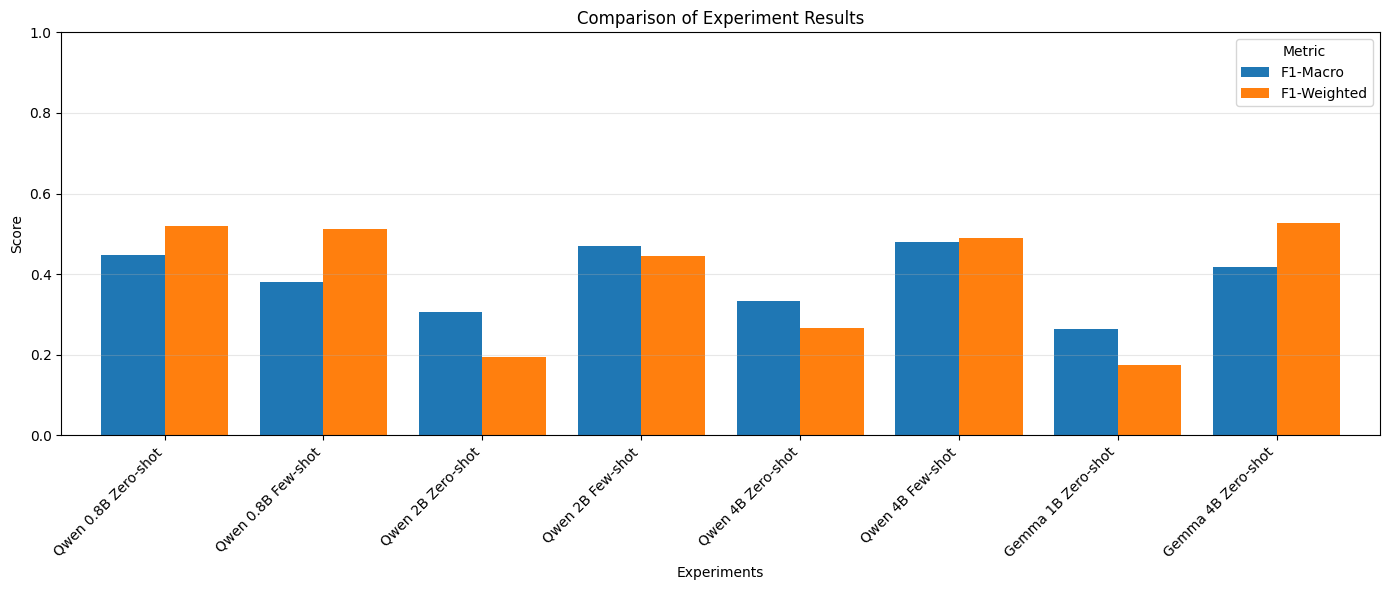

In [77]:
metrics_to_plot = [
    "F1-Macro",
    "F1-Weighted",

]

plot_df = results_summary_df.set_index("Experiment")[metrics_to_plot]

ax = plot_df.plot(
    kind="bar",
    figsize=(14, 6),
    width=0.8
)

plt.title("Comparison of Experiment Results")
plt.ylabel("Score")
plt.xlabel("Experiments")
plt.ylim(0, 1)
plt.xticks(rotation=45, ha="right")
plt.legend(title="Metric")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

In [78]:
experiment_results_zs = [
    {"experiment": "Qwen 0.8B Zero-shot",         "method": "Zero-shot", "results": results_q08_zs_1},
    {"experiment": "Qwen 2B Zero-shot",           "method": "Zero-shot", "results": results_q2_zs_1},
    {"experiment": "Qwen 4B Zero-shot",           "method": "Zero-shot", "results": results_q4_zs_1},

   
]

summary_rows_ZS = []

for exp in experiment_results_zs:
    r = exp["results"]

    summary_rows_ZS.append({
        "Experiment": exp["experiment"],
        "Accuracy": r["accuracy"],
        "F1-Macro": r["f1_macro"],
        "F1-Weighted": r["f1_weighted"],
        "Precision Macro": r["precision_macro"],
        "Recall Macro": r["recall_macro"]
    })

results_summary_df_ZS = pd.DataFrame(summary_rows_ZS)

results_summary_df_ZS



,Experiment,Accuracy,F1-Macro,F1-Weighted,Precision Macro,Recall Macro
0,Qwen 0.8B Zero-shot,0.514745,0.447374,0.519898,0.445887,0.455849
1,Qwen 2B Zero-shot,0.337802,0.306213,0.193440,0.265395,0.456140
2,Qwen 4B Zero-shot,0.369973,0.334050,0.265415,0.444845,0.545831


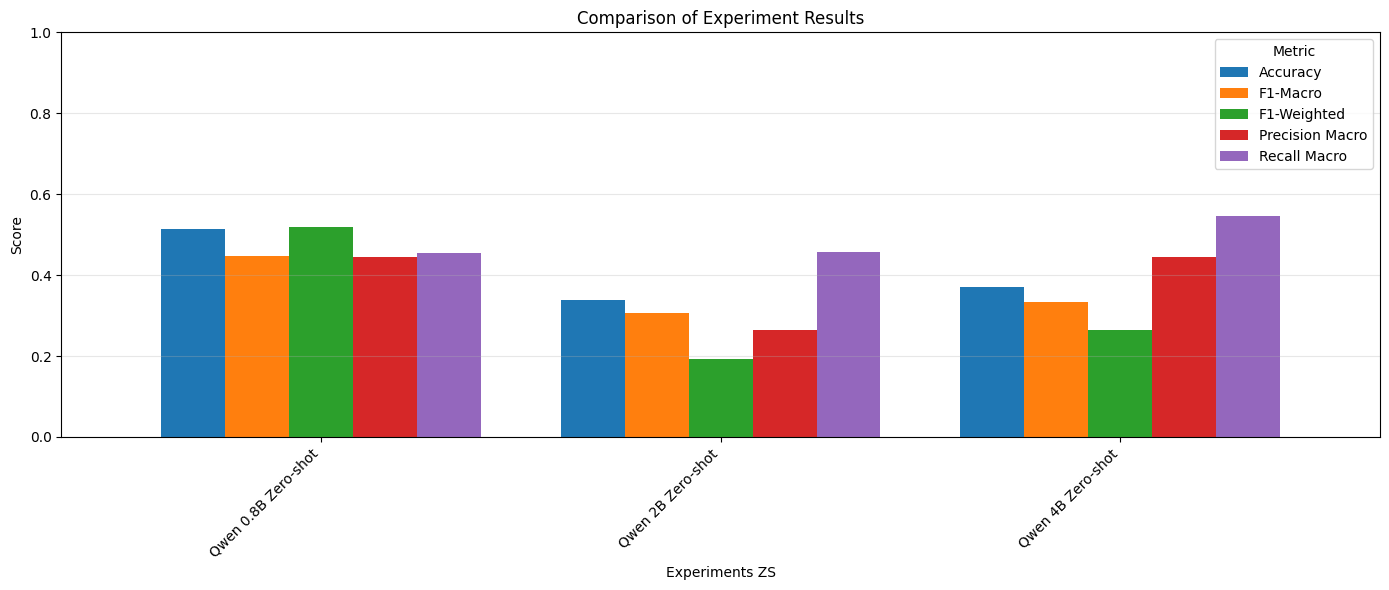

In [79]:

metrics_to_plot = [
    "Accuracy",
    "F1-Macro",
    "F1-Weighted",
    "Precision Macro",
    "Recall Macro"
]

plot_df = results_summary_df_ZS.set_index("Experiment")[metrics_to_plot]

ax = plot_df.plot(
    kind="bar",
    figsize=(14, 6),
    width=0.8
)

plt.title("Comparison of Experiment Results")
plt.ylabel("Score")
plt.xlabel("Experiments ZS")
plt.ylim(0, 1)
plt.xticks(rotation=45, ha="right")
plt.legend(title="Metric")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

In [80]:
experiment_results_fs = [
    {"experiment": "Qwen 0.8B Few-shot","method": "Few-shot",  "results": results_q08_knn_fs3_bal},

    {"experiment": "Qwen 2B Few-shot",  "method": "Few-shot",  "results": results_q2_knn_fs3_No_bal},
  
    {"experiment": "Qwen 4B Few-shot",  "method": "Few-shot",  "results": results_q4_knn_fs3_No_bal}

]
summary_rows_fs = []

for exp in experiment_results_fs:
    r = exp["results"]

    summary_rows_fs.append({
        "Experiment": exp["experiment"],
        "Accuracy": r["accuracy"],
        "F1-Macro": r["f1_macro"],
        "F1-Weighted": r["f1_weighted"],
        "Precision Macro": r["precision_macro"],
        "Recall Macro": r["recall_macro"]
    })

results_summary_df_fs = pd.DataFrame(summary_rows_fs)

results_summary_df_fs

,Experiment,Accuracy,F1-Macro,F1-Weighted,Precision Macro,Recall Macro
0,Qwen 0.8B Few-shot,0.536193,0.381519,0.512955,0.400479,0.387897
1,Qwen 2B Few-shot,0.469169,0.470245,0.446269,0.525237,0.536450
2,Qwen 4B Few-shot,0.495979,0.479245,0.490044,0.502435,0.567847


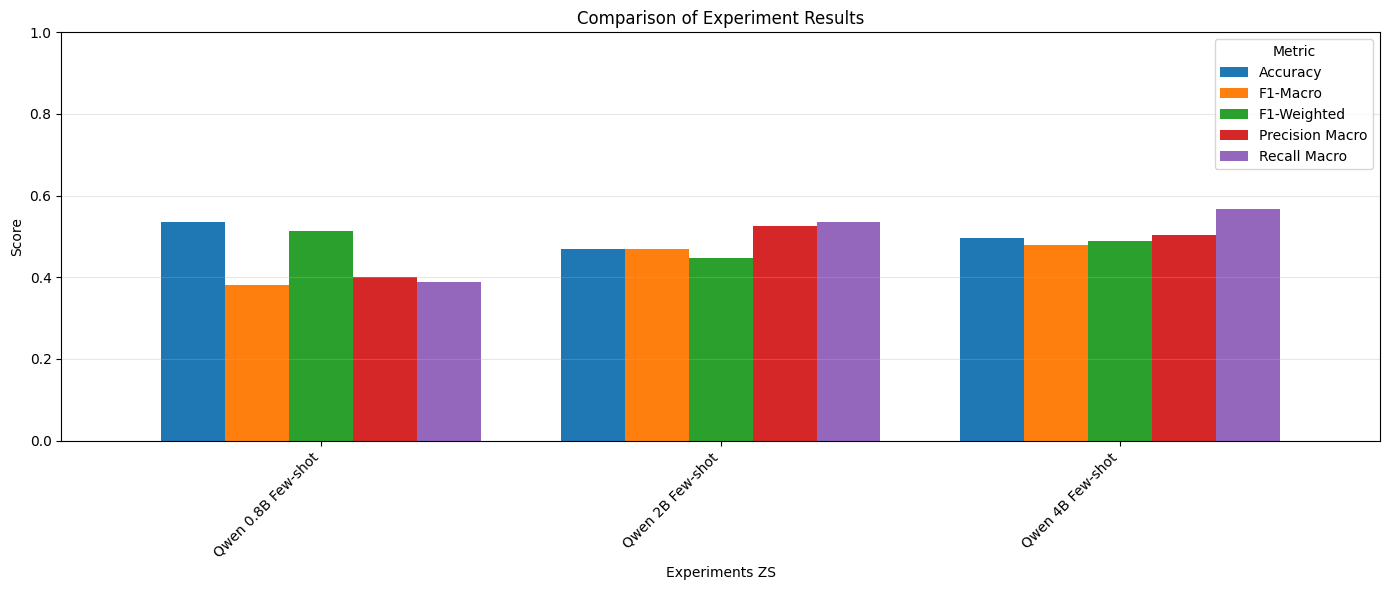

In [81]:

metrics_to_plot = [
    "Accuracy",
    "F1-Macro",
    "F1-Weighted",
    "Precision Macro",
    "Recall Macro"
]

plot_df = results_summary_df_fs.set_index("Experiment")[metrics_to_plot]

ax = plot_df.plot(
    kind="bar",
    figsize=(14, 6),
    width=0.8
)

plt.title("Comparison of Experiment Results")
plt.ylabel("Score")
plt.xlabel("Experiments ZS")
plt.ylim(0, 1)
plt.xticks(rotation=45, ha="right")
plt.legend(title="Metric")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

# Final Model

The final submission uses Qwen3.5-0.8B with semantic few-shot prompting (kNN-retrieved examples, K = 3, unbalanced), drawing demonstrations from the full training set. This configuration achieved the best score of all our experiments (weighted-F1 ≈ 0.54) while also being the smallest and fastest model, giving the best trade-off between classification quality and inference cost.

In [82]:
# Load a sentence embedding model.
# This model converts each question-answer pair into a dense vector representation.
# Semantically similar texts will have embeddings that are close to each other.
embedder = SentenceTransformer("all-MiniLM-L6-v2", device=str(device))

def make_text(q, a, ):
    """
    Creates the text representation that will be embedded.

    The question and answer are combined into a single text, because the
    similarity should be based on the full question-answer pair.
    The answer is truncated to avoid very long inputs.
    """
    return f"Question: {q}\nAnswer: {a}"


# For the FINAL model, the few-shot example pool is the FULL training set
# (df_train), so the submission can use all available labelled data as
# demonstrations. The embeddings are precomputed once for efficiency.

pool_texts  = [make_text(r['question'], r['interview_answer']) for _, r in df_train.iterrows()]
pool_emb    = embedder.encode(pool_texts, normalize_embeddings=True, show_progress_bar=True)

# Store the corresponding labels, questions, and answers from the full train set.
pool_labels = df_train['clarity_label'].tolist()
pool_q, pool_a = df_train['question'].tolist(), df_train['interview_answer'].tolist()

def knn_examples(q, a, k=3, balanced=True):
    """
    Selects k semantically similar few-shot examples from the pool set.

    The function embeds the current question-answer pair and compares it
    with all precomputed pool embeddings using cosine similarity.

    If balanced=True, the function first tries to select one example from
    each class. This helps avoid few-shot prompts that contain examples
    only from the same label.
    """
    qe   = embedder.encode([make_text(q, a)], normalize_embeddings=True)[0]
    sims = pool_emb @ qe
    order = np.argsort(-sims)
    if balanced:
        chosen, seen = [], set()
        for idx in order:
            if pool_labels[idx] not in seen:
                chosen.append(idx); seen.add(pool_labels[idx])
            if len(seen) == 3: break
        for idx in order:
            if len(chosen) >= k: break
            if idx not in chosen: chosen.append(idx)
        idxs = chosen[:k]
    else:
        idxs = order[:k]
    return [{"question": pool_q[i], "answer": pool_a[i], "label": pool_labels[i]} for i in idxs]

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Batches:   0%|          | 0/106 [00:00<?, ?it/s]

In [83]:
model_name = "Qwen/Qwen3.5-0.8B"

tokenizer = AutoTokenizer.from_pretrained(model_name, padding_side="left")
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

model = AutoModelForCausalLM.from_pretrained(
    model_name,
    torch_dtype="auto",
    device_map="auto"
)
cleanup_gpu()
system_prompt = """You are an expert classifier.
Given the interview question and the president's answer, classify the answer into exactly one of the following labels:
Labels:
- Clear Reply
- Ambivalent
- Clear Non-Reply

Output the label only."""

K = 3
all_predictions, all_raw_outputs = [], []

for i in tqdm(range(len(df_test)), desc="kNN Few-shot"):
    row = df_test.iloc[i]
    dyn = knn_examples(row['question'], row['interview_answer'], k=K, balanced=False)
    preds, raws = classify_batch_fewshot(
        [row['question']], [row['interview_answer']],
        system_prompt, model, tokenizer, fewshot_examples=dyn
    )
    all_predictions.extend(preds); all_raw_outputs.extend(raws)

df_test['predicted_label']  = all_predictions
df_test['raw_model_output'] = all_raw_outputs

submission = pd.DataFrame({
    "Id": np.arange(len(all_predictions)),
    "Predicted": all_predictions
})

submission["Predicted"] = submission["Predicted"].replace("Invalid", "Ambivalent")




Loading weights:   0%|          | 0/320 [00:00<?, ?it/s]

GPU free: 14.78 GB


kNN Few-shot:   0%|          | 0/308 [00:00<?, ?it/s]

In [84]:
submission.to_csv("/kaggle/working/submission.csv", index=False)
submission.head(5)

,Id,Predicted
0,0,Clear Reply
1,1,Ambivalent
2,2,Ambivalent
3,3,Ambivalent
4,4,Ambivalent
